In [1]:
import numpy as np
import pickle
from tqdm import tqdm
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM
import warnings

# PDSPL Utils Imports
from pdspl_utils.pairing import (
    get_kdtree_pairs, 
    get_pairs_table_PDSPL, 
    inject_observational_errors, 
    compute_dissimilarity,
    plot_beta_E_vs_D_MC
)

warnings.filterwarnings("ignore")
%load_ext autoreload
%autoreload 2

# Global configuration
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)

# ==============================================================================
# 1. LOAD AND PREPROCESS DATA (Run Once)
# ==============================================================================
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['color_D_gr'] = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri'] = table['mag_D_r'] - table['mag_D_i']
    
    # 1. Compute linear pseudo-fluxes for all bands
    table['flux_D_g'] = 10**(-0.4 * table['mag_D_g'])
    table['flux_D_r'] = 10**(-0.4 * table['mag_D_r'])
    table['flux_D_i'] = 10**(-0.4 * table['mag_D_i'])
    
    # 2. Compute colors on the linear flux scale (Flux Ratios)
    table['flux_ratio_D_gr'] = table['flux_D_g'] / table['flux_D_r']
    table['flux_ratio_D_ri'] = table['flux_D_r'] / table['flux_D_i']
    
    table['log_R_e_kpc'] = np.log10(table['R_e_kpc'])
    table['log_Sigma_half_Msun/pc2'] = np.log10(table['Sigma_half_Msun/pc2'])
    table['log_sigma_v_D'] = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

print("Loading Catalogs...")
GGL_table_LSST_Y10 = preprocess_ggl_table("../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits")
GGL_table_4MOST = preprocess_ggl_table("../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits")

# Create Sub-samples
GGL_table_LSST_Y1 = GGL_table_LSST_Y10.copy()
GGL_table_LSST_Y1.sort('snr_i', reverse=True)
GGL_table_LSST_Y1 = GGL_table_LSST_Y1[:int(len(GGL_table_LSST_Y10) / np.sqrt(10))]

GGL_table_4MOST_specz = GGL_table_4MOST.copy()
GGL_table_4MOST_specz.sort('mag_D_r')
GGL_table_4MOST_specz = GGL_table_4MOST_specz[:10000]

GGL_table_4MOST_specz_sigma = GGL_table_4MOST.copy()
GGL_table_4MOST_specz_sigma.sort('mag_D_r')
GGL_table_4MOST_specz_sigma = GGL_table_4MOST_specz_sigma[:5000]

print("Data Loaded.")

# Base errors dictionary (used across all tests)
base_error_config = {
    'sigma_v_D': 10.0,                                      
    'R_e_arcsec': lambda t: 0.05 * t['R_e_arcsec'],        
    'mag_D_i': 1e-3,                                        
    'flux_D_i': lambda t: 0.01 * t['flux_D_i'],             
    'color_D_gr': 1e-3,
    'color_D_ri': 1e-3,
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'], # 1.4% fractional error
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri']
}

Loading Catalogs...
Data Loaded.


In [21]:
# ==============================================================================
# 2. DEFINE TEST CONFIGURATIONS
# ==============================================================================
# You can easily add or modify dictionaries here to test new combinations
test_cases = [
    {
        "name": "Case 1: Rigorous (Relative Flux + Absolute Color)",
        "pairing_keys": ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        "dissim_keys": ["rel_diff_R_e_arcsec", "rel_diff_z_D", "rel_diff_flux_D_i", "abs_diff_color_D_gr", "abs_diff_color_D_ri"],
        "max_dissim": 0.3
    },
    {
        "name": "Case 2: Absolute Magnitude + Absolute Color",
        "pairing_keys": ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        "dissim_keys": ["rel_diff_R_e_arcsec", "rel_diff_z_D", "abs_diff_mag_D_i", "abs_diff_color_D_gr", "abs_diff_color_D_ri"],
        "max_dissim": 0.3
    },
    {
        "name": "Case 3: Unorthodox Old Method (Relative Mag + Relative Color)",
        "pairing_keys": ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        "dissim_keys": ["rel_diff_R_e_arcsec", "rel_diff_z_D", "rel_diff_mag_D_i", "rel_diff_color_D_gr", "rel_diff_color_D_ri"],
        "max_dissim": 0.1
    },
    {
        "name": "Case 4: No Colors (Flux + Size + Redshift Only)",
        "pairing_keys": ['z_D', 'R_e_arcsec', 'mag_D_i'],
        "dissim_keys": ["rel_diff_R_e_arcsec", "rel_diff_z_D", "rel_diff_flux_D_i"],
        "max_dissim": 0.3
    },
    {
        "name": "Case 5: Pure Linear (Rel Flux + Rel Flux Ratios)",
        "pairing_keys": ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri'],
        "dissim_keys": ["rel_diff_R_e_arcsec", "rel_diff_z_D", "rel_diff_flux_D_i", "rel_diff_flux_ratio_D_gr", "rel_diff_flux_ratio_D_ri"],
        "max_dissim": 0.3
    }
]

In [17]:
# ==============================================================================
# 3. EXPERIMENT RUNNER FUNCTION
# ==============================================================================
def run_pairing_test(config, n_realizations=20, fit_type='linear', plot_dissimilarity_range=None): # Lowered N to 20 for faster testing
    print(f"\n{'='*80}\nRunning {config['name']}\n{'='*80}")
    
    # 1. Initialize fresh samples dict
    pdspl_samples = {
        "lsst_y1": {"table": GGL_table_LSST_Y1, "name": "LSST Y1", "color": "tab:orange"},
        "lsst_y10": {"table": GGL_table_LSST_Y10, "name": "LSST Y10", "color": "green"},
        "lsst_4most_spec-z": {"table": GGL_table_4MOST_specz, "name": "4MOST ($z^{\\rm spec}$)", "color": "red"},
        "lsst_4most_spec-z_sigma_v": {"table": GGL_table_4MOST_specz_sigma, "name": "4MOST ($z^{\\rm spec}$ + $\\sigma_{v, D}$)", "color": "purple"}
    }
    
    # 2. Assign keys based on config
    for key, s in pdspl_samples.items():
        if key == 'lsst_4most_spec-z_sigma_v':
            s['pairing_keys'] = config['pairing_keys'] + ['sigma_v_D']
            s['dissimilarity_keys'] = config['dissim_keys'] + ["rel_diff_sigma_v_D"]
        else:
            s['pairing_keys'] = config['pairing_keys']
            s['dissimilarity_keys'] = config['dissim_keys']
        
        s['error_config'] = base_error_config.copy()
        if key in ['lsst_y1', 'lsst_y10']:
            s['error_config']['z_D'] = lambda t: 0.03 * (1 + t['z_D']) 
        else:
            s['error_config']['z_D'] = 1e-4

    # 3. Setup MC Tracker
    mc_results = {k: {'binned_dissim': [], 'binned_scatter': [], 'num_pairs': [], 'scatter_in_beta_E': []} 
                  for k in pdspl_samples.keys()}
    
    # Fix seed so random noise is identical across all test cases (fair comparison)
    # np.random.seed(42)

    # 4. MC Loop
    for i_realization in tqdm(range(n_realizations), desc="MC Realizations"):
        for sample_key, s in pdspl_samples.items():
            if len(s["table"]) < 2: continue
                
            table_err = inject_observational_errors(s['table'], s['error_config'])
            indices, _ = get_kdtree_pairs(table_err, s['pairing_keys'], norm_type='zscore')
            
            pairs_table = get_pairs_table_PDSPL(s['table'], indices, cosmo_true)
            pairs_table_err = get_pairs_table_PDSPL(table_err, indices, cosmo_true)
            
            pairs_table_err['dissimilarity'] = compute_dissimilarity(
                pairs_table_err, s['dissimilarity_keys'], method='rms'
            )
            
            s["pairs_analysis"] = {
                "pairs_table": pairs_table, "pairs_table_with_errors": pairs_table_err,
                "num_lenses": len(s['table']), "num_pairs": len(pairs_table),
                "scatter_in_beta_E": np.std(pairs_table['rel_diff_beta_E']),
                "pair_indices": indices
            }

            mc_results[sample_key]['num_pairs'].append(len(pairs_table))
            mc_results[sample_key]['scatter_in_beta_E'].append(np.std(pairs_table['rel_diff_beta_E']))
            
            mask = (pairs_table_err['dissimilarity'] < config['max_dissim']) & (np.isfinite(pairs_table['rel_diff_beta_E']))
            dissim_masked = pairs_table_err['dissimilarity'][mask]
            delta_beta_masked = pairs_table['rel_diff_beta_E'][mask]
            
            percentiles = np.percentile(dissim_masked, np.arange(0, 101, 10))
            digitized = np.digitize(dissim_masked, percentiles)
            
            run_dissim, run_scatter = [], []
            for i in range(1, len(percentiles)):
                bin_mask = (digitized == i)
                run_dissim.append(np.median(dissim_masked[bin_mask]) if np.any(bin_mask) else np.nan)
                run_scatter.append(np.nanstd(delta_beta_masked[bin_mask]) if np.any(bin_mask) else np.nan)
                
            mc_results[sample_key]['binned_dissim'].append(run_dissim)
            mc_results[sample_key]['binned_scatter'].append(run_scatter)
    
    plot_dissimilarity_range = (0, config['max_dissim']) if plot_dissimilarity_range is None else plot_dissimilarity_range

    # 5. Plotting
    fig = plot_beta_E_vs_D_MC(
        pdspl_samples, mc_results, fit_type=fit_type, show_fit_eqn_label=True, plot_dissimilarity_range=plot_dissimilarity_range,
    )
    fig.suptitle(config['name'], fontsize=20, y=1.05)
    plt.show()


Running Case 1: Rigorous (Relative Flux + Absolute Color)


MC Realizations:   0%|          | 0/100 [00:00<?, ?it/s]

MC Realizations: 100%|██████████| 100/100 [02:25<00:00,  1.45s/it]


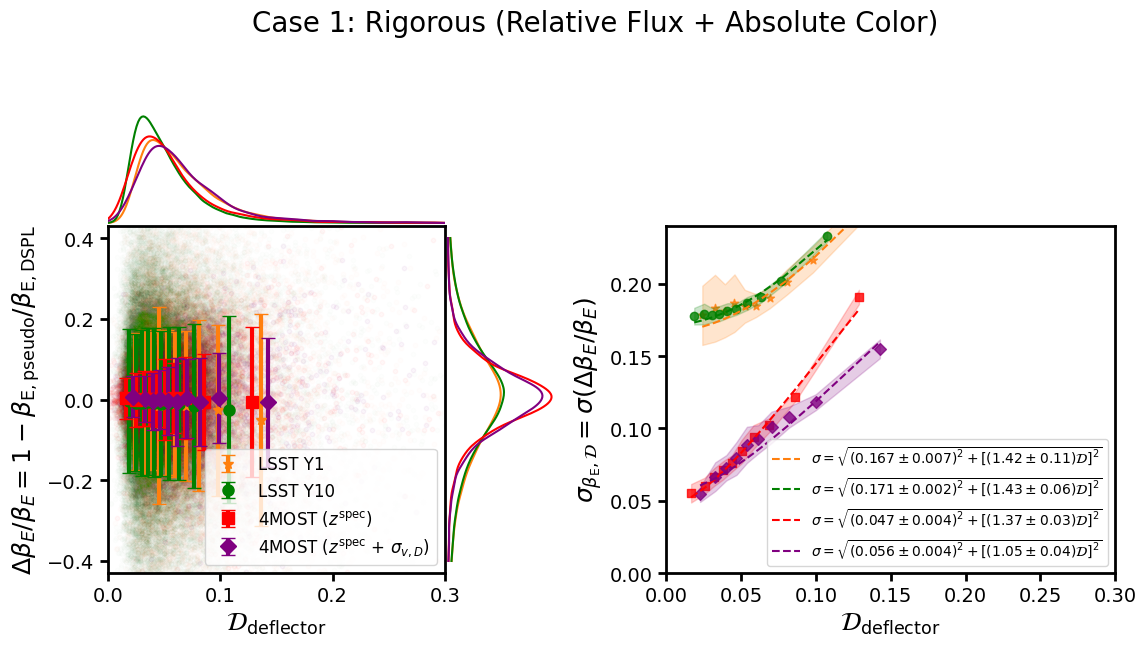


Running Case 2: Absolute Magnitude + Absolute Color


MC Realizations: 100%|██████████| 100/100 [02:24<00:00,  1.45s/it]


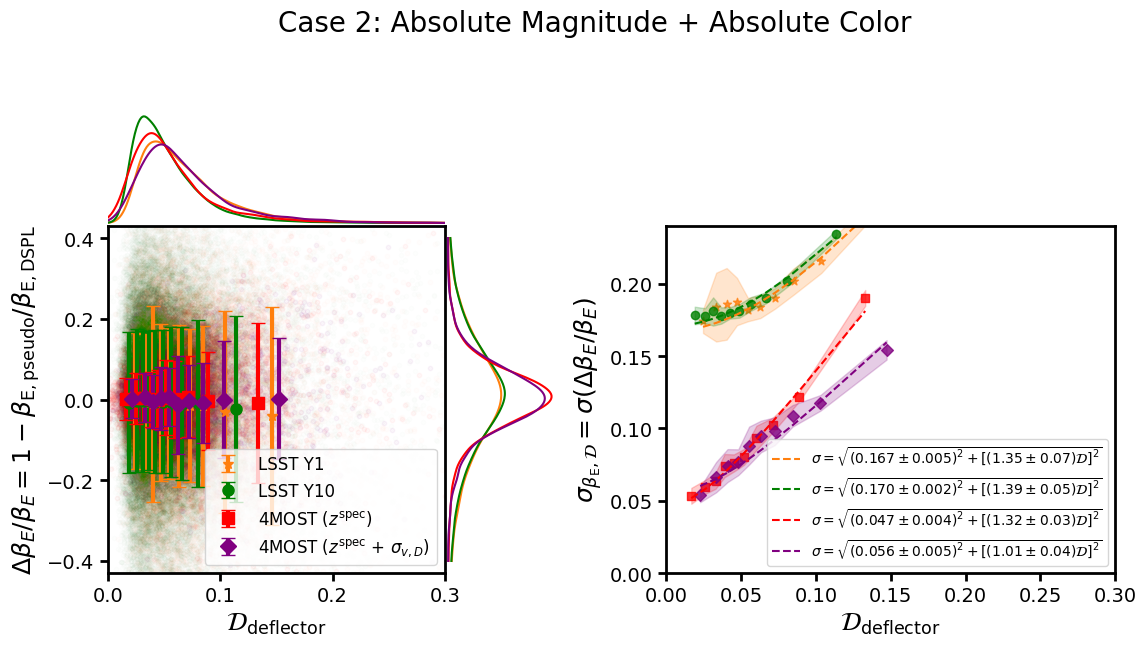


Running Case 3: Unorthodox Old Method (Relative Mag + Relative Color)


MC Realizations: 100%|██████████| 100/100 [02:24<00:00,  1.44s/it]


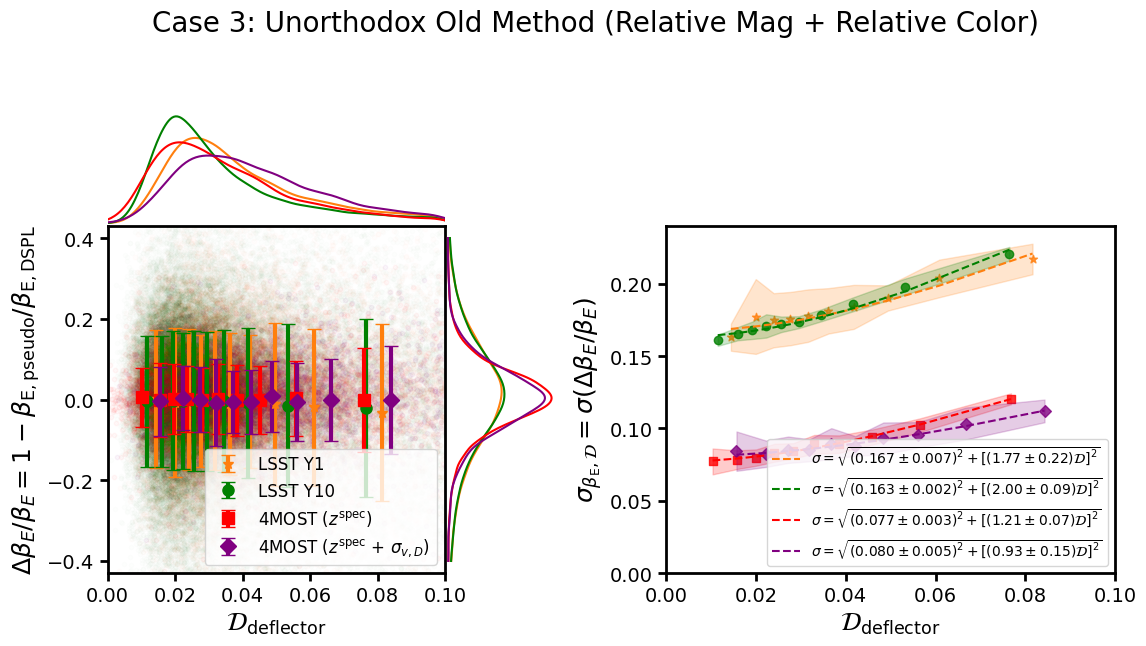


Running Case 4: No Colors (Flux + Size + Redshift Only)


MC Realizations: 100%|██████████| 100/100 [02:01<00:00,  1.22s/it]


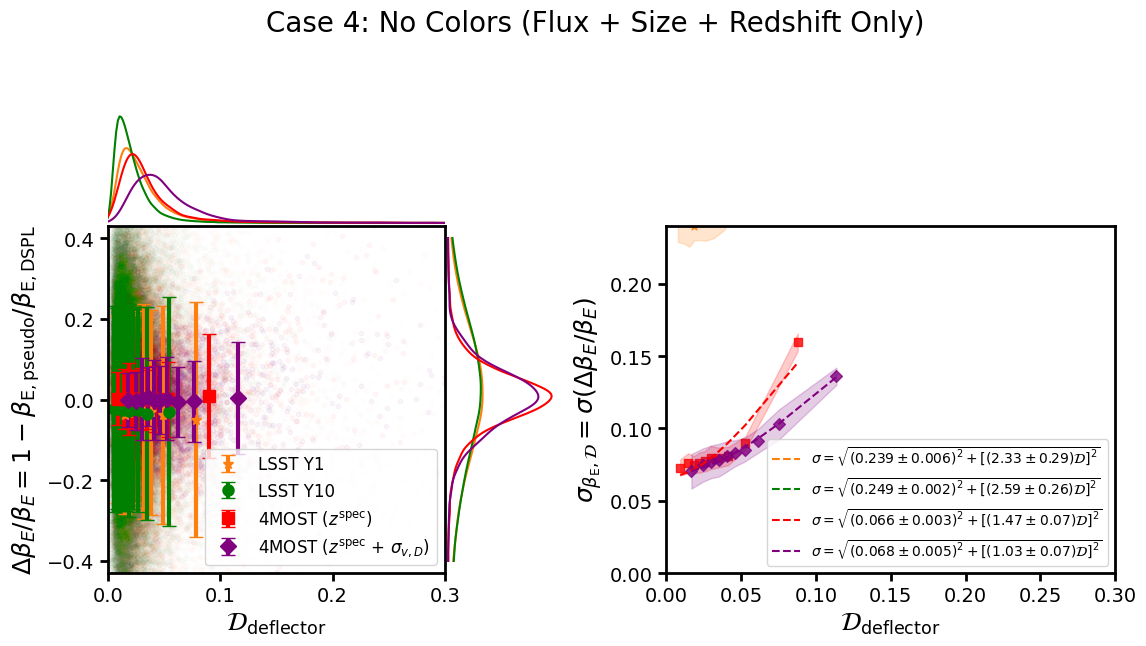


Running Case 5: Pure Linear (Rel Flux + Rel Flux Ratios)


MC Realizations: 100%|██████████| 100/100 [02:22<00:00,  1.43s/it]


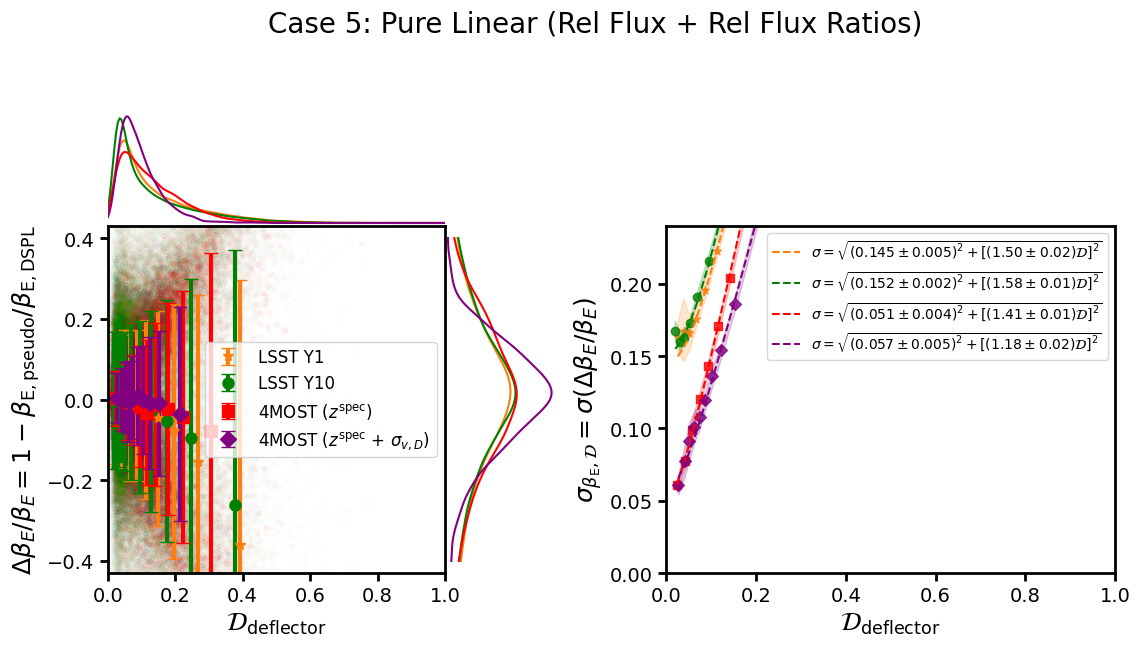

In [20]:
# ==============================================================================
# 4. EXECUTE ALL TESTS
# ==============================================================================
for case in test_cases:
    run_pairing_test(case, n_realizations=100, fit_type='quadrature')


Running Case 5: Pure Linear (Rel Flux + Rel Flux Ratios)


MC Realizations: 100%|██████████| 100/100 [02:21<00:00,  1.42s/it]


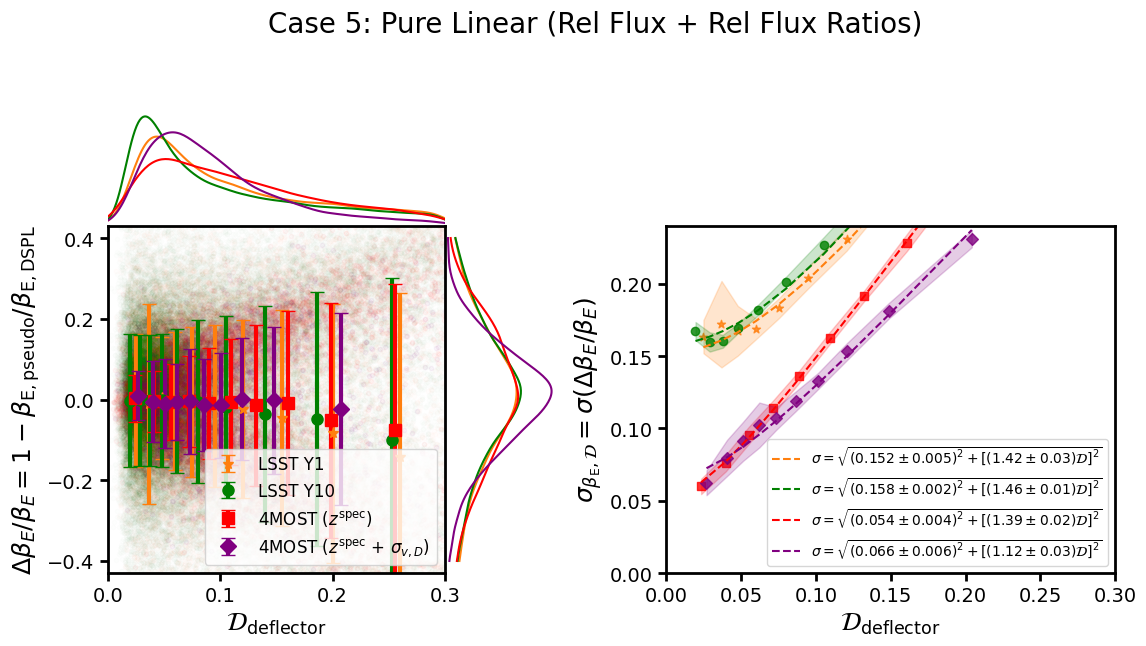

In [22]:
run_pairing_test(test_cases[-1], n_realizations=100, fit_type='quadrature')

Loading catalog for 'lsst_y10'...
Catalog rows  : 116471  |  Using: 100000
Exact method  : SKIPPED (N > 3000, OOM risk)

Sample       : 'lsst_y10'  |  N = 100000
Pairing keys : ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri']
Dissim  keys : ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i', 'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri']

Method                            # Pairs   Time (s)
----------------------------------------------------
KD-Tree (z-score)                   73285       0.27
KD-Tree (log-metric)                73680       0.26

Metric                                 Z-score        Log
---------------------------------------------------------
std(rel_diff_beta_E)                    0.3124     0.1926
mean(dissimilarity)                     0.1277     0.0369
median(dissimilarity)                   0.0822     0.0338
frac with D < 0.05                      0.3212     0.8574
frac with D < 0.10                      0.5642     0.9930

/tmp/ipykernel_121444/3957017831.py:296: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


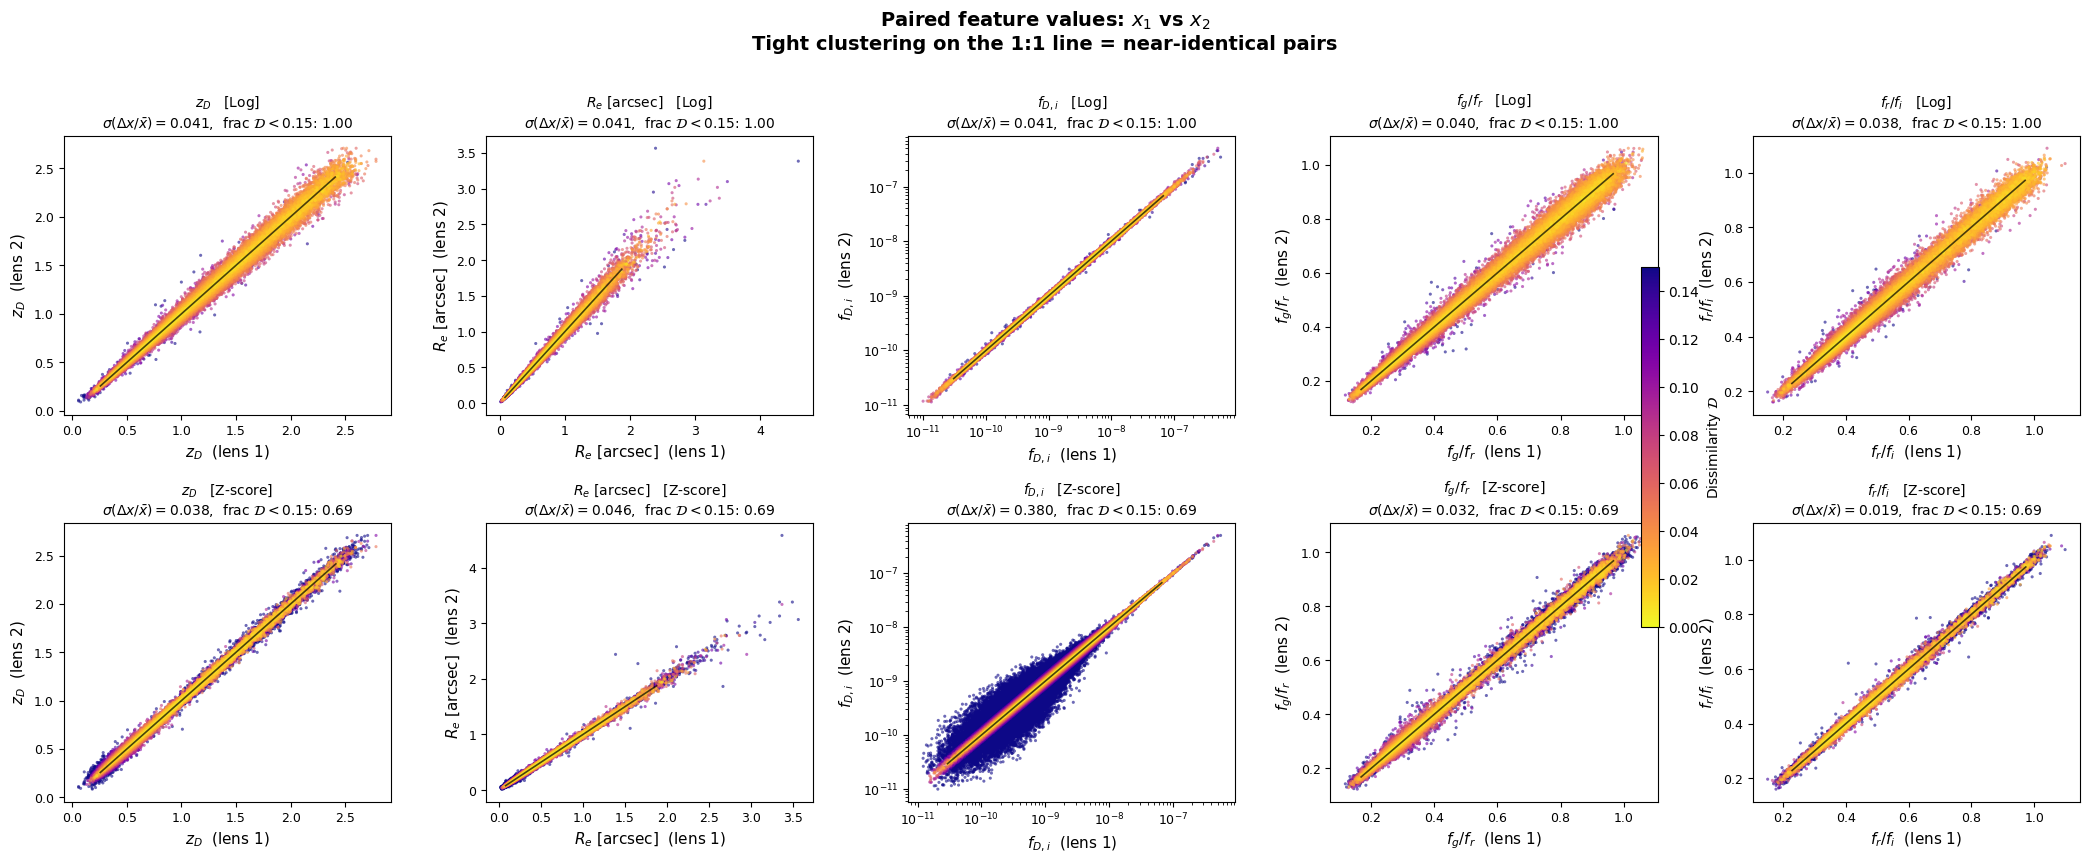

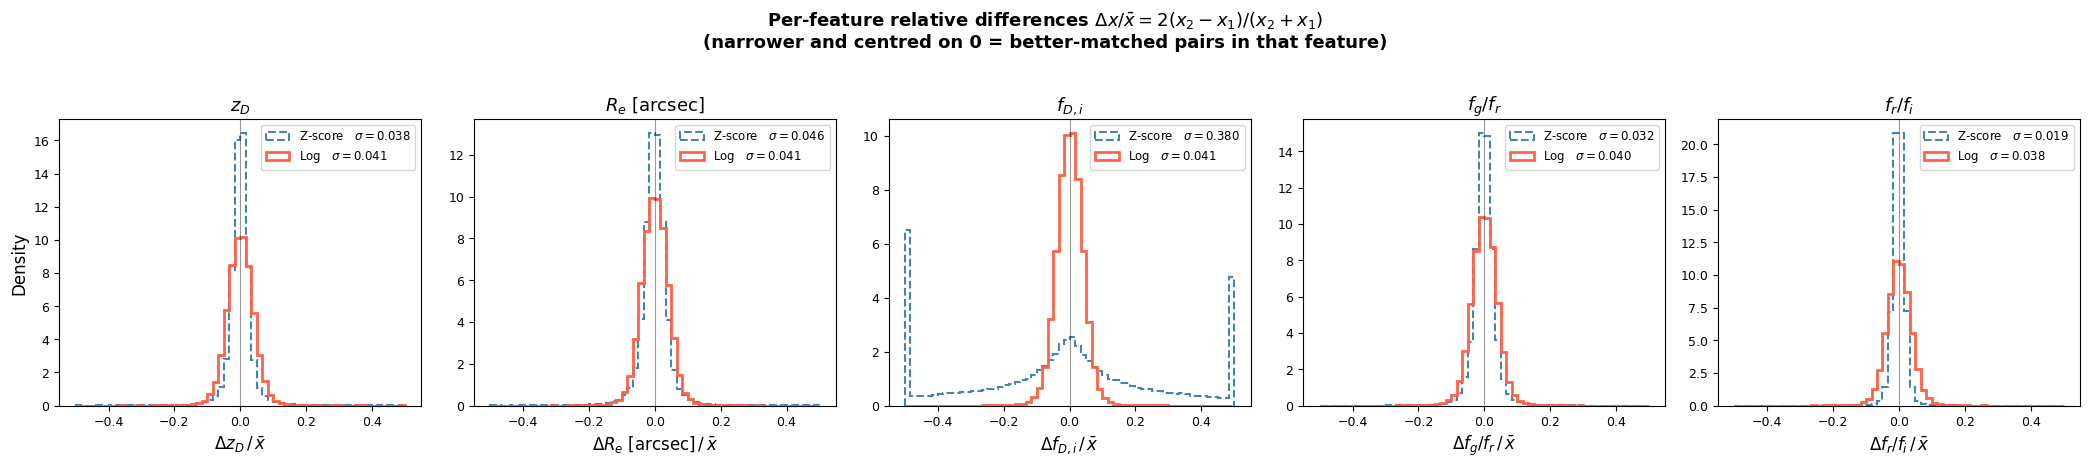

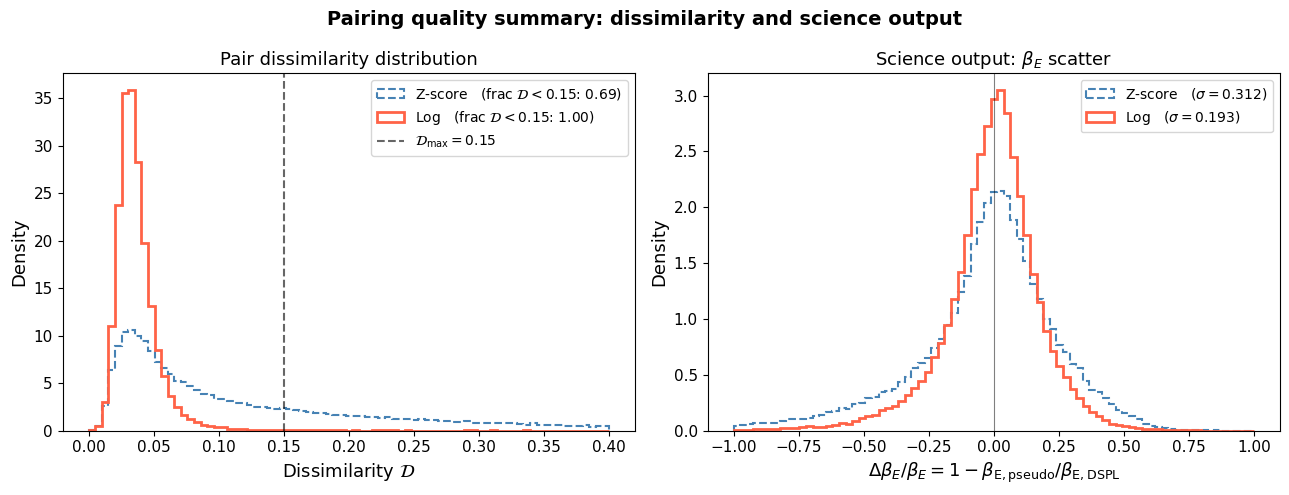

In [2]:
# ==============================================================================
# TEST CELL: KD-Tree (Z-score) vs KD-Tree (Log-metric) vs Exact Dissimilarity
# Validates that the log-metric KD-Tree matches the exact dissimilarity pairing.
# Self-contained — does not rely on pdspl_samples or the main notebook state.
#
# Workflow:
#   - Keep N_TEST <= 3000: all three methods run and are compared
#   - N_TEST > N_EXACT_MAX: exact method is skipped (OOM risk), log vs z-score only
#   - Once validated here, use use_log_metric=True in the main MC loop
# ==============================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import spatial
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from pdspl_utils.pairing import (
    normalize_data,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
)

# ==============================================================================
# 0. CONFIG
# ==============================================================================
N_TEST          = 100000    # Keep <= 3000 for exact method; set higher to skip exact
N_EXACT_MAX     = 3000    # Safety cap: exact is O(N^2) memory — 3000 → ~360 MB
TEST_SAMPLE_KEY = 'lsst_y10'
cosmo_true      = FlatLambdaCDM(H0=70, Om0=0.3)

CATALOG_PATHS = {
    'lsst_y1':                   "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits",
    'lsst_y10':                  "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits",
    'lsst_4most_spec-z':         "../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits",
    'lsst_4most_spec-z_sigma_v': "../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits",
}

# ==============================================================================
# 1. LOCAL get_kdtree_pairs WITH LOG-METRIC SUPPORT
# ==============================================================================
def get_kdtree_pairs(table, pairing_keys, norm_type='zscore', n_neighbors=2,
                     unique_pairs=True, use_log_metric=False):
    if use_log_metric:
        points = np.stack(
            [np.log(np.array(table[pk], dtype=float)) for pk in pairing_keys], axis=1
        )
        if not np.all(np.isfinite(points)):
            raise ValueError(
                "use_log_metric=True requires all pairing features to be strictly "
                "positive. Check for zeros or negatives in pairing_keys."
            )
    else:
        points = np.stack(
            [normalize_data(table[pk], type=norm_type) for pk in pairing_keys], axis=1
        )

    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=n_neighbors)

    if n_neighbors < 2:
        return np.empty((0, 2), dtype=int), np.empty(0)

    n_points         = len(points)
    base_indices     = np.repeat(np.arange(n_points), n_neighbors - 1)
    neighbor_indices = indices[:, 1:].flatten()
    flat_distances   = distances[:, 1:].flatten()
    pair_indices     = np.column_stack((base_indices, neighbor_indices))

    if unique_pairs:
        pair_indices = np.sort(pair_indices, axis=1)
        pair_indices, unique_pairs_idxs = np.unique(pair_indices, axis=0, return_index=True)
        flat_distances = flat_distances[unique_pairs_idxs]

    return pair_indices, flat_distances

# ==============================================================================
# 2. EXACT DISSIMILARITY PAIRING (O(N^2) — ground truth, small N only)
# ==============================================================================
def get_pairs_exact_dissimilarity(table, pairing_keys):
    X   = np.stack([np.array(table[pk], dtype=float) for pk in pairing_keys], axis=1)
    X_i = X[:, np.newaxis, :]
    X_j = X[np.newaxis, :, :]
    rel_diffs = 2 * (X_j - X_i) / (X_j + X_i)
    D_matrix  = np.sqrt(np.mean(rel_diffs**2, axis=2))
    np.fill_diagonal(D_matrix, np.inf)
    nn_idx  = np.argmin(D_matrix, axis=1)
    nn_dist = D_matrix[np.arange(len(X)), nn_idx]
    pair_indices = np.sort(np.column_stack((np.arange(len(X)), nn_idx)), axis=1)
    pair_indices, uniq = np.unique(pair_indices, axis=0, return_index=True)
    return pair_indices, nn_dist[uniq]

def get_science_stats(idx, table, table_err, dissim_keys, cosmo):
    pt     = get_pairs_table_PDSPL(table,     idx, cosmo)
    pt_err = get_pairs_table_PDSPL(table_err, idx, cosmo)
    pt_err['dissimilarity'] = compute_dissimilarity(pt_err, dissim_keys)
    return pt, pt_err

# ==============================================================================
# 3. LOAD + PREPROCESS
# ==============================================================================
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['flux_D_g']        = 10**(-0.4 * table['mag_D_g'])
    table['flux_D_r']        = 10**(-0.4 * table['mag_D_r'])
    table['flux_D_i']        = 10**(-0.4 * table['mag_D_i'])
    table['flux_ratio_D_gr'] = table['flux_D_g'] / table['flux_D_r']
    table['flux_ratio_D_ri'] = table['flux_D_r'] / table['flux_D_i']
    table['log_R_e_kpc']     = np.log10(table['R_e_kpc'])
    table['log_sigma_v_D']   = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

print(f"Loading catalog for '{TEST_SAMPLE_KEY}'...")
raw_table = preprocess_ggl_table(CATALOG_PATHS[TEST_SAMPLE_KEY])

if TEST_SAMPLE_KEY == 'lsst_y1':
    raw_table.sort('snr_i', reverse=True)
    raw_table = raw_table[:int(len(raw_table) / np.sqrt(10))]
elif TEST_SAMPLE_KEY in ['lsst_4most_spec-z', 'lsst_4most_spec-z_sigma_v']:
    raw_table.sort('mag_D_r')
    raw_table = raw_table[:5000 if TEST_SAMPLE_KEY == 'lsst_4most_spec-z_sigma_v' else 10000]

test_table = raw_table[:N_TEST]
RUN_EXACT  = N_TEST <= N_EXACT_MAX

print(f"Catalog rows  : {len(raw_table)}  |  Using: {len(test_table)}")
print(f"Exact method  : {'YES' if RUN_EXACT else 'SKIPPED (N > ' + str(N_EXACT_MAX) + ', OOM risk)'}\n")

# ==============================================================================
# 4. PAIRING + ERROR CONFIG
# ==============================================================================
base_pairing_keys = ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri']
base_dissim_keys  = [
    'rel_diff_z_D', 'rel_diff_R_e_arcsec',
    'rel_diff_flux_D_i', 'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri'
]
if TEST_SAMPLE_KEY == 'lsst_4most_spec-z_sigma_v':
    pairing_keys = base_pairing_keys + ['sigma_v_D']
    dissim_keys  = base_dissim_keys  + ['rel_diff_sigma_v_D']
else:
    pairing_keys = base_pairing_keys
    dissim_keys  = base_dissim_keys

error_config = {
    'sigma_v_D':       10.0,
    'R_e_arcsec':      lambda t: 0.05  * t['R_e_arcsec'],
    'flux_D_i':        lambda t: 0.01  * t['flux_D_i'],
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'],
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri'],
    'z_D': (lambda t: 0.03 * (1 + t['z_D'])) if TEST_SAMPLE_KEY in ['lsst_y1', 'lsst_y10'] else 1e-4,
}

np.random.seed(42)
test_table_err = inject_observational_errors(test_table, error_config)

print(f"Sample       : '{TEST_SAMPLE_KEY}'  |  N = {len(test_table)}")
print(f"Pairing keys : {pairing_keys}")
print(f"Dissim  keys : {dissim_keys}\n")

# ==============================================================================
# 5. RUN PAIRING METHODS
# ==============================================================================
t0 = time.time()
idx_zscore, _ = get_kdtree_pairs(test_table_err, pairing_keys, norm_type='zscore')
t_zscore = time.time() - t0

t0 = time.time()
idx_log, _ = get_kdtree_pairs(test_table_err, pairing_keys, use_log_metric=True)
t_log = time.time() - t0

print(f"{'Method':<30} {'# Pairs':>10} {'Time (s)':>10}")
print("-" * 52)
print(f"{'KD-Tree (z-score)':<30} {len(idx_zscore):>10} {t_zscore:>10.2f}")
print(f"{'KD-Tree (log-metric)':<30} {len(idx_log):>10} {t_log:>10.2f}")

if RUN_EXACT:
    t0 = time.time()
    idx_exact, _ = get_pairs_exact_dissimilarity(test_table_err, pairing_keys)
    t_exact = time.time() - t0
    print(f"{'Exact dissimilarity':<30} {len(idx_exact):>10} {t_exact:>10.2f}")

# ==============================================================================
# 6. PAIR OVERLAP VS EXACT
# ==============================================================================
if RUN_EXACT:
    set_zscore     = set(map(tuple, idx_zscore))
    set_log        = set(map(tuple, idx_log))
    set_exact      = set(map(tuple, idx_exact))
    overlap_zscore = len(set_zscore & set_exact)
    overlap_log    = len(set_log    & set_exact)
    print(f"\n{'Method':<30} {'Overlap w/ Exact':>20} {'%':>8}")
    print("-" * 60)
    print(f"{'KD-Tree (z-score)':<30} {overlap_zscore:>20} {100*overlap_zscore/len(set_exact):>7.1f}%")
    print(f"{'KD-Tree (log-metric)':<30} {overlap_log:>20} {100*overlap_log/len(set_exact):>7.1f}%")

# ==============================================================================
# 7. SCIENCE COMPARISON
# ==============================================================================
pt_zscore, pt_zscore_err = get_science_stats(idx_zscore, test_table, test_table_err, dissim_keys, cosmo_true)
pt_log,    pt_log_err    = get_science_stats(idx_log,    test_table, test_table_err, dissim_keys, cosmo_true)
if RUN_EXACT:
    pt_exact, pt_exact_err = get_science_stats(idx_exact, test_table, test_table_err, dissim_keys, cosmo_true)

header = f"\n{'Metric':<35} {'Z-score':>10} {'Log':>10}" + (" {'Exact':>10}" if RUN_EXACT else "")
print(header)
print("-" * (57 if not RUN_EXACT else 67))

metrics = {
    'std(rel_diff_beta_E)':  lambda pt, pt_err: np.std(pt['rel_diff_beta_E']),
    'mean(dissimilarity)':   lambda pt, pt_err: np.mean(pt_err['dissimilarity']),
    'median(dissimilarity)': lambda pt, pt_err: np.median(pt_err['dissimilarity']),
    'frac with D < 0.05':    lambda pt, pt_err: np.mean(pt_err['dissimilarity'] < 0.05),
    'frac with D < 0.10':    lambda pt, pt_err: np.mean(pt_err['dissimilarity'] < 0.10),
    'frac with D < 0.15':    lambda pt, pt_err: np.mean(pt_err['dissimilarity'] < 0.15),
}
for label, fn in metrics.items():
    row = f"{label:<35} {fn(pt_zscore, pt_zscore_err):>10.4f} {fn(pt_log, pt_log_err):>10.4f}"
    if RUN_EXACT:
        row += f" {fn(pt_exact, pt_exact_err):>10.4f}"
    print(row)

# ==============================================================================
# 8. VISUALIZATION
# ==============================================================================
METHOD_COLORS  = {'Z-score': 'steelblue', 'Log': 'tomato', 'Exact': 'forestgreen'}
METHOD_LSTYLES = {'Z-score': '--', 'Log': '-', 'Exact': ':'}
METHOD_LW      = {'Z-score': 1.5,  'Log': 2.0,  'Exact': 1.5}
LOG_SCALE_FEATS = {'flux_D_i'}
FEATURE_LABELS  = {
    'z_D':             r'$z_D$',
    'R_e_arcsec':      r'$R_e$ [arcsec]',
    'flux_D_i':        r'$f_{D,i}$',
    'flux_ratio_D_gr': r'$f_g / f_r$',
    'flux_ratio_D_ri': r'$f_r / f_i$',
    'sigma_v_D':       r'$\sigma_{v,D}$ [km/s]',
}

method_data = {
    'Z-score': {'pt': pt_zscore, 'pt_err': pt_zscore_err},
    'Log':     {'pt': pt_log,    'pt_err': pt_log_err},
}
if RUN_EXACT:
    method_data['Exact'] = {'pt': pt_exact, 'pt_err': pt_exact_err}

def get_reldiff(pt_err, pk):
    v1 = np.array(pt_err[f'{pk}_1'], dtype=float)
    v2 = np.array(pt_err[f'{pk}_2'], dtype=float)
    return 2 * (v2 - v1) / (v2 + v1)

n_feat = len(pairing_keys)
norm_d = mcolors.Normalize(vmin=0, vmax=0.15)
cmap_d = plt.cm.plasma_r

# ---- Figure 1: x_1 vs x_2 (Log row vs Z-score row) ----
fig1, axes1 = plt.subplots(2, n_feat, figsize=(4.2 * n_feat, 8.5))
fig1.suptitle(
    r'Paired feature values: $x_1$ vs $x_2$' + '\n'
    r'Tight clustering on the 1:1 line = near-identical pairs',
    fontsize=14, fontweight='bold', y=1.01
)
for col_idx, pk in enumerate(pairing_keys):
    label   = FEATURE_LABELS.get(pk, pk)
    use_log = pk in LOG_SCALE_FEATS
    for row_idx, method in enumerate(['Log', 'Z-score']):
        ax     = axes1[row_idx, col_idx]
        pt_err = method_data[method]['pt_err']
        dissim = np.array(pt_err['dissimilarity'])
        v1     = np.array(pt_err[f'{pk}_1'], dtype=float)
        v2     = np.array(pt_err[f'{pk}_2'], dtype=float)
        order  = np.argsort(dissim)[::-1]
        ax.scatter(v1[order], v2[order], c=dissim[order],
                   cmap=cmap_d, norm=norm_d, s=5, alpha=0.6,
                   linewidths=0, rasterized=True)
        plo = min(np.nanpercentile(v1, 0.5),  np.nanpercentile(v2, 0.5))
        phi = max(np.nanpercentile(v1, 99.5), np.nanpercentile(v2, 99.5))
        ax.plot([plo, phi], [plo, phi], 'k-', lw=1.2, alpha=0.7, zorder=5)
        if use_log:
            ax.set_xscale('log')
            ax.set_yscale('log')
        rms_rd    = np.nanstd(get_reldiff(pt_err, pk))
        frac_good = np.mean(dissim < 0.15)
        ax.set_title(
            f'{label}   [{method}]\n'
            fr'$\sigma(\Delta x/\bar{{x}})={rms_rd:.3f}$,  frac $\mathcal{{D}}<0.15$: {frac_good:.2f}',
            fontsize=10
        )
        ax.set_xlabel(f'{label}  (lens 1)', fontsize=11)
        ax.set_ylabel(f'{label}  (lens 2)', fontsize=11)
        ax.tick_params(labelsize=9)

fig1.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d),
              ax=axes1, shrink=0.55, pad=0.02,
              label=r'Dissimilarity $\mathcal{D}$')
fig1.tight_layout()
plt.show()

# ---- Figure 2: Per-feature rel-diff histograms ----
fig2, axes2 = plt.subplots(1, n_feat, figsize=(4.2 * n_feat, 4.5))
fig2.suptitle(
    r'Per-feature relative differences $\Delta x / \bar{x} = 2(x_2 - x_1)/(x_2 + x_1)$'
    '\n(narrower and centred on 0 = better-matched pairs in that feature)',
    fontsize=13, fontweight='bold', y=1.03
)
for ax, pk in zip(axes2, pairing_keys):
    label = FEATURE_LABELS.get(pk, pk)
    for method, d in method_data.items():
        rd      = get_reldiff(d['pt_err'], pk)
        rd_clip = np.clip(rd[np.isfinite(rd)], -0.5, 0.5)
        ax.hist(rd_clip, bins=60, range=(-0.5, 0.5), density=True,
                histtype='step', color=METHOD_COLORS[method],
                ls=METHOD_LSTYLES[method], lw=METHOD_LW[method],
                label=fr'{method}   $\sigma={np.nanstd(rd):.3f}$')
    ax.axvline(0, color='k', lw=0.8, alpha=0.4)
    ax.set_xlabel(r'$\Delta$' + label + r'$\,/\,\bar{x}$', fontsize=12)
    ax.set_ylabel('Density' if ax is axes2[0] else '', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=8.5, frameon=True, loc='upper right')
    ax.tick_params(labelsize=9)
fig2.tight_layout()
plt.show()

# ---- Figure 3: Dissimilarity + beta_E summary ----
fig3, (ax_d, ax_b) = plt.subplots(1, 2, figsize=(13, 5))
fig3.suptitle('Pairing quality summary: dissimilarity and science output',
              fontsize=14, fontweight='bold')
for method, d in method_data.items():
    dissim = np.array(d['pt_err']['dissimilarity'])
    beta   = np.array(d['pt']['rel_diff_beta_E'])
    ax_d.hist(dissim[np.isfinite(dissim)], bins=np.linspace(0, 0.40, 80),
              density=True, histtype='step',
              color=METHOD_COLORS[method], ls=METHOD_LSTYLES[method], lw=METHOD_LW[method],
              label=fr"{method}   (frac $\mathcal{{D}}<0.15$: {np.mean(dissim<0.15):.2f})")
    ax_b.hist(beta[np.isfinite(beta)], bins=np.linspace(-1.0, 1.0, 80),
              density=True, histtype='step',
              color=METHOD_COLORS[method], ls=METHOD_LSTYLES[method], lw=METHOD_LW[method],
              label=fr'{method}   ($\sigma={np.nanstd(beta[np.isfinite(beta)]):.3f}$)')

ax_d.axvline(0.15, color='k', lw=1.5, ls='--', alpha=0.6, label=r'$\mathcal{D}_{\rm max}=0.15$')
ax_d.set_xlabel(r'Dissimilarity $\mathcal{D}$', fontsize=13)
ax_d.set_ylabel('Density', fontsize=13)
ax_d.set_title('Pair dissimilarity distribution', fontsize=13)
ax_d.legend(fontsize=10, frameon=True)
ax_d.tick_params(labelsize=11)
ax_b.axvline(0, color='k', lw=0.8, alpha=0.5)
ax_b.set_xlabel(r'$\Delta\beta_E/\beta_E = 1 - \beta_{\rm E,pseudo}/\beta_{\rm E,DSPL}$', fontsize=13)
ax_b.set_ylabel('Density', fontsize=13)
ax_b.set_title(r'Science output: $\beta_E$ scatter', fontsize=13)
ax_b.legend(fontsize=10, frameon=True)
ax_b.tick_params(labelsize=11)
fig3.tight_layout()
plt.show()

Loading catalog for 'lsst_y10'...
Loaded: 116471 total rows, using 2000

Part A: Same pairs, 4 dissimilarity metrics
  RMS (current)         mean D=0.0869  sigma(beta_E | top 50%)=0.2267
  Chi2 (err-wt)         mean D=3.8927  sigma(beta_E | top 50%)=0.2273
  Sensitivity-wt        mean D=0.0875  sigma(beta_E | top 50%)=0.2539
  Combined              mean D=0.0854  sigma(beta_E | top 50%)=0.2270

Part B: Metric-matched pairing methods (eval: RMS metric)
  Log (RMS)            1469 pairs  [0.00s]  frac D<0.15=0.938  sigma(beta_E|D<0.15)=0.2397
  Chi2-approx          1470 pairs  [0.00s]  frac D<0.15=0.756  sigma(beta_E|D<0.15)=0.2436
  Median |d ln(β_E)/d ln(z_D)| = 0.158
  Sens-approx          1475 pairs  [0.01s]  frac D<0.15=0.729  sigma(beta_E|D<0.15)=0.2506


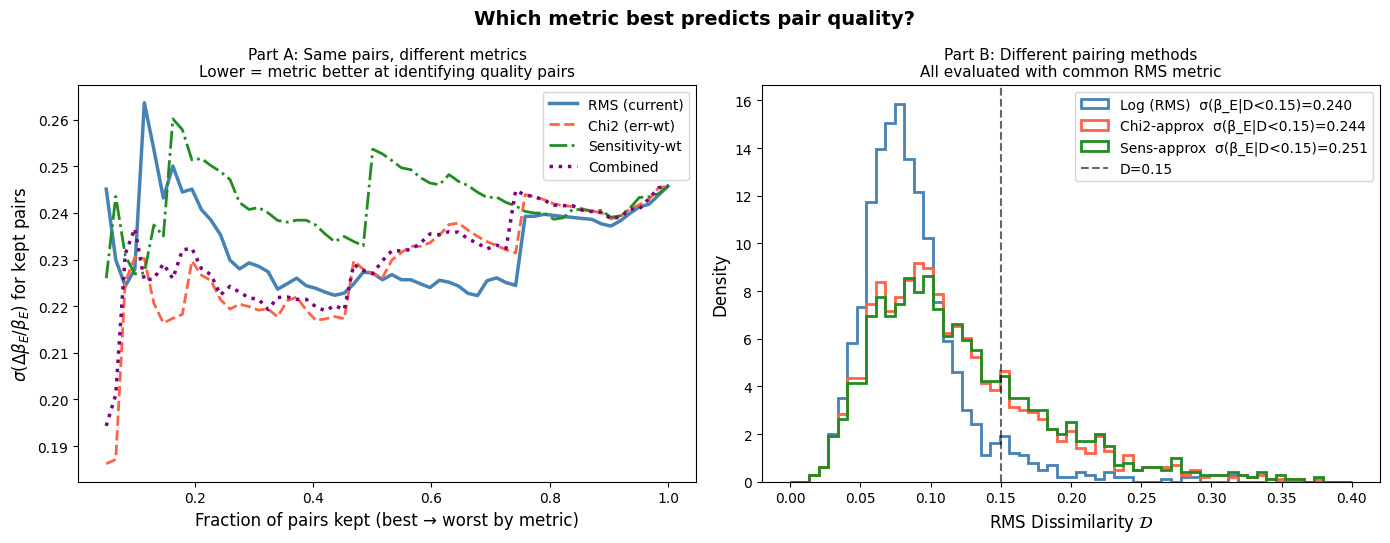

/tmp/ipykernel_121444/1756879678.py:406: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


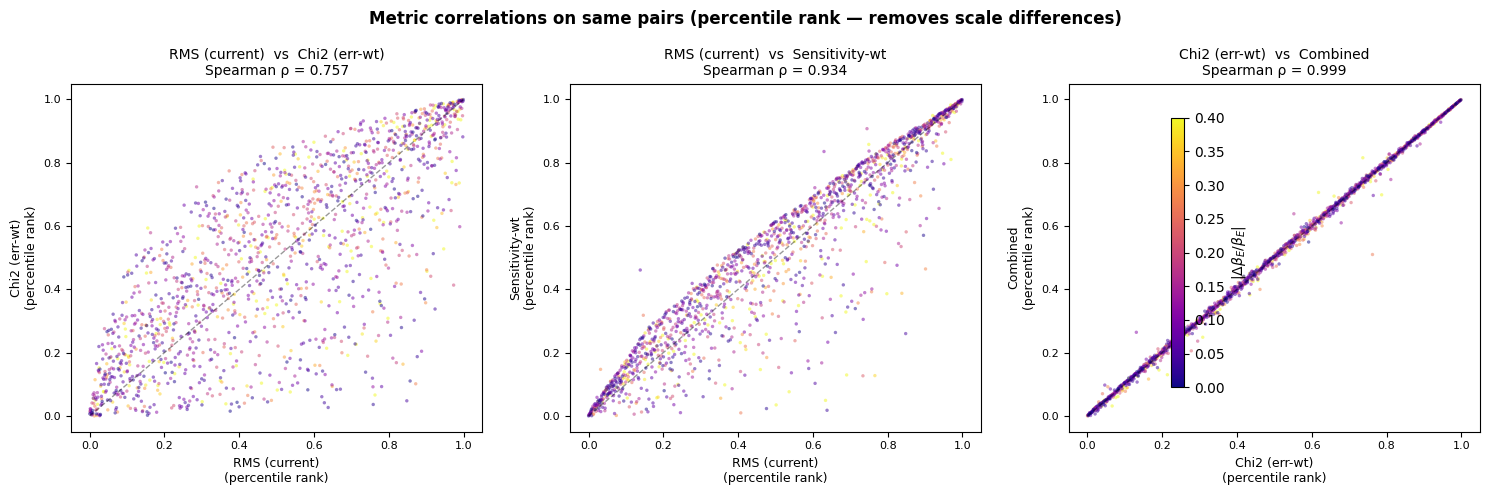

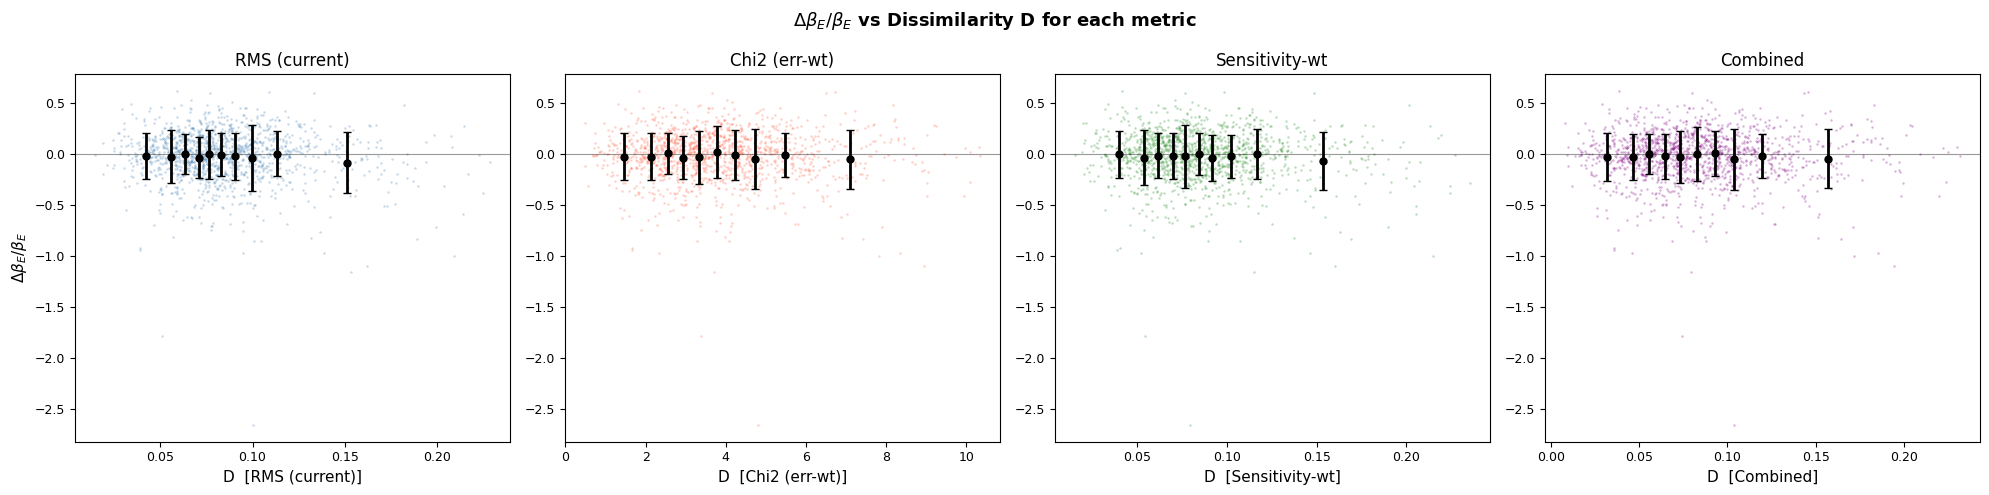

In [3]:
# ==============================================================================
# METRIC COMPARISON CELL: RMS vs Chi2 vs Sensitivity-Weighted vs Combined
# Fully self-contained. Recommended: N_TEST <= 3000.
#
# KD-TREE MECHANICS — answers to your questions:
# ─────────────────────────────────────────────────────────────────────────────
# Q: Are we using the nearest found pair?
#    YES. n_neighbors=2 finds exactly the 1 nearest neighbor per lens.
#    There is NO distance threshold during pairing — every lens is paired
#    regardless of how dissimilar it is. The D < 0.15 cut happens AFTER.
#
# Q: How does KD-Tree decide what pairs to keep?
#    1. Each of N lenses finds its 1 nearest neighbor → N candidate pairs
#    2. Each pair is sorted: (min(i,j), max(i,j))
#    3. np.unique() deduplicates: if i→j AND j→i, kept once
#    4. If i→j but j→k (k≠i), BOTH (i,j) AND (j,k) survive
#    → Result: ~N/1.4 unique pairs. NOT a perfect matching — one lens
#      can appear in multiple pairs, creating statistical correlations.
#
# Q: Can chi2/sensitivity metrics be used directly in KD-Tree?
#    RMS metric:        EXACT   — log transform proven and validated
#    Chi2 (err-wt):     APPROX  — scale log features by 1/eps_k
#    Sensitivity-wt:    APPROX  — scale ln(z_D) by median(w_zD)
#    Combined:          APPROX  — both scalings combined
#    Any metric exactly: possible via sklearn BallTree pyfunc (~1000x slower)
#
# STRATEGY:
#    Part A — same pairs (log KD-Tree), 4 metrics applied post-hoc.
#             Answers: which metric better ranks pair quality?
#    Part B — metric-matched pairing: each KD-Tree variant uses its own
#             metric for pairing, then all evaluated with RMS for fairness.
# ==============================================================================
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import spatial
from scipy.stats import spearmanr
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from pdspl_utils.pairing import (
    normalize_data,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
)
from pdspl_utils.inference import beta_double_source_plane

# ==============================================================================
# 0. CONFIG
# ==============================================================================
N_TEST          = 2000
TEST_SAMPLE_KEY = 'lsst_y10'
cosmo_true      = FlatLambdaCDM(H0=70, Om0=0.3)
MAX_DISSIM      = 0.15

CATALOG_PATHS = {
    'lsst_y1':                   "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits",
    'lsst_y10':                  "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits",
    'lsst_4most_spec-z':         "../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits",
    'lsst_4most_spec-z_sigma_v': "../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits",
}

# Fractional errors per feature — used for chi2 KD-Tree approximation.
# For z_D: sigma_z / z ~ 0.03*(1+z)/z at z~1 gives ~0.05 for photo-z,
#          and ~1e-4/z for spec-z.
FRAC_ERRORS = {
    'z_D':             0.05 if TEST_SAMPLE_KEY in ['lsst_y1', 'lsst_y10'] else 1e-4,
    'R_e_arcsec':      0.05,
    'flux_D_i':        0.01,
    'flux_ratio_D_gr': 0.014,
    'flux_ratio_D_ri': 0.014,
    'sigma_v_D':       0.033,  # 10 km/s / ~300 km/s
}

# ==============================================================================
# 1. KD-TREE PAIRING FUNCTIONS
# ==============================================================================
def _build_pairs(pts, n_neighbors=2, unique_pairs=True):
    """Shared KD-Tree construction and pair extraction."""
    n = len(pts)
    _, idx = spatial.KDTree(pts).query(pts, k=n_neighbors)
    base     = np.repeat(np.arange(n), n_neighbors - 1)
    neighbor = idx[:, 1:].flatten()
    pairs    = np.column_stack((base, neighbor))
    if unique_pairs:
        pairs = np.sort(pairs, axis=1)
        pairs, _ = np.unique(pairs, axis=0, return_index=True)
    return pairs

def get_kdtree_log(table, keys, n_neighbors=2):
    """Exact RMS metric via log transform (validated)."""
    pts = np.stack([np.log(np.array(table[k], dtype=float)) for k in keys], axis=1)
    return _build_pairs(pts, n_neighbors)

def get_kdtree_chi2_approx(table, keys, frac_errors, n_neighbors=2):
    """
    Chi2 metric approximation in KD-Tree.
    
    Derivation: chi2_k = (x2-x1)^2 / (sigma1^2+sigma2^2)
                       ≈ (ln x2 - ln x1)^2 / (2 eps_k^2)   [log approx + uniform errors]
    
    So scaling log features by 1/eps_k makes Euclidean distance ∝ chi2.
    Exact when fractional errors are uniform across the catalog for each feature.
    """
    pts = np.stack([
        np.log(np.array(table[k], dtype=float)) / frac_errors.get(k, 1.0)
        for k in keys
    ], axis=1)
    return _build_pairs(pts, n_neighbors)

def get_kdtree_sensitivity_approx(table, keys, frac_errors, cosmo, n_neighbors=2):
    """
    Combined sensitivity + chi2 metric approximation in KD-Tree.
    
    For z_D: scale ln(z_D) by median(w_zD) / eps_zD
             where w_zD = |d ln(beta_E) / d ln(z_D)| (analytic, finite diff)
    For others: scale ln(x_k) by 1/eps_k (same as chi2 approx)
    
    Approximate because w_zD varies with z_D — we use the catalog median
    as a constant representative value.
    """
    z_D = np.array(table['z_D'], dtype=float)
    try:
        z_S = np.array(table['z_S'], dtype=float)
    except KeyError:
        z_S = z_D * 2.0
        print("  Warning: z_S column not found, using 2*z_D as proxy")
    
    z_S_med = np.median(z_S)
    z_S1    = np.minimum(z_S, z_S_med)
    z_S2    = np.maximum(z_S, z_S_med)
    # Ensure z_S1 < z_S2 and both > z_D
    z_S2    = np.where(z_S2 <= z_S1, z_S1 + 0.1, z_S2)

    dz   = 1e-4
    b_hi = beta_double_source_plane(z_D + dz, z_S1, z_S2, cosmo)
    b_lo = beta_double_source_plane(z_D - dz, z_S1, z_S2, cosmo)
    b_0  = beta_double_source_plane(z_D,      z_S1, z_S2, cosmo)
    w    = np.where(b_0 > 0, np.abs(z_D / b_0 * (b_hi - b_lo) / (2 * dz)), np.nan)
    w_med = np.nanmedian(w)
    print(f"  Median |d ln(β_E)/d ln(z_D)| = {w_med:.3f}")

    scale = {k: 1.0 / frac_errors.get(k, 1.0) for k in keys}
    scale['z_D'] = w_med / frac_errors.get('z_D', 1.0)

    pts = np.stack([
        np.log(np.array(table[k], dtype=float)) * scale[k] for k in keys
    ], axis=1)
    return _build_pairs(pts, n_neighbors)

# ==============================================================================
# 2. DISSIMILARITY METRICS (applied post-pairing to pairs table)
# ==============================================================================
def _get_sensitivity_weights(pt_err, cosmo):
    """Computes |d ln(beta_E) / d ln(z_D)| for each pair using exact z_S1, z_S2."""
    z_D  = np.array(pt_err['z_D'],  dtype=float)
    z_S1 = np.array(pt_err['z_S1'], dtype=float)
    z_S2 = np.array(pt_err['z_S2'], dtype=float)
    dz   = 1e-4
    b_hi = beta_double_source_plane(z_D + dz, z_S1, z_S2, cosmo)
    b_lo = beta_double_source_plane(z_D - dz, z_S1, z_S2, cosmo)
    b_0  = beta_double_source_plane(z_D,      z_S1, z_S2, cosmo)
    w    = np.where(b_0 > 0, np.abs(z_D / b_0 * (b_hi - b_lo) / (2 * dz)), 1.0)
    return np.where(np.isfinite(w), w, 1.0)

def _weighted_rms(pt_err, dissim_keys, weights):
    """D = sqrt(sum(w_k^2 * r_k^2) / sum(w_k^2)). Normalised so D ~ same scale as RMS."""
    w = np.array([weights[k] for k in dissim_keys])  # (N_feat, N_pairs)
    r = np.array([pt_err[k]  for k in dissim_keys])  # (N_feat, N_pairs)
    return np.sqrt(np.sum(w**2 * r**2, axis=0) / np.sum(w**2, axis=0))

def metric_rms(pt_err, dissim_keys, cosmo=None, frac_errors=None):
    """Current default: equal weight for all features."""
    return _weighted_rms(pt_err, dissim_keys,
                         {k: np.ones(len(pt_err)) for k in dissim_keys})

def metric_chi2(pt_err, dissim_keys, cosmo=None, frac_errors=None):
    """Error-weighted chi2 (uses injected err_ columns from noise injection)."""
    return compute_dissimilarity(pt_err, dissim_keys, method='chi2')

def metric_sensitivity(pt_err, dissim_keys, cosmo, frac_errors=None):
    """
    beta_E sensitivity weighting.
    
    z_D gets weight w_zD = |d ln(beta_E) / d ln(z_D)| — analytic from geometry.
    Photometric proxies (R_e, flux, flux_ratio, sigma_v) get weight = 1.
    These are proxies for gamma_pl / lambda_MST with no known analytic sensitivity.
    """
    w_zD = _get_sensitivity_weights(pt_err, cosmo)
    weights = {k: (w_zD if k == 'rel_diff_z_D' else np.ones(len(pt_err)))
               for k in dissim_keys}
    return _weighted_rms(pt_err, dissim_keys, weights)

def metric_combined(pt_err, dissim_keys, cosmo, frac_errors):
    """
    Sensitivity × error weighting (Fisher-optimal).
    
    w_k = sensitivity_k / eps_k
    
    Gives higher weight to features that both:
      (a) have large impact on beta_E (sensitivity), AND
      (b) are well-measured (small eps_k).
    For photo-z samples, z_D sensitivity is high but eps_z is large → moderate weight.
    For spec-z samples, both high sensitivity AND small eps_z → z_D dominates.
    """
    w_zD = _get_sensitivity_weights(pt_err, cosmo)
    weights = {}
    for k in dissim_keys:
        base = k.replace('rel_diff_', '')
        eps  = frac_errors.get(base, 0.1)
        weights[k] = (w_zD / eps) if k == 'rel_diff_z_D' else np.full(len(pt_err), 1.0 / eps)
    return _weighted_rms(pt_err, dissim_keys, weights)

METRICS = {
    'RMS (current)':  {'fn': metric_rms,         'color': 'steelblue',   'ls': '-',   'lw': 2.5},
    'Chi2 (err-wt)':  {'fn': metric_chi2,        'color': 'tomato',      'ls': '--',  'lw': 2.0},
    'Sensitivity-wt': {'fn': metric_sensitivity, 'color': 'forestgreen', 'ls': '-.',  'lw': 2.0},
    'Combined':       {'fn': metric_combined,    'color': 'purple',      'ls': ':',   'lw': 2.5},
}

PAIRING_METHODS = {
    'Log (RMS)':     {'fn': lambda t, k: get_kdtree_log(t, k),
                      'metric_fn': metric_rms},
    'Chi2-approx':   {'fn': lambda t, k: get_kdtree_chi2_approx(t, k, FRAC_ERRORS),
                      'metric_fn': metric_chi2},
    'Sens-approx':   {'fn': lambda t, k: get_kdtree_sensitivity_approx(t, k, FRAC_ERRORS, cosmo_true),
                      'metric_fn': metric_sensitivity},
}

# ==============================================================================
# 3. LOAD + PREPROCESS
# ==============================================================================
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['flux_D_g']        = 10**(-0.4 * table['mag_D_g'])
    table['flux_D_r']        = 10**(-0.4 * table['mag_D_r'])
    table['flux_D_i']        = 10**(-0.4 * table['mag_D_i'])
    table['flux_ratio_D_gr'] = table['flux_D_g'] / table['flux_D_r']
    table['flux_ratio_D_ri'] = table['flux_D_r'] / table['flux_D_i']
    table['log_R_e_kpc']     = np.log10(table['R_e_kpc'])
    table['log_sigma_v_D']   = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

print(f"Loading catalog for '{TEST_SAMPLE_KEY}'...")
raw_table = preprocess_ggl_table(CATALOG_PATHS[TEST_SAMPLE_KEY])
if TEST_SAMPLE_KEY == 'lsst_y1':
    raw_table.sort('snr_i', reverse=True)
    raw_table = raw_table[:int(len(raw_table) / np.sqrt(10))]
elif TEST_SAMPLE_KEY in ['lsst_4most_spec-z', 'lsst_4most_spec-z_sigma_v']:
    raw_table.sort('mag_D_r')
    raw_table = raw_table[:5000 if 'sigma_v' in TEST_SAMPLE_KEY else 10000]
test_table = raw_table[:N_TEST]
print(f"Loaded: {len(raw_table)} total rows, using {len(test_table)}\n")

# ==============================================================================
# 4. KEYS + ERROR CONFIG
# ==============================================================================
base_pairing_keys = ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri']
base_dissim_keys  = ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i',
                     'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri']
if TEST_SAMPLE_KEY == 'lsst_4most_spec-z_sigma_v':
    pairing_keys = base_pairing_keys + ['sigma_v_D']
    dissim_keys  = base_dissim_keys  + ['rel_diff_sigma_v_D']
else:
    pairing_keys = base_pairing_keys
    dissim_keys  = base_dissim_keys

error_config = {
    'sigma_v_D':       10.0,
    'R_e_arcsec':      lambda t: 0.05  * t['R_e_arcsec'],
    'flux_D_i':        lambda t: 0.01  * t['flux_D_i'],
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'],
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri'],
    'z_D': (lambda t: 0.03 * (1 + t['z_D'])) if TEST_SAMPLE_KEY in ['lsst_y1', 'lsst_y10'] else 1e-4,
}
np.random.seed(42)
test_table_err = inject_observational_errors(test_table, error_config)

# ==============================================================================
# 5. PART A — SAME PAIRS, 4 METRICS
# Canonical pairs from log KD-Tree, then all 4 metrics applied post-hoc.
# ==============================================================================
print("=" * 60)
print("Part A: Same pairs, 4 dissimilarity metrics")
print("=" * 60)
idx_log = get_kdtree_log(test_table_err, pairing_keys)
pt      = get_pairs_table_PDSPL(test_table,     idx_log, cosmo_true)
pt_err  = get_pairs_table_PDSPL(test_table_err, idx_log, cosmo_true)
beta_E  = np.array(pt['rel_diff_beta_E'])

D_vals = {}
for name, m in METRICS.items():
    D_vals[name] = m['fn'](pt_err, dissim_keys, cosmo_true, FRAC_ERRORS)
    # For fair threshold comparison: use 50th percentile of this metric as cutoff
    thresh = np.nanpercentile(D_vals[name], 50)
    mask   = (D_vals[name] < thresh) & np.isfinite(beta_E)
    sigma  = np.nanstd(beta_E[mask]) if mask.sum() > 10 else np.nan
    print(f"  {name:<20}  mean D={np.nanmean(D_vals[name]):.4f}  "
          f"sigma(beta_E | top 50%)={sigma:.4f}")

# ==============================================================================
# 6. PART B — METRIC-MATCHED PAIRING
# Each KD-Tree variant pairs using its own metric, then ALL are evaluated
# with RMS for a fair apples-to-apples comparison.
# ==============================================================================
print(f"\n{'='*60}")
print("Part B: Metric-matched pairing methods (eval: RMS metric)")
print("="*60)

part_b = {}
for pname, pconfig in PAIRING_METHODS.items():
    t0  = time.time()
    idx = pconfig['fn'](test_table_err, pairing_keys)
    dt  = time.time() - t0

    pt_b     = get_pairs_table_PDSPL(test_table,     idx, cosmo_true)
    pt_b_err = get_pairs_table_PDSPL(test_table_err, idx, cosmo_true)
    beta_b   = np.array(pt_b['rel_diff_beta_E'])

    # Common RMS evaluation for fair comparison
    D_rms  = metric_rms(pt_b_err, dissim_keys)
    mask   = (D_rms < MAX_DISSIM) & np.isfinite(beta_b)
    sigma  = np.nanstd(beta_b[mask]) if mask.sum() > 10 else np.nan

    part_b[pname] = {'D_rms': D_rms, 'beta': beta_b, 'mask': mask, 'sigma': sigma}
    print(f"  {pname:<18}  {len(idx):5d} pairs  [{dt:.2f}s]  "
          f"frac D<0.15={mask.mean():.3f}  sigma(beta_E|D<0.15)={sigma:.4f}")

# ==============================================================================
# 7. VISUALIZATION
# ==============================================================================

# ── Figure 1: sigma(beta_E) vs fraction of pairs kept ─────────────────────────
# Uses percentile ranking so all metrics are on the same [0,1] x-axis.
# This removes the absolute scale difference between metrics and shows
# purely how well each metric RANKS pairs by quality.
fig1, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(14, 5.5))
fig1.suptitle('Which metric best predicts pair quality?', fontsize=14, fontweight='bold')

fractions = np.linspace(0.05, 1.0, 60)

for name, m in METRICS.items():
    D     = D_vals[name]
    order = np.argsort(D)      # rank from best (lowest D) to worst
    sigmas = []
    for f in fractions:
        k    = max(int(f * len(D)), 10)
        b    = beta_E[order[:k]]
        sigmas.append(np.nanstd(b[np.isfinite(b)]))
    ax_a.plot(fractions, sigmas, color=m['color'], ls=m['ls'], lw=m['lw'], label=name)

ax_a.set_xlabel('Fraction of pairs kept (best → worst by metric)', fontsize=12)
ax_a.set_ylabel(r'$\sigma(\Delta\beta_E/\beta_E)$ for kept pairs', fontsize=12)
ax_a.set_title('Part A: Same pairs, different metrics\n'
               'Lower = metric better at identifying quality pairs', fontsize=11)
ax_a.legend(fontsize=10, frameon=True)
ax_a.tick_params(labelsize=10)

# Part B: dissimilarity distributions by pairing method (common RMS scale)
colors_b = ['steelblue', 'tomato', 'forestgreen']
for (pname, r), col in zip(part_b.items(), colors_b):
    D_finite = r['D_rms'][np.isfinite(r['D_rms'])]
    ax_b.hist(D_finite, bins=np.linspace(0, 0.4, 60), density=True,
              histtype='step', lw=2, color=col,
              label=f"{pname}  σ(β_E|D<0.15)={r['sigma']:.3f}")
ax_b.axvline(MAX_DISSIM, color='k', ls='--', lw=1.5, alpha=0.6, label='D=0.15')
ax_b.set_xlabel(r'RMS Dissimilarity $\mathcal{D}$', fontsize=12)
ax_b.set_ylabel('Density', fontsize=12)
ax_b.set_title('Part B: Different pairing methods\n'
               'All evaluated with common RMS metric', fontsize=11)
ax_b.legend(fontsize=10, frameon=True)
ax_b.tick_params(labelsize=10)
fig1.tight_layout()
plt.show()

# ── Figure 2: Metric correlations (percentile rank, colored by |beta_E|) ──────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('Metric correlations on same pairs (percentile rank — removes scale differences)',
              fontsize=12, fontweight='bold')

norm_b = mcolors.Normalize(vmin=0, vmax=0.4)
cmap_b = plt.cm.plasma

comparisons = [
    ('RMS (current)',  'Chi2 (err-wt)'),
    ('RMS (current)',  'Sensitivity-wt'),
    ('Chi2 (err-wt)', 'Combined'),
]
for ax, (mx, my) in zip(axes2, comparisons):
    Dx = np.argsort(np.argsort(D_vals[mx])) / len(D_vals[mx])   # percentile rank
    Dy = np.argsort(np.argsort(D_vals[my])) / len(D_vals[my])
    order = np.argsort(np.abs(beta_E))[::-1]                      # worst on bottom
    ax.scatter(Dx[order], Dy[order], c=np.abs(beta_E[order]),
               cmap=cmap_b, norm=norm_b, s=6, alpha=0.5,
               linewidths=0, rasterized=True)
    ax.plot([0, 1], [0, 1], 'k--', lw=1.0, alpha=0.4)
    rho, _ = spearmanr(D_vals[mx], D_vals[my])
    ax.set_title(f'{mx}  vs  {my}\nSpearman ρ = {rho:.3f}', fontsize=10)
    ax.set_xlabel(f'{mx}\n(percentile rank)', fontsize=9)
    ax.set_ylabel(f'{my}\n(percentile rank)', fontsize=9)
    ax.tick_params(labelsize=8)
fig2.colorbar(plt.cm.ScalarMappable(norm=norm_b, cmap=cmap_b),
              ax=axes2, shrink=0.7, pad=0.02, label=r'$|\Delta\beta_E/\beta_E|$')
fig2.tight_layout()
plt.show()

# ── Figure 3: beta_E vs D scatter for each metric ─────────────────────────────
fig3, axes3 = plt.subplots(1, len(METRICS), figsize=(5*len(METRICS), 5))
fig3.suptitle(r'$\Delta\beta_E/\beta_E$ vs Dissimilarity D for each metric',
              fontsize=13, fontweight='bold')
for ax, (name, m) in zip(axes3, METRICS.items()):
    D        = D_vals[name]
    D_max    = np.nanpercentile(D, 99)
    mask_plt = np.isfinite(beta_E) & (D < D_max)
    ax.scatter(D[mask_plt], beta_E[mask_plt], s=3, alpha=0.3,
               color=m['color'], linewidths=0, rasterized=True)
    # Binned scatter (median D, mean ± std beta_E)
    pct = np.nanpercentile(D[mask_plt], np.arange(0, 101, 10))
    dig = np.digitize(D[mask_plt], pct)
    bx, by, be = [], [], []
    for i in range(1, len(pct)):
        bm = (dig == i)
        if bm.sum() > 5:
            bx.append(np.median(D[mask_plt][bm]))
            by.append(np.nanmean(beta_E[mask_plt][bm]))
            be.append(np.nanstd(beta_E[mask_plt][bm]))
    ax.errorbar(bx, by, yerr=be, fmt='o', color='k', markersize=5,
                capsize=3, elinewidth=2, zorder=5)
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)
    ax.set_xlabel(f'D  [{name}]', fontsize=11)
    ax.set_ylabel(r'$\Delta\beta_E/\beta_E$' if ax is axes3[0] else '', fontsize=11)
    ax.set_title(name, fontsize=12)
    ax.tick_params(labelsize=9)
fig3.tight_layout()
plt.show()

Loading catalogs...
  LSST  : 116,471 lenses
  4MOST : 16,046 lenses

Sub-sample sizes:
  LSST Y1                  : 36,831
  LSST Y10                 : 116,471
  4MOST spec-z             : 10,000
  4MOST spec-z + sigma_v   : 5,000



MC Realizations: 100%|██████████| 100/100 [02:06<00:00,  1.26s/it]



MC complete. Summary:
  Sample                                Mean # Pairs  Mean σ(β_E)
  ---------------------------------------------------------------
  LSST Y1                                      27149       0.1987
  LSST Y10                                     85818       0.1925
  4MOST ($z^{\rm spec}$)                        7322       0.0779
  4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)           3710       0.0838


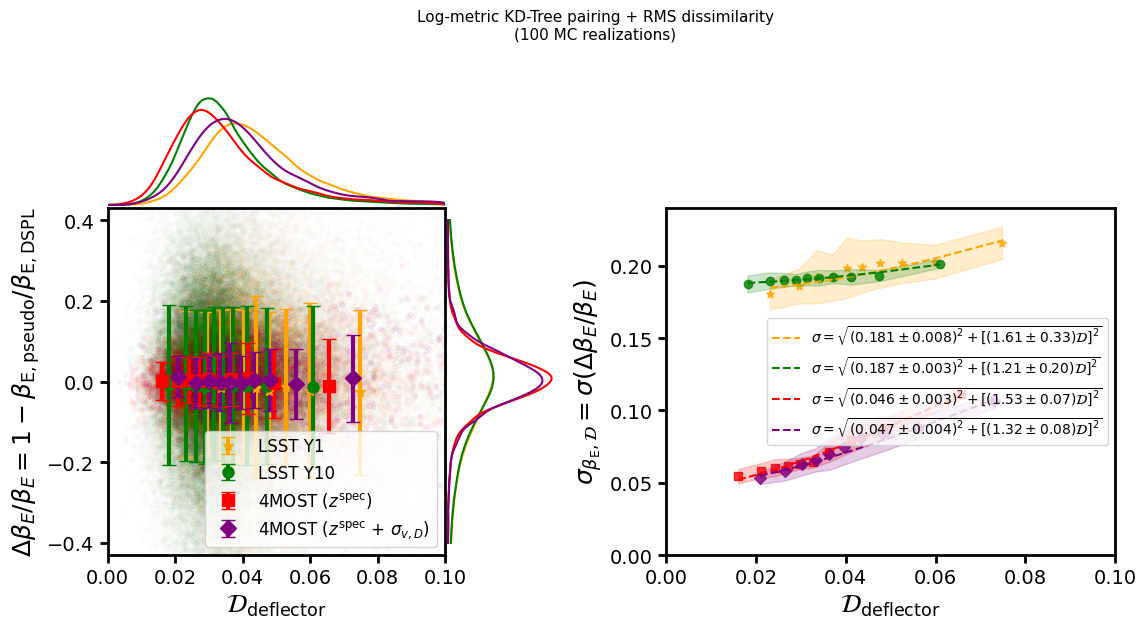

In [7]:
# ==============================================================================
# SELF-CONTAINED: Beta_E vs Dissimilarity MC Plot
# Uses: log-metric KD-Tree pairing + RMS dissimilarity
# Reproduces the beta_E vs D figure with the corrected pairing scheme.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from scipy import spatial
from pdspl_utils.pairing import (
    normalize_data,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
    plot_beta_E_vs_D_MC,
)

# ==============================================================================
# 0. CONFIG
# ==============================================================================
N_realizations   = 100       # Set to 100 for final paper
MAX_DISSIMILARITY = 0.1
cosmo_true        = FlatLambdaCDM(H0=70, Om0=0.3)

CATALOG_PATHS = {
    'lsst':   "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits",
    '4most':  "../data/GGL_Catalogs/GGL_20000.0_SQDEG_4MOST_SNR_20_seeing_0.2_contrast_no.fits",
}

# ==============================================================================
# 1. LOCAL get_kdtree_pairs WITH LOG-METRIC
# (mirrors the updated pairing.py — included here for self-containment)
# ==============================================================================
def get_kdtree_pairs(table, pairing_keys, norm_type='zscore', n_neighbors=2,
                     unique_pairs=True, use_log_metric=False):
    if use_log_metric:
        points = np.stack(
            [np.log(np.array(table[pk], dtype=float)) for pk in pairing_keys], axis=1
        )
        if not np.all(np.isfinite(points)):
            raise ValueError(
                "use_log_metric=True requires all pairing features to be strictly "
                "positive. Check for zeros or negatives in pairing_keys."
            )
    else:
        points = np.stack(
            [normalize_data(table[pk], type=norm_type) for pk in pairing_keys], axis=1
        )

    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=n_neighbors)

    if n_neighbors < 2:
        return np.empty((0, 2), dtype=int), np.empty(0)

    n_points         = len(points)
    base_indices     = np.repeat(np.arange(n_points), n_neighbors - 1)
    neighbor_indices = indices[:, 1:].flatten()
    flat_distances   = distances[:, 1:].flatten()
    pair_indices     = np.column_stack((base_indices, neighbor_indices))

    if unique_pairs:
        pair_indices = np.sort(pair_indices, axis=1)
        pair_indices, unique_pairs_idxs = np.unique(pair_indices, axis=0, return_index=True)
        flat_distances = flat_distances[unique_pairs_idxs]

    return pair_indices, flat_distances

# ==============================================================================
# 2. LOAD + PREPROCESS
# ==============================================================================
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['flux_D_g']        = 10**(-0.4 * table['mag_D_g'])
    table['flux_D_r']        = 10**(-0.4 * table['mag_D_r'])
    table['flux_D_i']        = 10**(-0.4 * table['mag_D_i'])
    table['flux_ratio_D_gr'] = table['flux_D_g'] / table['flux_D_r']
    table['flux_ratio_D_ri'] = table['flux_D_r'] / table['flux_D_i']
    table['log_R_e_kpc']     = np.log10(table['R_e_kpc'])
    table['log_sigma_v_D']   = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

print("Loading catalogs...")
raw_lsst  = preprocess_ggl_table(CATALOG_PATHS['lsst'])
raw_4most = preprocess_ggl_table(CATALOG_PATHS['4most'])
print(f"  LSST  : {len(raw_lsst):,} lenses")
print(f"  4MOST : {len(raw_4most):,} lenses\n")

# ==============================================================================
# 3. BUILD SUB-SAMPLES
# ==============================================================================
# LSST Y10 — full catalog
GGL_table_LSST_Y10 = raw_lsst.copy()

# LSST Y1 — top 1/sqrt(10) by SNR
GGL_table_LSST_Y1 = raw_lsst.copy()
GGL_table_LSST_Y1.sort('snr_i', reverse=True)
GGL_table_LSST_Y1 = GGL_table_LSST_Y1[:int(len(raw_lsst) / np.sqrt(10))]

# 4MOST spec-z — brightest 10k
GGL_table_4MOST_specz = raw_4most.copy()
GGL_table_4MOST_specz.sort('mag_D_r')
GGL_table_4MOST_specz = GGL_table_4MOST_specz[:10000]

# 4MOST spec-z + sigma_v — brightest 5k
GGL_table_4MOST_specz_sigma = raw_4most.copy()
GGL_table_4MOST_specz_sigma.sort('mag_D_r')
GGL_table_4MOST_specz_sigma = GGL_table_4MOST_specz_sigma[:5000]

print("Sub-sample sizes:")
print(f"  LSST Y1                  : {len(GGL_table_LSST_Y1):,}")
print(f"  LSST Y10                 : {len(GGL_table_LSST_Y10):,}")
print(f"  4MOST spec-z             : {len(GGL_table_4MOST_specz):,}")
print(f"  4MOST spec-z + sigma_v   : {len(GGL_table_4MOST_specz_sigma):,}\n")

# ==============================================================================
# 4. CONFIGURE SAMPLES
# ==============================================================================
pdspl_samples = {
    "lsst_y1":                  {"table": GGL_table_LSST_Y1,          "name": "LSST Y1",                                    "color": "orange"},
    "lsst_y10":                 {"table": GGL_table_LSST_Y10,         "name": "LSST Y10",                                   "color": "green"},
    "lsst_4most_spec-z":        {"table": GGL_table_4MOST_specz,      "name": r"4MOST ($z^{\rm spec}$)",                    "color": "red"},
    "lsst_4most_spec-z_sigma_v":{"table": GGL_table_4MOST_specz_sigma,"name": r"4MOST ($z^{\rm spec}$ + $\sigma_{v, D}$)", "color": "purple"},
}

base_pairing_keys = ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri']
base_dissim_keys  = [
    'rel_diff_z_D', 'rel_diff_R_e_arcsec',
    'rel_diff_flux_D_i', 'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri'
]
base_error_config = {
    'sigma_v_D':       10.0,
    'R_e_arcsec':      lambda t: 0.05  * t['R_e_arcsec'],
    'flux_D_i':        lambda t: 0.01  * t['flux_D_i'],
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'],
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri'],
}

for key, s in pdspl_samples.items():
    # sigma_v added for the 4th sample
    if key == 'lsst_4most_spec-z_sigma_v':
        s['pairing_keys']     = base_pairing_keys + ['sigma_v_D']
        s['dissimilarity_keys'] = base_dissim_keys  + ['rel_diff_sigma_v_D']
    else:
        s['pairing_keys']     = base_pairing_keys
        s['dissimilarity_keys'] = base_dissim_keys

    # Photo-z error for LSST, spec-z for 4MOST
    s['error_config'] = base_error_config.copy()
    s['error_config']['z_D'] = (
        (lambda t: 0.03 * (1 + t['z_D'])) if key in ['lsst_y1', 'lsst_y10'] else 1e-4
    )

# ==============================================================================
# 5. MC PAIRING LOOP (log-metric KD-Tree + RMS dissimilarity)
# ==============================================================================
mc_results = {
    k: {'binned_dissim': [], 'binned_scatter': [], 'num_pairs': [], 'scatter_in_beta_E': []}
    for k in pdspl_samples
}

np.random.seed(42)

for i_realization in tqdm(range(N_realizations), desc="MC Realizations"):
    for sample_key, s in pdspl_samples.items():
        if len(s['table']) < 2:
            continue

        # --- Inject observational errors ---
        table_err = inject_observational_errors(s['table'], s['error_config'])

        # --- Pair on noisy table using log-metric KD-Tree ---
        indices, _ = get_kdtree_pairs(
            table_err, s['pairing_keys'], use_log_metric=True   # KEY CHANGE
        )

        # --- Build pairs tables ---
        # Noiseless: for science (beta_E)
        # Noisy:     for dissimilarity and pairing diagnostics
        pairs_table     = get_pairs_table_PDSPL(s['table'],  indices, cosmo_true)
        pairs_table_err = get_pairs_table_PDSPL(table_err,   indices, cosmo_true)

        # --- Compute RMS dissimilarity on noisy pairs ---
        pairs_table_err['dissimilarity'] = compute_dissimilarity(
            pairs_table_err, s['dissimilarity_keys'], method='rms'
        )

        # --- Store last realization's full pair tables for plotting ---
        s["pairs_analysis"] = {
            "pairs_table":            pairs_table,
            "pairs_table_with_errors": pairs_table_err,
            "num_lenses":             len(s['table']),
            "num_pairs":              len(pairs_table),
            "scatter_in_beta_E":      np.std(pairs_table['rel_diff_beta_E']),
            "pair_indices":           indices,
        }

        # --- Accumulate MC statistics ---
        mc_results[sample_key]['num_pairs'].append(len(pairs_table))
        mc_results[sample_key]['scatter_in_beta_E'].append(
            np.std(pairs_table['rel_diff_beta_E'])
        )

        # Bin scatter vs dissimilarity (percentile bins)
        mask = (
            (pairs_table_err['dissimilarity'] < MAX_DISSIMILARITY) &
            np.isfinite(pairs_table['rel_diff_beta_E'])
        )
        dissim_m     = pairs_table_err['dissimilarity'][mask]
        delta_beta_m = pairs_table['rel_diff_beta_E'][mask]

        percentiles = np.percentile(dissim_m, np.arange(0, 101, 10))
        digitized   = np.digitize(dissim_m, percentiles)

        run_dissim, run_scatter = [], []
        for i in range(1, len(percentiles)):
            bin_mask = (digitized == i)
            run_dissim.append(
                np.median(dissim_m[bin_mask])        if np.any(bin_mask) else np.nan
            )
            run_scatter.append(
                np.nanstd(delta_beta_m[bin_mask])    if np.any(bin_mask) else np.nan
            )

        mc_results[sample_key]['binned_dissim'].append(run_dissim)
        mc_results[sample_key]['binned_scatter'].append(run_scatter)

# Attach mean statistics (used in the LaTeX summary table)
for sample_key, s in pdspl_samples.items():
    if 'pairs_analysis' not in s:
        continue
    s["pairs_analysis"]["mean_num_pairs"]        = np.nanmean(mc_results[sample_key]['num_pairs'])
    s["pairs_analysis"]["mean_scatter_in_beta_E"] = np.nanmean(mc_results[sample_key]['scatter_in_beta_E'])

print("\nMC complete. Summary:")
print(f"  {'Sample':<35} {'Mean # Pairs':>14} {'Mean σ(β_E)':>12}")
print("  " + "-" * 63)
for key, s in pdspl_samples.items():
    if 'pairs_analysis' not in s: continue
    pa = s['pairs_analysis']
    print(f"  {s['name']:<35} {pa['mean_num_pairs']:>14.0f} {pa['mean_scatter_in_beta_E']:>12.4f}")

# ==============================================================================
# 6. PLOT beta_E vs D (quadrature fit)
# ==============================================================================
fig = plot_beta_E_vs_D_MC(
    pdspl_samples,
    mc_results,
    fit_type='quadrature',
    show_fit_eqn_label=True,
    plot_dissimilarity_range=(0, MAX_DISSIMILARITY),
)
plt.suptitle(
    "Log-metric KD-Tree pairing + RMS dissimilarity\n"
    f"({N_realizations} MC realizations)",
    fontsize=11, y=1.02
)
plt.show()

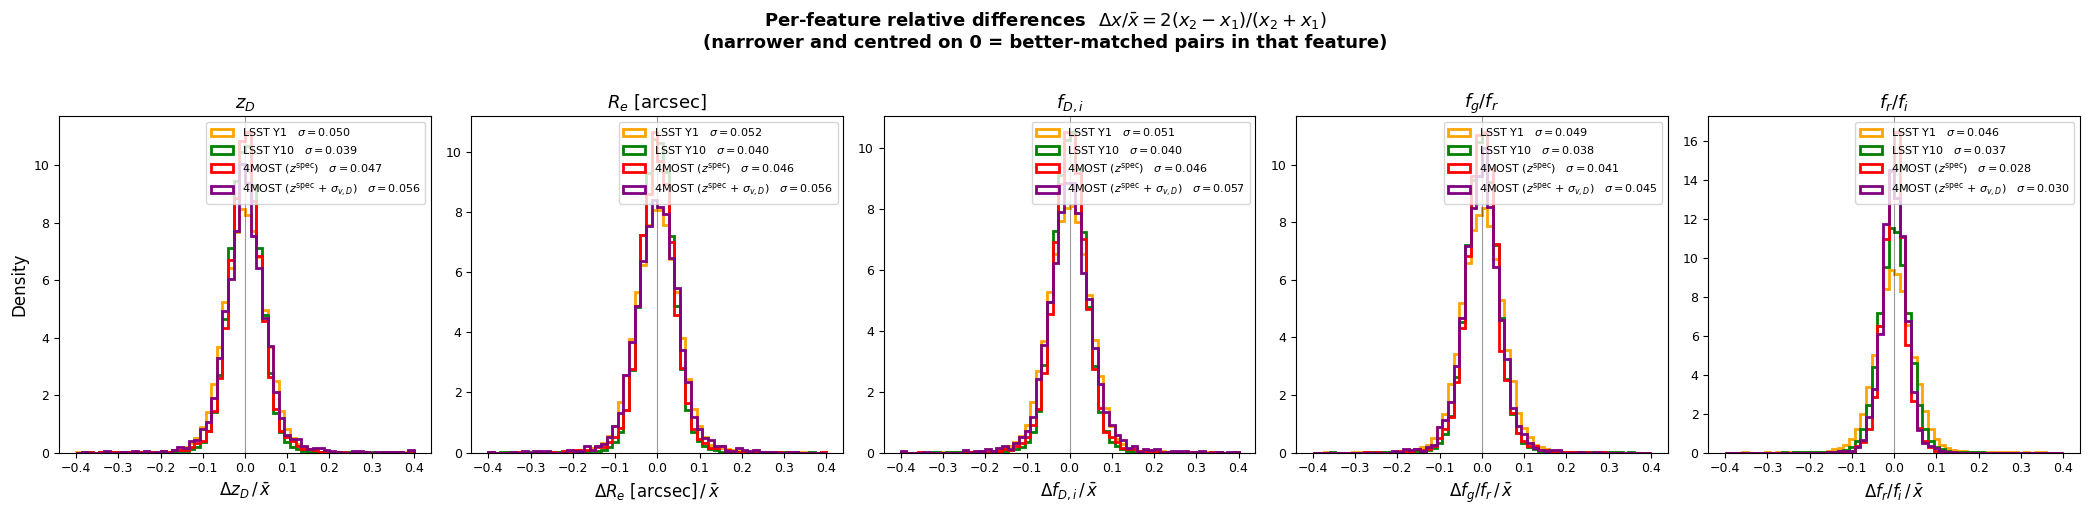

/tmp/ipykernel_121444/715474105.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


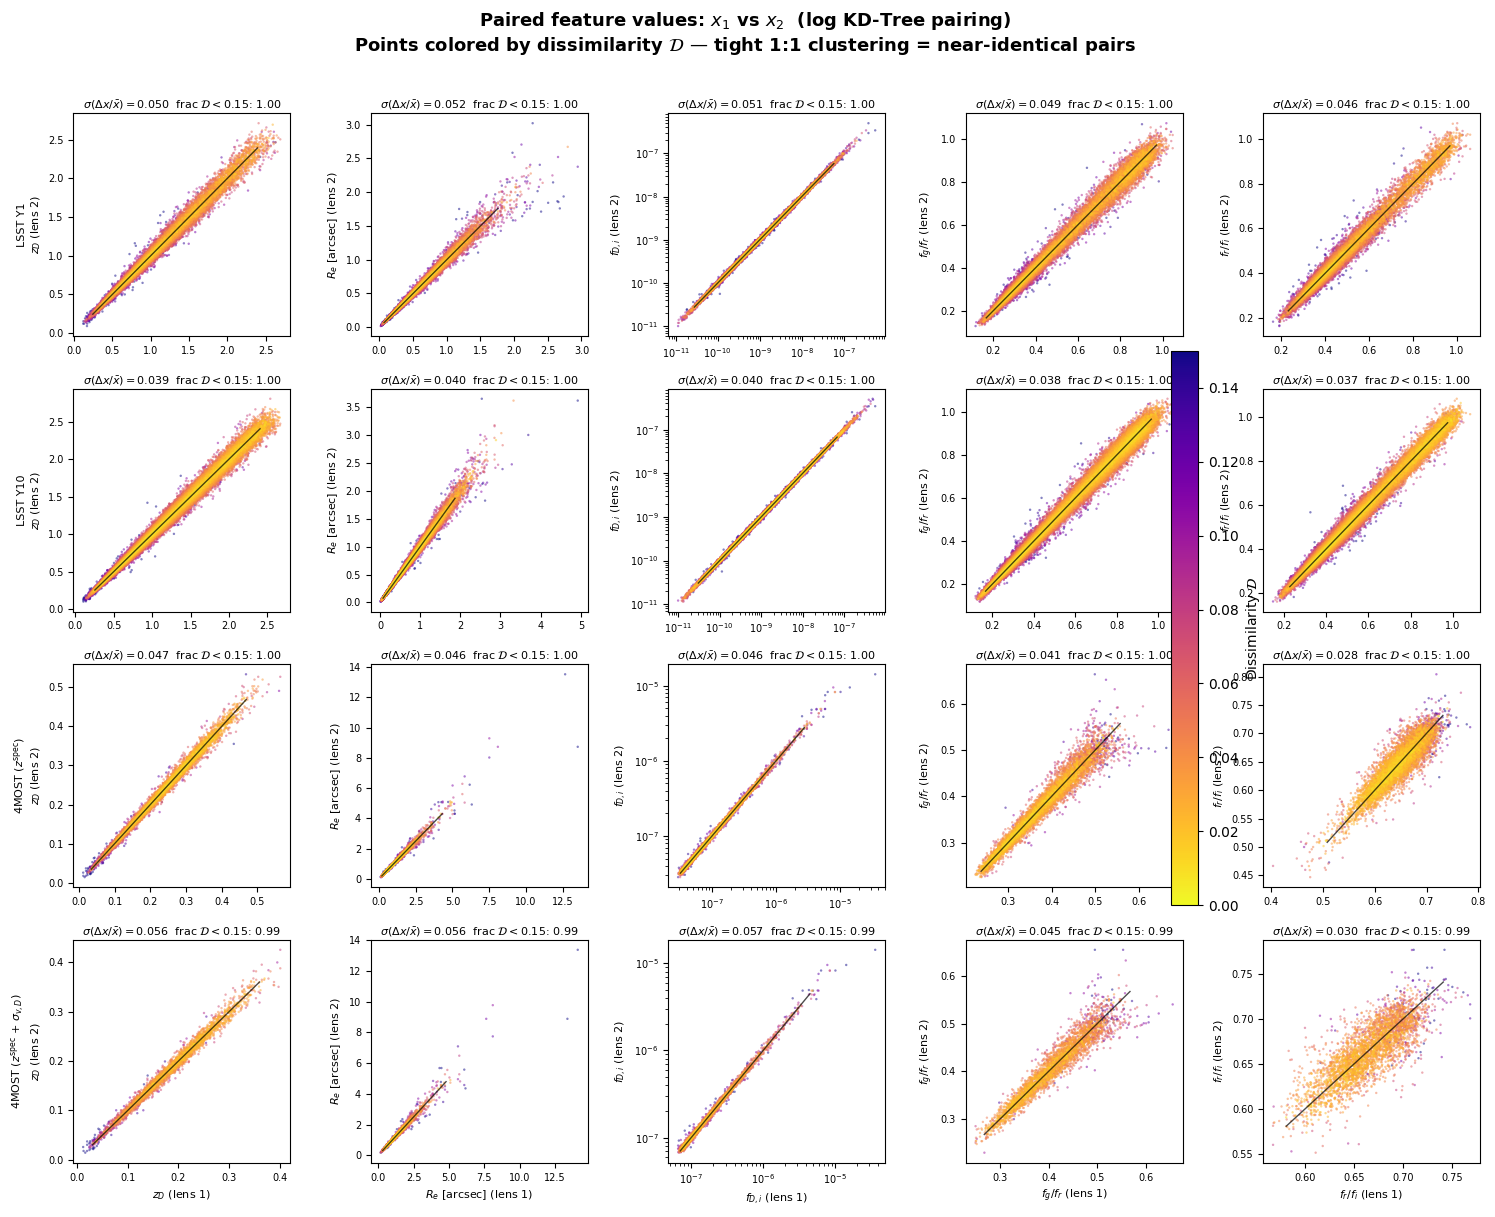

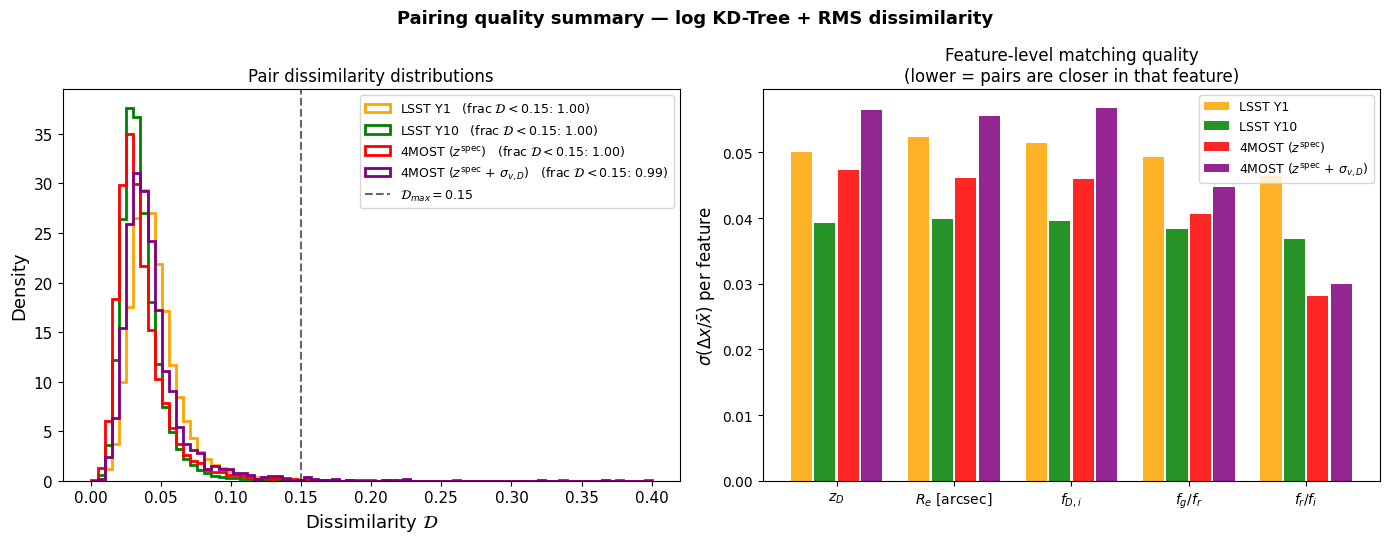

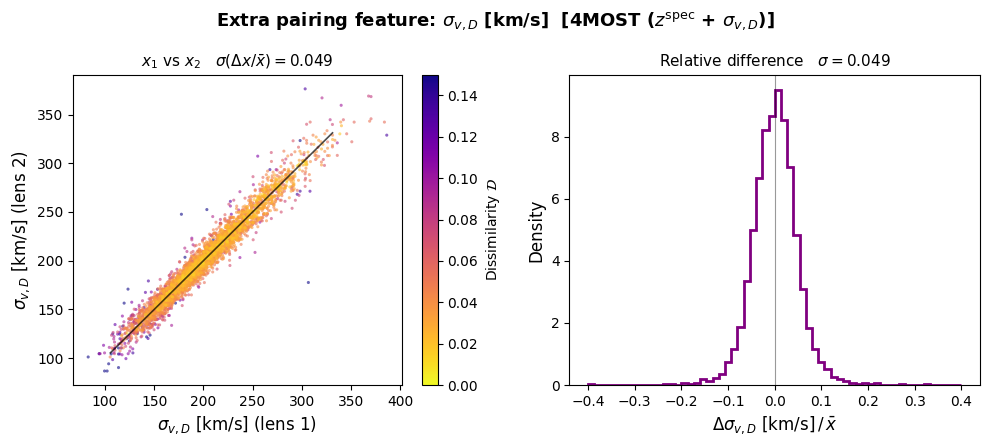

In [6]:
# ==============================================================================
# VISUALIZATION: Pairing Quality — Feature Closeness Check
# Run this cell immediately after the MC loop cell above.
# Uses the last MC realization's pairs tables stored in pdspl_samples.
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import numpy as np

# -------------------------------------------------------
# Config
# -------------------------------------------------------
FEATURE_LABELS = {
    'z_D':             r'$z_D$',
    'R_e_arcsec':      r'$R_e$ [arcsec]',
    'flux_D_i':        r'$f_{D,i}$',
    'flux_ratio_D_gr': r'$f_g / f_r$',
    'flux_ratio_D_ri': r'$f_r / f_i$',
    'sigma_v_D':       r'$\sigma_{v,D}$ [km/s]',
}
LOG_SCALE_FEATS = {'flux_D_i'}   # spans orders of magnitude
CLIP            = 0.4            # clip rel_diff display to ±40%

norm_d = mcolors.Normalize(vmin=0, vmax=MAX_DISSIMILARITY)
cmap_d = plt.cm.plasma_r

def get_reldiff(pt_err, pk):
    """Symmetric fractional difference for a single feature."""
    v1 = np.array(pt_err[f'{pk}_1'], dtype=float)
    v2 = np.array(pt_err[f'{pk}_2'], dtype=float)
    return 2 * (v2 - v1) / (v2 + v1)

def get_valid_pairs(s):
    """Returns (pairs_table, pairs_table_err, dissimilarity_array)."""
    pa      = s['pairs_analysis']
    pt      = pa['pairs_table']
    pt_err  = pa['pairs_table_with_errors']
    dissim  = np.array(pt_err['dissimilarity'])
    return pt, pt_err, dissim

# Collect valid samples (those that completed the MC loop)
valid_keys = [k for k in pdspl_samples if 'pairs_analysis' in pdspl_samples[k]]

# ============================================================
# FIGURE 1: Per-feature relative difference distributions
# All samples overlaid on each feature panel.
# Narrow, zero-centred = well-matched pairs in that feature.
# ============================================================
fig1, axes1 = plt.subplots(1, len(base_pairing_keys),
                            figsize=(4.2 * len(base_pairing_keys), 5))
fig1.suptitle(
    r'Per-feature relative differences  $\Delta x / \bar{x} = 2(x_2 - x_1)/(x_2 + x_1)$'
    '\n(narrower and centred on 0 = better-matched pairs in that feature)',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, pk in zip(axes1, base_pairing_keys):
    label = FEATURE_LABELS.get(pk, pk)
    for sample_key in valid_keys:
        s         = pdspl_samples[sample_key]
        _, pt_err, _ = get_valid_pairs(s)
        rd        = get_reldiff(pt_err, pk)
        rd_clean  = rd[np.isfinite(rd)]
        sigma     = np.nanstd(rd_clean)
        rd_clip   = np.clip(rd_clean, -CLIP, CLIP)

        ax.hist(rd_clip, bins=60, range=(-CLIP, CLIP), density=True,
                histtype='step', color=s['color'], lw=2.0,
                label=fr"{s['name']}   $\sigma={sigma:.3f}$")

    ax.axvline(0, color='k', lw=0.8, alpha=0.4)
    ax.set_xlabel(r'$\Delta$' + label + r'$\,/\,\bar{x}$', fontsize=12)
    ax.set_ylabel('Density' if ax is axes1[0] else '', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=8, frameon=True, loc='upper right')
    ax.tick_params(labelsize=9)

fig1.tight_layout()
plt.show()


# ============================================================
# FIGURE 2: x_1 vs x_2 scatter — the direct "near-identical" check
# N_samples rows × N_feat columns. Points colored by dissimilarity D.
# Good pairs cluster tightly on the 1:1 diagonal.
# ============================================================
n_feat   = len(base_pairing_keys)
n_sample = len(valid_keys)

fig2, axes2 = plt.subplots(
    n_sample, n_feat,
    figsize=(3.0 * n_feat, 3.0 * n_sample),
    squeeze=False
)
fig2.suptitle(
    r'Paired feature values: $x_1$ vs $x_2$  (log KD-Tree pairing)'
    '\nPoints colored by dissimilarity $\\mathcal{D}$ — tight 1:1 clustering = near-identical pairs',
    fontsize=13, fontweight='bold', y=1.01
)

for row_idx, sample_key in enumerate(valid_keys):
    s               = pdspl_samples[sample_key]
    _, pt_err, dissim = get_valid_pairs(s)

    for col_idx, pk in enumerate(base_pairing_keys):
        ax      = axes2[row_idx, col_idx]
        label   = FEATURE_LABELS.get(pk, pk)
        use_log = pk in LOG_SCALE_FEATS

        v1 = np.array(pt_err[f'{pk}_1'], dtype=float)
        v2 = np.array(pt_err[f'{pk}_2'], dtype=float)

        # Plot worst pairs first so best sit on top
        order = np.argsort(dissim)[::-1]
        sc = ax.scatter(v1[order], v2[order],
                        c=dissim[order], cmap=cmap_d, norm=norm_d,
                        s=3, alpha=0.5, linewidths=0, rasterized=True)

        # 1:1 reference line
        plo = min(np.nanpercentile(v1, 0.5),  np.nanpercentile(v2, 0.5))
        phi = max(np.nanpercentile(v1, 99.5), np.nanpercentile(v2, 99.5))
        ax.plot([plo, phi], [plo, phi], 'k-', lw=1.0, alpha=0.7, zorder=5)

        if use_log:
            ax.set_xscale('log')
            ax.set_yscale('log')

        # Per-panel annotation: σ(rel_diff) and frac D < MAX_DISSIMILARITY
        rms_rd    = np.nanstd(get_reldiff(pt_err, pk))
        frac_good = np.mean(dissim < MAX_DISSIMILARITY)
        ax.set_title(
            fr'$\sigma(\Delta x/\bar{{x}})={rms_rd:.3f}$'
            fr'  frac $\mathcal{{D}}<{MAX_DISSIMILARITY}$: {frac_good:.2f}',
            fontsize=8, pad=3
        )

        # Row label (sample name) on left-most column only
        if col_idx == 0:
            ax.set_ylabel(f'{s["name"]}\n{label} (lens 2)', fontsize=8)
        else:
            ax.set_ylabel(label + ' (lens 2)', fontsize=8)

        # Feature label on bottom row only
        if row_idx == n_sample - 1:
            ax.set_xlabel(label + ' (lens 1)', fontsize=8)
        else:
            ax.set_xlabel('')

        ax.tick_params(labelsize=7)

# Shared colorbar
fig2.colorbar(
    plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d),
    ax=axes2, shrink=0.6, pad=0.02,
    label=r'Dissimilarity $\mathcal{D}$'
)
fig2.tight_layout()
plt.show()


# ============================================================
# FIGURE 3: Summary per sample
# Left:  dissimilarity distributions for all samples
# Right: σ(rel_diff) per feature per sample — bar chart summary
# ============================================================
fig3, (ax_d, ax_s) = plt.subplots(1, 2, figsize=(14, 5.5))
fig3.suptitle(
    'Pairing quality summary — log KD-Tree + RMS dissimilarity',
    fontsize=13, fontweight='bold'
)

# Left: dissimilarity distributions
dissim_bins = np.linspace(0, 0.40, 80)
for sample_key in valid_keys:
    s             = pdspl_samples[sample_key]
    _, pt_err, dissim = get_valid_pairs(s)
    frac = np.mean(dissim < MAX_DISSIMILARITY)
    ax_d.hist(
        dissim[np.isfinite(dissim)], bins=dissim_bins,
        density=True, histtype='step', color=s['color'], lw=2,
        label=fr"{s['name']}   (frac $\mathcal{{D}}<{MAX_DISSIMILARITY}$: {frac:.2f})"
    )

ax_d.axvline(MAX_DISSIMILARITY, color='k', lw=1.5, ls='--',
             alpha=0.6, label=fr'$\mathcal{{D}}_{{max}}={MAX_DISSIMILARITY}$')
ax_d.set_xlabel(r'Dissimilarity $\mathcal{D}$', fontsize=13)
ax_d.set_ylabel('Density', fontsize=13)
ax_d.set_title('Pair dissimilarity distributions', fontsize=12)
ax_d.legend(fontsize=9, frameon=True)
ax_d.tick_params(labelsize=11)

# Right: σ(rel_diff) per feature per sample — grouped bar chart
n_groups = len(base_pairing_keys)
n_bars   = len(valid_keys)
x        = np.arange(n_groups)
width    = 0.8 / n_bars

for bar_idx, sample_key in enumerate(valid_keys):
    s             = pdspl_samples[sample_key]
    _, pt_err, _  = get_valid_pairs(s)
    sigmas = [
        np.nanstd(get_reldiff(pt_err, pk)[np.isfinite(get_reldiff(pt_err, pk))])
        for pk in base_pairing_keys
    ]
    offset = (bar_idx - n_bars / 2 + 0.5) * width
    bars   = ax_s.bar(x + offset, sigmas, width * 0.9,
                       color=s['color'], alpha=0.85, label=s['name'])

ax_s.set_xticks(x)
ax_s.set_xticklabels(
    [FEATURE_LABELS.get(pk, pk) for pk in base_pairing_keys],
    fontsize=11
)
ax_s.set_ylabel(r'$\sigma(\Delta x / \bar{x})$ per feature', fontsize=12)
ax_s.set_title(
    'Feature-level matching quality\n(lower = pairs are closer in that feature)',
    fontsize=12
)
ax_s.legend(fontsize=9, frameon=True)
ax_s.tick_params(labelsize=10)
ax_s.axhline(0, color='k', lw=0.5)

fig3.tight_layout()
plt.show()


# ============================================================
# FIGURE 4: sigma_v_D feature for the 4MOST+sigma sample
# Only shown if that sample is present — it has an extra pairing feature.
# ============================================================
sigma_v_key = 'lsst_4most_spec-z_sigma_v'
if sigma_v_key in valid_keys:
    s             = pdspl_samples[sigma_v_key]
    _, pt_err, dissim = get_valid_pairs(s)
    pk            = 'sigma_v_D'
    label         = FEATURE_LABELS.get(pk, pk)

    fig4, (ax_sc, ax_rd) = plt.subplots(1, 2, figsize=(10, 4.5))
    fig4.suptitle(
        fr"Extra pairing feature: {label}  [{s['name']}]",
        fontsize=13, fontweight='bold'
    )

    # x_1 vs x_2 scatter
    v1    = np.array(pt_err[f'{pk}_1'], dtype=float)
    v2    = np.array(pt_err[f'{pk}_2'], dtype=float)
    order = np.argsort(dissim)[::-1]
    sc    = ax_sc.scatter(v1[order], v2[order],
                          c=dissim[order], cmap=cmap_d, norm=norm_d,
                          s=5, alpha=0.6, linewidths=0, rasterized=True)
    plo = min(np.nanpercentile(v1, 0.5), np.nanpercentile(v2, 0.5))
    phi = max(np.nanpercentile(v1, 99.5), np.nanpercentile(v2, 99.5))
    ax_sc.plot([plo, phi], [plo, phi], 'k-', lw=1.2, alpha=0.7, zorder=5)
    fig4.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d),
                  ax=ax_sc, label=r'Dissimilarity $\mathcal{D}$')
    rms_rd = np.nanstd(get_reldiff(pt_err, pk))
    ax_sc.set_title(fr'$x_1$ vs $x_2$   $\sigma(\Delta x/\bar{{x}})={rms_rd:.3f}$', fontsize=11)
    ax_sc.set_xlabel(label + ' (lens 1)', fontsize=12)
    ax_sc.set_ylabel(label + ' (lens 2)', fontsize=12)

    # rel_diff histogram
    rd      = get_reldiff(pt_err, pk)
    rd_clip = np.clip(rd[np.isfinite(rd)], -CLIP, CLIP)
    ax_rd.hist(rd_clip, bins=60, range=(-CLIP, CLIP), density=True,
               histtype='step', color=s['color'], lw=2)
    ax_rd.axvline(0, color='k', lw=0.8, alpha=0.4)
    ax_rd.set_xlabel(r'$\Delta$' + label + r'$\,/\,\bar{x}$', fontsize=12)
    ax_rd.set_ylabel('Density', fontsize=12)
    ax_rd.set_title(fr'Relative difference   $\sigma={rms_rd:.3f}$', fontsize=11)

    fig4.tight_layout()
    plt.show()

Loading catalog...
Using 116471 lenses


OLD (mag + z-score)
  # pairs                      : 86123
  σ(Δβ_E/β_E)                 : 0.1920
  σ(Δz_D/z̄)                   : 0.0400
  r(Δβ_E, Δz_D)               : 0.072   [R² = 0.005]
  σ(β_E) from Δz_D            : 0.0139  (0.5% of variance)
  σ(β_E) residual              : 0.1915
  mean D (flux)               : 0.0514
  mean D (mag)                : 0.0586
  D compression ratio (mag/flux): 1.141

NEW (flux + log)
  # pairs                      : 85815
  σ(Δβ_E/β_E)                 : 0.1923
  σ(Δz_D/z̄)                   : 0.0393
  r(Δβ_E, Δz_D)               : 0.117   [R² = 0.014]
  σ(β_E) from Δz_D            : 0.0224  (1.4% of variance)
  σ(β_E) residual              : 0.1910
  mean D (flux)               : 0.0357
  mean D (mag)                : 0.0686
  D compression ratio (mag/flux): 1.923



/tmp/ipykernel_121444/3827098692.py:330: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


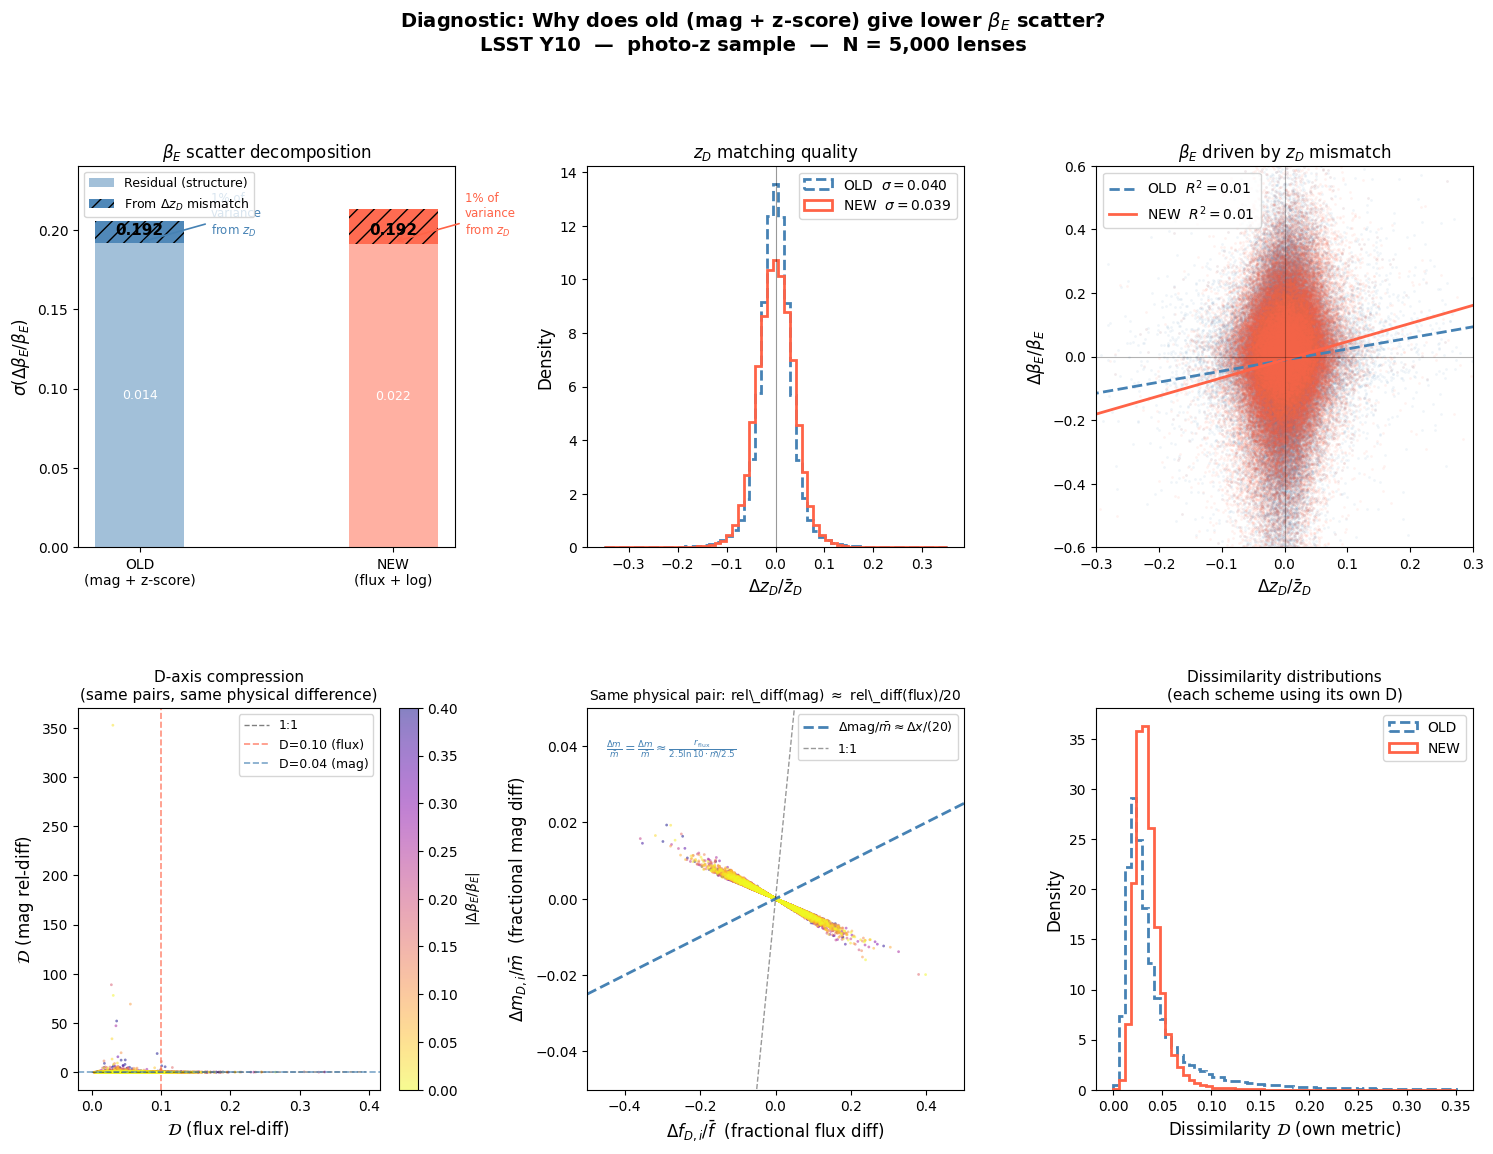


                               SUMMARY                                
Quantity                                 OLD (mag+zscore) NEW (flux+log)
----------------------------------------------------------------------
  σ(Δβ_E/β_E)  [total]                           0.1920         0.1923
  σ(Δz_D/z̄)  [z_D match quality]                0.0400         0.0393
  σ(β_E) attributed to Δz_D                      0.0139         0.0224
  σ(β_E) residual (structure)                    0.1915         0.1910
  % of β_E variance from Δz_D                    0.5245         1.3588
  r(Δβ_E, Δz_D)                                  0.0724         0.1166
  R²(β_E ~ Δz_D)                                 0.0052         0.0136
  Mean D (flux metric)                           0.0514         0.0357
  Mean D (mag metric)                            0.0586         0.0686
  D compression: mean(D_mag)/mean(D_flux)         1.1413         1.9226


In [9]:
# ==============================================================================
# DIAGNOSTIC CELL: Why does old (mag+zscore) give lower β_E scatter?
# Self-contained. N_TEST=5000 runs in ~15s. Safe to increase to 10000.
#
# Key hypotheses tested:
#   H1: Old z-score accidentally over-weighted z_D → tighter z_D matching
#   H2: z_D mismatch is the dominant driver of β_E scatter for LSST (photo-z)
#   H3: Old D values were artificially compressed by rel_diff(mag) normalization
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import pearsonr, linregress
from scipy import spatial
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from pdspl_utils.pairing import (
    normalize_data,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
)

# ==============================================================================
# 0. CONFIG
# ==============================================================================
N_TEST = 5000
cosmo  = FlatLambdaCDM(H0=70, Om0=0.3)
np.random.seed(42)

CATALOG_PATH = "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"

# ==============================================================================
# 1. LOCAL KD-TREE WITH LOG-METRIC SUPPORT
# ==============================================================================
def get_kdtree_pairs(table, pairing_keys, norm_type='zscore', n_neighbors=2,
                     unique_pairs=True, use_log_metric=False):
    if use_log_metric:
        points = np.stack(
            [np.log(np.array(table[pk], dtype=float)) for pk in pairing_keys], axis=1)
    else:
        points = np.stack(
            [normalize_data(table[pk], type=norm_type) for pk in pairing_keys], axis=1)
    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=n_neighbors)
    if n_neighbors < 2:
        return np.empty((0, 2), dtype=int), np.empty(0)
    n_points         = len(points)
    base_indices     = np.repeat(np.arange(n_points), n_neighbors - 1)
    neighbor_indices = indices[:, 1:].flatten()
    flat_distances   = distances[:, 1:].flatten()
    pair_indices     = np.column_stack((base_indices, neighbor_indices))
    if unique_pairs:
        pair_indices = np.sort(pair_indices, axis=1)
        pair_indices, ui = np.unique(pair_indices, axis=0, return_index=True)
        flat_distances = flat_distances[ui]
    return pair_indices, flat_distances

# ==============================================================================
# 2. LOAD + PREPROCESS
# ==============================================================================
def preprocess_ggl_table(filepath):
    table = Table.read(filepath, format='fits')
    table['flux_D_g']        = 10**(-0.4 * table['mag_D_g'])
    table['flux_D_r']        = 10**(-0.4 * table['mag_D_r'])
    table['flux_D_i']        = 10**(-0.4 * table['mag_D_i'])
    table['flux_ratio_D_gr'] = table['flux_D_g'] / table['flux_D_r']
    table['flux_ratio_D_ri'] = table['flux_D_r'] / table['flux_D_i']
    table['color_D_gr']      = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri']      = table['mag_D_r'] - table['mag_D_i']
    table['log_R_e_kpc']     = np.log10(table['R_e_kpc'])
    table['log_sigma_v_D']   = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

print("Loading catalog...")
raw        = preprocess_ggl_table(CATALOG_PATH)
test_table = raw#[:N_TEST]
print(f"Using {len(test_table)} lenses\n")

# ==============================================================================
# 3. ERROR INJECTION — inject in flux space, propagate to mag/color
# This gives both schemes consistently noisy features from the same source.
# ==============================================================================
error_config = {
    'R_e_arcsec':      lambda t: 0.05  * t['R_e_arcsec'],
    'flux_D_i':        lambda t: 0.01  * t['flux_D_i'],
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'],
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri'],
    'z_D':             lambda t: 0.03  * (1 + t['z_D']),
}
table_err = inject_observational_errors(test_table, error_config)

# Propagate noisy fluxes → mag/color so old scheme sees consistent noise
table_err['mag_D_i']    = -2.5 * np.log10(np.abs(table_err['flux_D_i']))
table_err['color_D_gr'] = -2.5 * np.log10(np.abs(table_err['flux_ratio_D_gr']))
table_err['color_D_ri'] = -2.5 * np.log10(np.abs(table_err['flux_ratio_D_ri']))

# ==============================================================================
# 4. SCHEME DEFINITIONS
# ==============================================================================
schemes = {
    'OLD (mag + z-score)': {
        'pairing_keys':  ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        'dissim_keys':   ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_mag_D_i',
                          'rel_diff_color_D_gr', 'rel_diff_color_D_ri'],
        'kdtree_kwargs': {'norm_type': 'zscore', 'use_log_metric': False},
        'color': 'steelblue', 'ls': '--',
    },
    'NEW (flux + log)': {
        'pairing_keys':  ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri'],
        'dissim_keys':   ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i',
                          'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri'],
        'kdtree_kwargs': {'use_log_metric': True},
        'color': 'tomato', 'ls': '-',
    },
}

# ==============================================================================
# 5. RUN PAIRINGS + COMPUTE STATISTICS
# ==============================================================================
results = {}
print(f"{'='*65}")
for name, s in schemes.items():
    idx    = get_kdtree_pairs(table_err, s['pairing_keys'], **s['kdtree_kwargs'])[0]
    pt     = get_pairs_table_PDSPL(test_table, idx, cosmo)
    pt_err = get_pairs_table_PDSPL(table_err,  idx, cosmo)
    pt_err['dissimilarity'] = compute_dissimilarity(pt_err, s['dissim_keys'], method='rms')

    # Also compute BOTH flux-D and mag-D on the same pairs for the compression diagnostic
    D_flux_keys = ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i',
                   'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri']
    D_mag_keys  = ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_mag_D_i',
                   'rel_diff_color_D_gr', 'rel_diff_color_D_ri']
    D_flux = compute_dissimilarity(pt_err, D_flux_keys, method='rms')
    D_mag  = compute_dissimilarity(pt_err, D_mag_keys,  method='rms')

    beta  = np.array(pt['rel_diff_beta_E'])
    v1_zD = np.array(pt_err['z_D_1'])
    v2_zD = np.array(pt_err['z_D_2'])
    dz    = 2 * (v2_zD - v1_zD) / (v2_zD + v1_zD)

    mask  = np.isfinite(beta) & np.isfinite(dz)
    r_bz, _ = pearsonr(dz[mask], beta[mask])
    slope, intercept, r_val, _, _ = linregress(dz[mask], beta[mask])
    R2_zD = r_val**2

    sigma_beta     = np.nanstd(beta[mask])
    sigma_dz       = np.nanstd(dz[mask])
    sigma_from_zD  = np.abs(slope) * sigma_dz
    sigma_residual = np.sqrt(max(sigma_beta**2 - sigma_from_zD**2, 0))

    results[name] = {
        'pt': pt, 'pt_err': pt_err, 'idx': idx,
        'beta': beta, 'dz': dz, 'mask': mask,
        'D_flux': D_flux, 'D_mag': D_mag,
        'sigma_beta':    sigma_beta,
        'sigma_dz':      sigma_dz,
        'sigma_from_zD': sigma_from_zD,
        'sigma_residual':sigma_residual,
        'slope': slope, 'intercept': intercept,
        'R2_zD': R2_zD, 'r_bz': r_bz,
        's': s,
    }
    print(f"\n{name}")
    print(f"  # pairs                      : {len(idx)}")
    print(f"  σ(Δβ_E/β_E)                 : {sigma_beta:.4f}")
    print(f"  σ(Δz_D/z̄)                   : {sigma_dz:.4f}")
    print(f"  r(Δβ_E, Δz_D)               : {r_bz:.3f}   [R² = {R2_zD:.3f}]")
    print(f"  σ(β_E) from Δz_D            : {sigma_from_zD:.4f}  ({100*sigma_from_zD**2/sigma_beta**2:.1f}% of variance)")
    print(f"  σ(β_E) residual              : {sigma_residual:.4f}")
    print(f"  mean D (flux)               : {np.nanmean(D_flux):.4f}")
    print(f"  mean D (mag)                : {np.nanmean(D_mag):.4f}")
    print(f"  D compression ratio (mag/flux): {np.nanmean(D_mag)/np.nanmean(D_flux):.3f}")

print(f"\n{'='*65}")

# ==============================================================================
# 6. VISUALIZATION
# ==============================================================================
names   = list(results.keys())
r_old   = results[names[0]]
r_new   = results[names[1]]

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Diagnostic: Why does old (mag + z-score) give lower $\\beta_E$ scatter?\n'
    'LSST Y10  —  photo-z sample  —  N = {:,} lenses'.format(N_TEST),
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── Panel 1: Variance decomposition bar chart ────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
labels = ['OLD\n(mag + z-score)', 'NEW\n(flux + log)']
colors_bar = ['steelblue', 'tomato']
sigma_total  = [r_old['sigma_beta'],    r_new['sigma_beta']]
sigma_zD_cmp = [r_old['sigma_from_zD'], r_new['sigma_from_zD']]
sigma_res    = [r_old['sigma_residual'],r_new['sigma_residual']]

x = np.arange(len(labels))
w = 0.35
bars_res = ax1.bar(x, sigma_res,    w, color=colors_bar, alpha=0.5, label='Residual (structure)')
bars_zD  = ax1.bar(x, sigma_zD_cmp, w, bottom=sigma_res, color=colors_bar, alpha=0.95,
                   label=r'From $\Delta z_D$ mismatch', hatch='//')
for i, (st, sz, sr) in enumerate(zip(sigma_total, sigma_zD_cmp, sigma_res)):
    ax1.text(x[i], st + 0.003, f'{st:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax1.text(x[i], sr/2, f'{sz:.3f}', ha='center', va='center', fontsize=9,
             color='white' if i == 0 else 'white')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylabel(r'$\sigma(\Delta\beta_E/\beta_E)$', fontsize=12)
ax1.set_title(r'$\beta_E$ scatter decomposition', fontsize=12)
ax1.legend(fontsize=9, frameon=True)
ax1.set_ylim(0, max(sigma_total)*1.25)
ax1.tick_params(labelsize=10)

# Annotate % from z_D
for i, (st, sz) in enumerate(zip(sigma_total, sigma_zD_cmp)):
    pct = 100 * sz**2 / st**2
    ax1.annotate(f'{pct:.0f}% of\nvariance\nfrom $z_D$',
                 xy=(x[i], st), xytext=(x[i] + 0.28, st + 0.005),
                 fontsize=8.5, color=colors_bar[i],
                 arrowprops=dict(arrowstyle='->', color=colors_bar[i], lw=1.2))

# ── Panel 2: σ(Δz_D) comparison ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bins_z = np.linspace(-0.35, 0.35, 60)
for name, res in results.items():
    s   = res['s']
    dz  = res['dz'][res['mask']]
    ax2.hist(dz, bins=bins_z, density=True, histtype='step',
             color=s['color'], lw=2.0, ls=s['ls'],
             label=fr"{name.split('(')[0].strip()}  $\sigma={res['sigma_dz']:.3f}$")
ax2.axvline(0, color='k', lw=0.8, alpha=0.4)
ax2.set_xlabel(r'$\Delta z_D / \bar{z}_D$', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(r'$z_D$ matching quality', fontsize=12)
ax2.legend(fontsize=10, frameon=True)
ax2.tick_params(labelsize=10)

# ── Panel 3: Δβ_E vs Δz_D scatter with regression ───────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, res in results.items():
    s    = res['s']
    mask = res['mask']
    dz   = res['dz'][mask]
    beta = res['beta'][mask]
    ax3.scatter(dz, beta, color=s['color'], alpha=0.08, s=4,
                linewidths=0, rasterized=True)
    xfit = np.linspace(dz.min(), dz.max(), 100)
    yfit = res['slope'] * xfit + res['intercept']
    ax3.plot(xfit, yfit, color=s['color'], lw=2.0, ls=s['ls'],
             label=fr"{name.split('(')[0].strip()}  $R^2={res['R2_zD']:.2f}$")
ax3.axhline(0, color='k', lw=0.8, alpha=0.3)
ax3.axvline(0, color='k', lw=0.8, alpha=0.3)
ax3.set_xlabel(r'$\Delta z_D / \bar{z}_D$', fontsize=12)
ax3.set_ylabel(r'$\Delta\beta_E / \beta_E$', fontsize=12)
ax3.set_title(r'$\beta_E$ driven by $z_D$ mismatch', fontsize=12)
ax3.legend(fontsize=10, frameon=True)
ax3.tick_params(labelsize=10)
ax3.set_xlim(-0.3, 0.3)
ax3.set_ylim(-0.6, 0.6)

# ── Panel 4: D-axis compression — D_mag vs D_flux for same pairs ─────────────
ax4 = fig.add_subplot(gs[1, 0])
D_flux = r_new['D_flux']
D_mag  = r_new['D_mag']
beta_c = np.abs(r_new['beta'])
order  = np.argsort(beta_c)[::-1]
sc = ax4.scatter(D_flux[order], D_mag[order], c=beta_c[order],
                 cmap='plasma_r', vmin=0, vmax=0.4,
                 s=4, alpha=0.5, linewidths=0, rasterized=True)
plt.colorbar(sc, ax=ax4, label=r'$|\Delta\beta_E/\beta_E|$')
plo = 0; phi = max(np.nanpercentile(D_flux, 99), np.nanpercentile(D_mag, 99))
ax4.plot([plo, phi], [plo, phi], 'k--', lw=1.0, alpha=0.5, label='1:1')
ax4.axvline(0.10, color='tomato',    lw=1.2, ls='--', alpha=0.7, label='D=0.10 (flux)')
ax4.axhline(0.04, color='steelblue', lw=1.2, ls='--', alpha=0.7, label='D=0.04 (mag)')
ax4.set_xlabel(r'$\mathcal{D}$ (flux rel-diff)',  fontsize=12)
ax4.set_ylabel(r'$\mathcal{D}$ (mag rel-diff)', fontsize=12)
ax4.set_title('D-axis compression\n(same pairs, same physical difference)', fontsize=11)
ax4.legend(fontsize=9, frameon=True)
ax4.tick_params(labelsize=10)

# ── Panel 5: rel_diff(mag_i) vs rel_diff(flux_i) for same pairs ──────────────
ax5 = fig.add_subplot(gs[1, 1])
pt_err_new = r_new['pt_err']
rd_flux = np.array(pt_err_new['rel_diff_flux_D_i'])
rd_mag  = np.array(pt_err_new['rel_diff_mag_D_i'])
finite  = np.isfinite(rd_flux) & np.isfinite(rd_mag)
order2  = np.argsort(np.abs(r_new['beta']))[::-1]
order2  = order2[np.isin(order2, np.where(finite)[0])]

ax5.scatter(rd_flux[order2], rd_mag[order2],
            c=np.abs(r_new['beta'][order2]),
            cmap='plasma_r', vmin=0, vmax=0.4,
            s=4, alpha=0.5, linewidths=0, rasterized=True)
xr = np.linspace(-0.5, 0.5, 200)
ax5.plot(xr, xr / 20.0, 'steelblue', lw=2, ls='--',
         label=r'$\Delta\mathrm{mag}/\bar{m}\approx\Delta x/(20)$')
ax5.plot(xr, xr, 'k--', lw=1.0, alpha=0.4, label='1:1')
ax5.set_xlabel(r'$\Delta f_{D,i} / \bar{f}$  (fractional flux diff)', fontsize=12)
ax5.set_ylabel(r'$\Delta m_{D,i} / \bar{m}$  (fractional mag diff)', fontsize=12)
ax5.set_title(r'Same physical pair: rel\_diff(mag) $\approx$ rel\_diff(flux)/20', fontsize=10)
ax5.set_xlim(-0.5, 0.5)
ax5.set_ylim(-0.05, 0.05)
ax5.legend(fontsize=9, frameon=True)
ax5.tick_params(labelsize=10)
ax5.text(0.05, 0.92,
         r'$\frac{\Delta m}{\bar{m}} = \frac{\Delta m}{\bar{m}} \approx \frac{r_{\rm flux}}{2.5\ln10\cdot\bar{m}/2.5}$',
         transform=ax5.transAxes, fontsize=9,
         color='steelblue', va='top')

# ── Panel 6: Summary — β_E vs D for both schemes ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
bins_d = np.linspace(0, 0.35, 60)
for name, res in results.items():
    s      = res['s']
    dissim = np.array(res['pt_err']['dissimilarity'])
    ax6.hist(dissim[np.isfinite(dissim)], bins=bins_d, density=True,
             histtype='step', color=s['color'], lw=2.0, ls=s['ls'],
             label=fr"{name.split('(')[0].strip()}")
ax6.set_xlabel(r'Dissimilarity $\mathcal{D}$ (own metric)', fontsize=12)
ax6.set_ylabel('Density', fontsize=12)
ax6.set_title('Dissimilarity distributions\n(each scheme using its own D)', fontsize=11)
ax6.legend(fontsize=10, frameon=True)
ax6.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

# ==============================================================================
# 7. CLEAN SUMMARY TABLE
# ==============================================================================
print(f"\n{'='*70}")
print(f"{'SUMMARY':^70}")
print(f"{'='*70}")
print(f"{'Quantity':<40} {'OLD (mag+zscore)':>14} {'NEW (flux+log)':>14}")
print(f"{'-'*70}")
rows = [
    ('σ(Δβ_E/β_E)  [total]',
     r_old['sigma_beta'],     r_new['sigma_beta']),
    ('σ(Δz_D/z̄)  [z_D match quality]',
     r_old['sigma_dz'],       r_new['sigma_dz']),
    ('σ(β_E) attributed to Δz_D',
     r_old['sigma_from_zD'],  r_new['sigma_from_zD']),
    ('σ(β_E) residual (structure)',
     r_old['sigma_residual'], r_new['sigma_residual']),
    ('% of β_E variance from Δz_D',
     100*r_old['sigma_from_zD']**2/r_old['sigma_beta']**2,
     100*r_new['sigma_from_zD']**2/r_new['sigma_beta']**2),
    ('r(Δβ_E, Δz_D)',
     r_old['r_bz'],           r_new['r_bz']),
    ('R²(β_E ~ Δz_D)',
     r_old['R2_zD'],          r_new['R2_zD']),
    ('Mean D (flux metric)',
     np.nanmean(r_old['D_flux']), np.nanmean(r_new['D_flux'])),
    ('Mean D (mag metric)',
     np.nanmean(r_old['D_mag']),  np.nanmean(r_new['D_mag'])),
    ('D compression: mean(D_mag)/mean(D_flux)',
     np.nanmean(r_old['D_mag'])/np.nanmean(r_old['D_flux']),
     np.nanmean(r_new['D_mag'])/np.nanmean(r_new['D_flux'])),
]
for label, v_old, v_new in rows:
    print(f"  {label:<38} {v_old:>14.4f} {v_new:>14.4f}")
print(f"{'='*70}")

## Comparing Pairing techniques

In [20]:
# ==============================================================================
# CELL 1: SETUP + THREE-SCHEME MC LOOP (Self-contained)
# Produces `scheme_results`, `mc_results`, `last_pairs` used by Cells 2 and 3
#
# Three schemes:
#   OLD    : magnitudes + colors + z-score KD-Tree (matches paper v1)
#   NEW    : fluxes + flux ratios + log KD-Tree (corrected)
#   WITH PL SLOPE : NEW + γ_pl (σ=0.10, literature-level) — upper bound on structure info
#
# Errors injected on physical (flux) quantities, then propagated to
# mag/color for OLD so all schemes see identical underlying noise.
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import spatial
from scipy.optimize import curve_fit
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
from pdspl_utils.pairing import (
    normalize_data,
    get_pairs_table_PDSPL,
    inject_observational_errors,
    compute_dissimilarity,
)

# -------------------------------------------------------
# 0. Config
# -------------------------------------------------------
N_TEST          = None   # None = full 116k catalog (~10 min); 30k ~ 2 min
N_realizations  = 50      # 20 for testing, 100 for paper
MAX_D           = 0.15
cosmo           = FlatLambdaCDM(H0=70, Om0=0.3)
CATALOG_PATH    = "../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits"
np.random.seed(42)

# -------------------------------------------------------
# 1. KD-Tree with log-metric support
# -------------------------------------------------------
def get_kdtree_pairs(table, pairing_keys, norm_type='zscore', n_neighbors=2,
                     unique_pairs=True, use_log_metric=False):
    if use_log_metric:
        points = np.stack(
            [np.log(np.array(table[pk], dtype=float)) for pk in pairing_keys], axis=1)
        if not np.all(np.isfinite(points)):
            raise ValueError("use_log_metric=True: all features must be strictly positive.")
    else:
        points = np.stack(
            [normalize_data(table[pk], type=norm_type) for pk in pairing_keys], axis=1)
    tree = spatial.KDTree(points)
    distances, indices = tree.query(points, k=n_neighbors)
    if n_neighbors < 2:
        return np.empty((0, 2), dtype=int), np.empty(0)
    n_points         = len(points)
    base_indices     = np.repeat(np.arange(n_points), n_neighbors - 1)
    neighbor_indices = indices[:, 1:].flatten()
    flat_distances   = distances[:, 1:].flatten()
    pair_indices     = np.column_stack((base_indices, neighbor_indices))
    if unique_pairs:
        pair_indices = np.sort(pair_indices, axis=1)
        pair_indices, ui = np.unique(pair_indices, axis=0, return_index=True)
        flat_distances = flat_distances[ui]
    return pair_indices, flat_distances

# -------------------------------------------------------
# 2. Load + preprocess
# -------------------------------------------------------
def preprocess_ggl_table(filepath):
    t = Table.read(filepath, format='fits')
    t['flux_D_g']        = 10**(-0.4 * t['mag_D_g'])
    t['flux_D_r']        = 10**(-0.4 * t['mag_D_r'])
    t['flux_D_i']        = 10**(-0.4 * t['mag_D_i'])
    t['flux_ratio_D_gr'] = t['flux_D_g'] / t['flux_D_r']
    t['flux_ratio_D_ri'] = t['flux_D_r'] / t['flux_D_i']
    t['color_D_gr']      = t['mag_D_g'] - t['mag_D_r']
    t['color_D_ri']      = t['mag_D_r'] - t['mag_D_i']
    t['log_R_e_kpc']     = np.log10(t['R_e_kpc'])
    t['log_sigma_v_D']   = np.log10(t['sigma_v_D'])
    t.rename_column('size_D', 'R_e_arcsec')
    return t

print("Loading catalog...")
raw        = preprocess_ggl_table(CATALOG_PATH)
test_table = raw if N_TEST is None else raw[:N_TEST]
print(f"Using {len(test_table):,} lenses\n")

# -------------------------------------------------------
# 3. Scheme definitions
# -------------------------------------------------------
# Base noise (injected on physical flux quantities — same for all schemes)
base_error_config = {
    'R_e_arcsec':      lambda t: 0.05  * t['R_e_arcsec'],
    'flux_D_i':        lambda t: 0.01  * t['flux_D_i'],
    'flux_ratio_D_gr': lambda t: 0.014 * t['flux_ratio_D_gr'],
    'flux_ratio_D_ri': lambda t: 0.014 * t['flux_ratio_D_ri'],
    'z_D':             lambda t: 0.03  * (1 + t['z_D']),
}

schemes = {
    'OLD\n(mag + zscore)': {
        'pairing_keys':  ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri'],
        'dissim_keys':   ['rel_diff_z_D', 'rel_diff_R_e_arcsec',
                          'rel_diff_mag_D_i', 'rel_diff_color_D_gr', 'rel_diff_color_D_ri'],
        'kdtree_kwargs': {'norm_type': 'zscore', 'use_log_metric': False},
        'extra_error':   {},          # mag/color propagated from flux noise below
        'color': 'steelblue', 'ls': '--', 'marker': 's', 'alpha_sc': 0.012,
        'label': 'OLD (mag + zscore)',
    },
    'NEW\n(flux + log)': {
        'pairing_keys':  ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri'],
        'dissim_keys':   ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i',
                          'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri'],
        'kdtree_kwargs': {'use_log_metric': True},
        'extra_error':   {},
        'color': 'tomato', 'ls': '-', 'marker': 'o', 'alpha_sc': 0.012,
        'label': 'NEW (flux + log)',
    },
    'ORACLE\n(flux + γ_pl + log)': {
        'pairing_keys':  ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr',
                          'flux_ratio_D_ri', 'gamma_pl'],
        'dissim_keys':   ['rel_diff_z_D', 'rel_diff_R_e_arcsec', 'rel_diff_flux_D_i',
                          'rel_diff_flux_ratio_D_gr', 'rel_diff_flux_ratio_D_ri',
                          'rel_diff_gamma_pl'],
        'kdtree_kwargs': {'use_log_metric': True},
        'extra_error':   {'gamma_pl': 0.10},   # σ(γ_pl)=0.10 — literature kinematics
        'color': 'forestgreen', 'ls': '-.', 'marker': 'D', 'alpha_sc': 0.012,
        'label': 'ORACLE (flux + γ_pl + log)',
    },
}

# -------------------------------------------------------
# 4. MC loop
# -------------------------------------------------------
mc_results = {
    k: {'binned_dissim':    [],
        'binned_scatter':   [],   # σ(Δβ_E) per D bin
        'binned_scatter_zD':[],   # σ(Δz_D)  per D bin — trend decomposition
        'binned_frac_zD':   [],   # fraction of D² from z_D per bin
        'num_pairs':        [],
        'scatter_in_beta_E': []}
    for k in schemes
}
last_pairs = {}   # stores final realization for visualization

print(f"Running {N_realizations} MC × {len(schemes)} schemes...\n")

for i_real in tqdm(range(N_realizations), desc="MC Realizations"):
    # Inject base flux noise
    table_err = inject_observational_errors(test_table, base_error_config)
    # Propagate noisy fluxes → mag/color so OLD scheme sees consistent noise
    table_err['mag_D_i']    = -2.5 * np.log10(np.abs(table_err['flux_D_i']))
    table_err['color_D_gr'] = -2.5 * np.log10(np.abs(table_err['flux_ratio_D_gr']))
    table_err['color_D_ri'] = -2.5 * np.log10(np.abs(table_err['flux_ratio_D_ri']))

    for sk, s in schemes.items():
        # Add scheme-specific extra errors (γ_pl for oracle)
        if s['extra_error']:
            te_s = inject_observational_errors(table_err, s['extra_error'])
        else:
            te_s = table_err

        idx, _ = get_kdtree_pairs(te_s, s['pairing_keys'], **s['kdtree_kwargs'])

        pt     = get_pairs_table_PDSPL(test_table, idx, cosmo)   # noiseless (science)
        pt_err = get_pairs_table_PDSPL(te_s,       idx, cosmo)   # noisy (pairing)
        pt_err['dissimilarity'] = compute_dissimilarity(pt_err, s['dissim_keys'], method='rms')

        beta   = np.array(pt['rel_diff_beta_E'])
        dissim = np.array(pt_err['dissimilarity'])

        # Per-pair z_D relative difference
        z1  = np.array(pt_err['z_D_1']); z2 = np.array(pt_err['z_D_2'])
        dz  = 2 * (z2 - z1) / (z2 + z1)

        # Per-pair fraction of D² from z_D
        rk_sq   = np.array([np.array(pt_err[k])**2 for k in s['dissim_keys']])  # (N_feat, N_pairs)
        D_sq_nf = np.sum(rk_sq, axis=0)   # = N_feat * D^2
        zD_idx  = s['dissim_keys'].index('rel_diff_z_D')
        frac_zD = np.where(D_sq_nf > 0, rk_sq[zD_idx] / D_sq_nf, np.nan)

        mc_results[sk]['num_pairs'].append(len(pt))
        mc_results[sk]['scatter_in_beta_E'].append(np.nanstd(beta))

        # Bin statistics
        mask = (dissim < MAX_D) & np.isfinite(beta)
        dm = dissim[mask]; bm = beta[mask]; dzm = dz[mask]; fm = frac_zD[mask]

        pct = np.percentile(dm, np.arange(0, 101, 10))
        dig = np.digitize(dm, pct)

        run_d, run_b, run_dz, run_fzD = [], [], [], []
        for i in range(1, len(pct)):
            bm_bin = (dig == i)
            run_d.append(  np.median(dm[bm_bin])   if bm_bin.any() else np.nan)
            run_b.append(  np.nanstd(bm[bm_bin])   if bm_bin.any() else np.nan)
            run_dz.append( np.nanstd(dzm[bm_bin])  if bm_bin.any() else np.nan)
            run_fzD.append(np.nanmean(fm[bm_bin])  if bm_bin.any() else np.nan)

        mc_results[sk]['binned_dissim'].append(run_d)
        mc_results[sk]['binned_scatter'].append(run_b)
        mc_results[sk]['binned_scatter_zD'].append(run_dz)
        mc_results[sk]['binned_frac_zD'].append(run_fzD)

        if i_real == N_realizations - 1:
            last_pairs[sk] = {
                'pt': pt, 'pt_err': pt_err,
                'beta': beta, 'dissim': dissim, 'dz': dz, 'frac_zD': frac_zD,
            }

# -------------------------------------------------------
# 5. Summary
# -------------------------------------------------------
print("\n" + "="*65)
print(f"{'Scheme':<35} {'Mean # Pairs':>12} {'Mean σ(β_E)':>12}")
print("-"*65)
for sk, r in mc_results.items():
    label = sk.replace('\n', ' ')

Loading catalog...
Using 116,471 lenses

Running 50 MC × 3 schemes...



MC Realizations: 100%|██████████| 50/50 [02:31<00:00,  3.03s/it]


Scheme                              Mean # Pairs  Mean σ(β_E)
-----------------------------------------------------------------


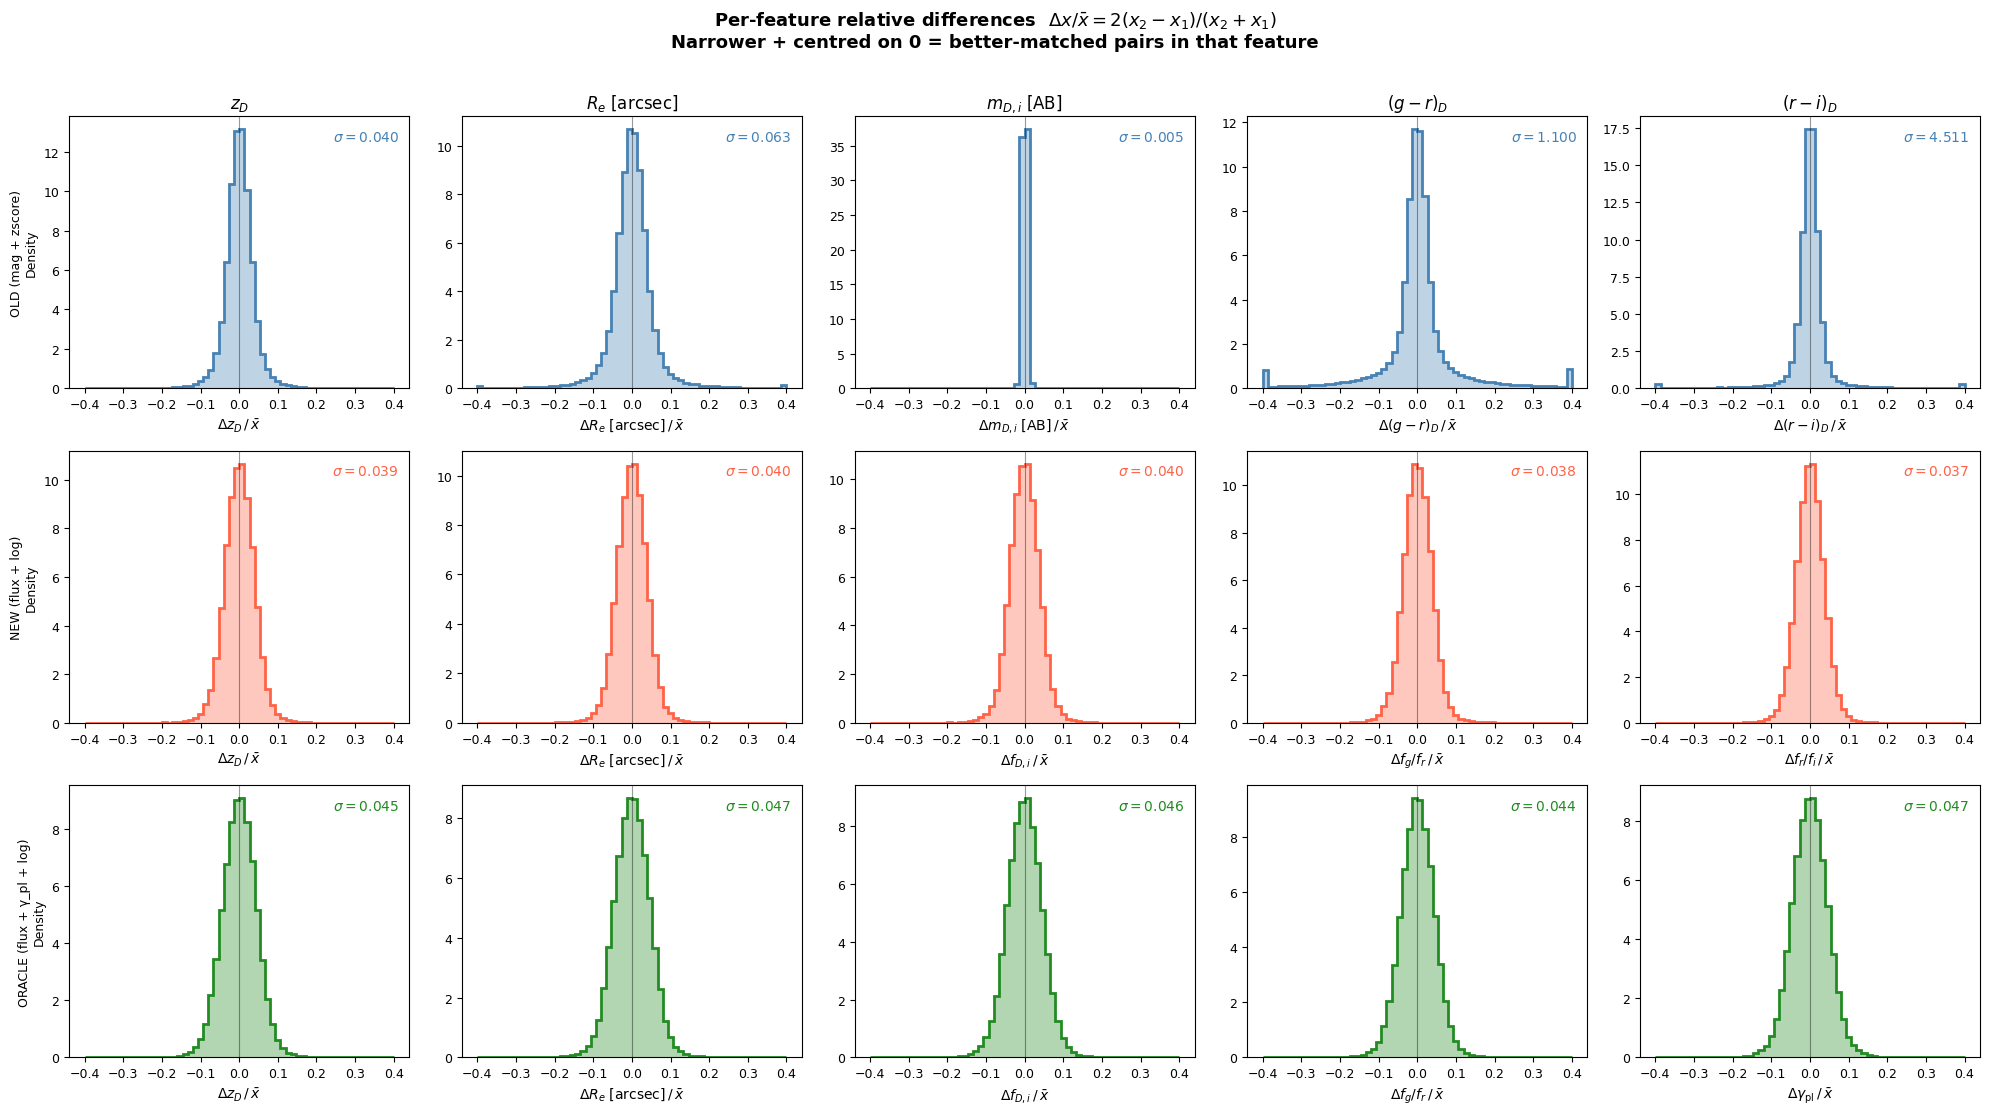

/tmp/ipykernel_121444/3564866581.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig_b.tight_layout()


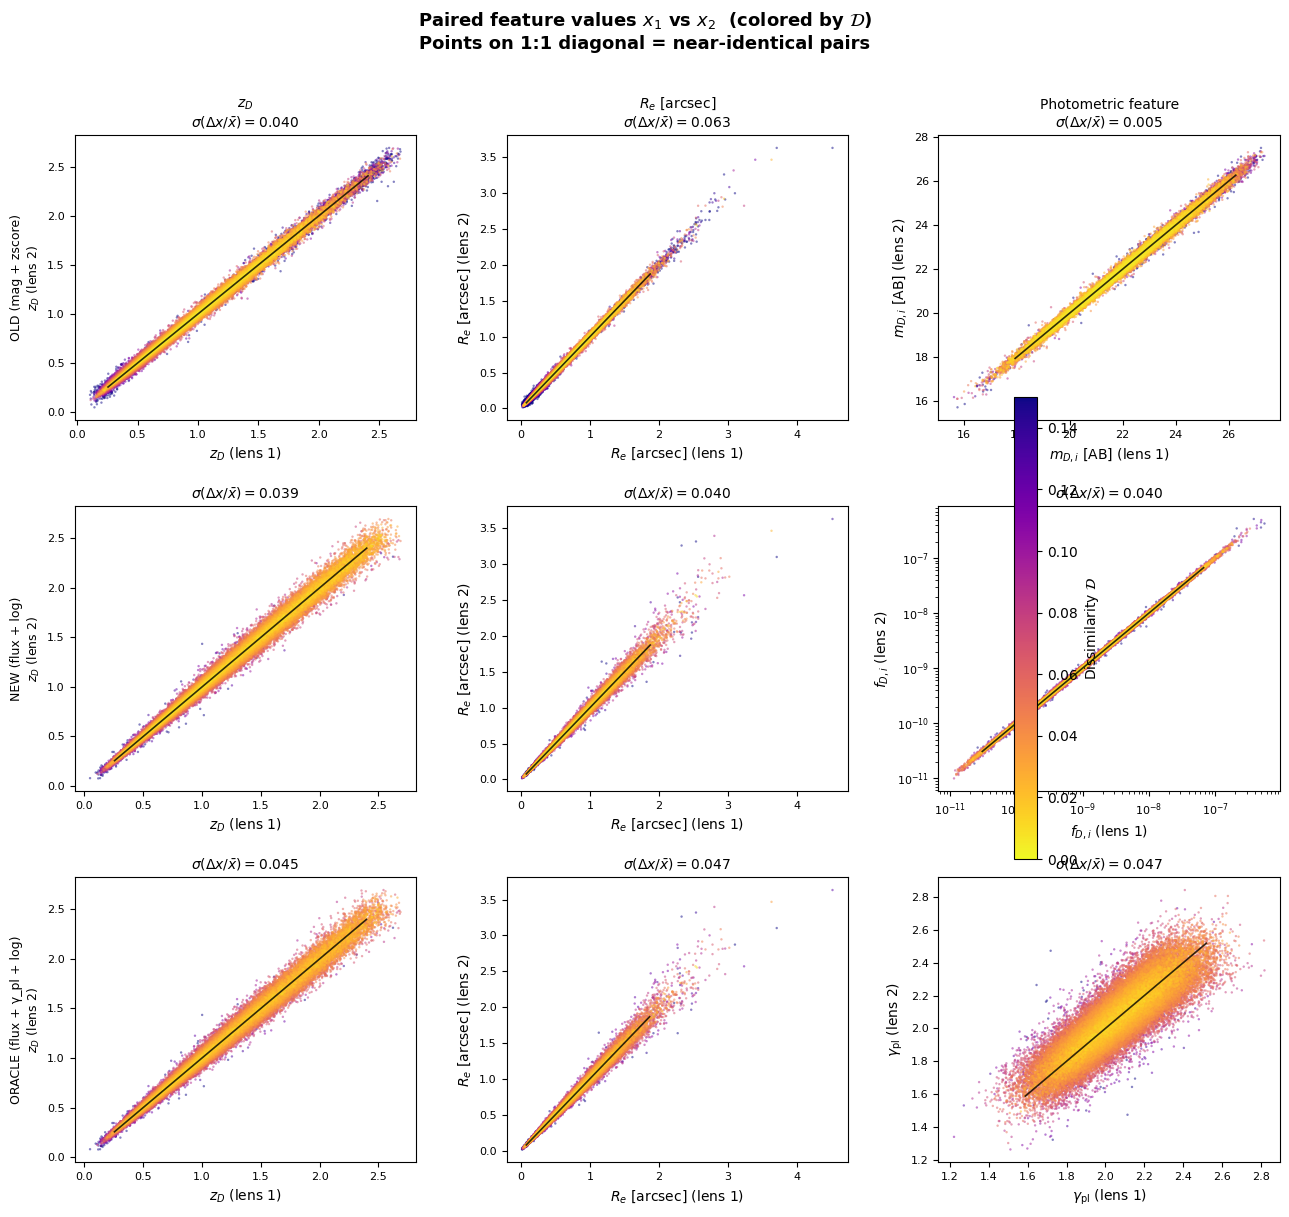

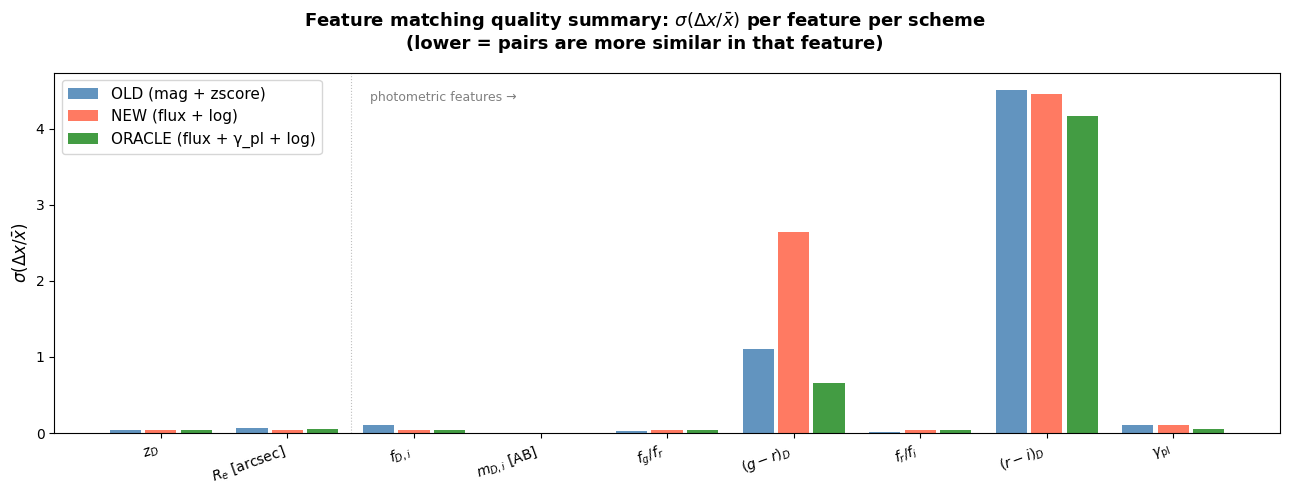

In [21]:
# ==============================================================================
# CELL 2: FEATURE COMPARISON — Pairing quality across three schemes
# Requires: schemes, last_pairs, MAX_D (from Cell 1)
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

FEATURE_LABELS = {
    'z_D':             r'$z_D$',
    'R_e_arcsec':      r'$R_e$ [arcsec]',
    'flux_D_i':        r'$f_{D,i}$',
    'flux_ratio_D_gr': r'$f_g/f_r$',
    'flux_ratio_D_ri': r'$f_r/f_i$',
    'mag_D_i':         r'$m_{D,i}$ [AB]',
    'color_D_gr':      r'$(g-r)_D$',
    'color_D_ri':      r'$(r-i)_D$',
    'gamma_pl':        r'$\gamma_{\rm pl}$',
}
LOG_SCALE_FEATS = {'flux_D_i'}
CLIP = 0.4

norm_d = mcolors.Normalize(vmin=0, vmax=MAX_D)
cmap_d = plt.cm.plasma_r

def get_reldiff_clean(pt_err, pk):
    v1 = np.array(pt_err[f'{pk}_1'], dtype=float)
    v2 = np.array(pt_err[f'{pk}_2'], dtype=float)
    rd = 2 * (v2 - v1) / (v2 + v1)
    return rd[np.isfinite(rd)]

scheme_keys = list(schemes.keys())

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE A: rel_diff distributions — 3 rows (schemes) × 5 cols (features)
# Each scheme shows its own pairing features. Common features (z_D, R_e) shown
# for all; photometric features shown for the scheme that uses them.
# ─────────────────────────────────────────────────────────────────────────────
col_features = {
    'OLD\n(mag + zscore)':        ['z_D', 'R_e_arcsec', 'mag_D_i',  'color_D_gr',      'color_D_ri'],
    'NEW\n(flux + log)':          ['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'flux_ratio_D_ri'],
    'ORACLE\n(flux + γ_pl + log)':['z_D', 'R_e_arcsec', 'flux_D_i', 'flux_ratio_D_gr', 'gamma_pl'],
}

fig_a, axes_a = plt.subplots(3, 5, figsize=(20, 11), squeeze=False)
fig_a.suptitle(
    r'Per-feature relative differences  $\Delta x/\bar{x} = 2(x_2-x_1)/(x_2+x_1)$'
    '\nNarrower + centred on 0 = better-matched pairs in that feature',
    fontsize=13, fontweight='bold', y=1.01
)

for row, sk in enumerate(scheme_keys):
    s     = schemes[sk]
    feats = col_features[sk]
    pt_err = last_pairs[sk]['pt_err']

    for col, pk in enumerate(feats):
        ax    = axes_a[row, col]
        label = FEATURE_LABELS.get(pk, pk)

        if f'{pk}_1' not in pt_err.colnames:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center',
                    fontsize=12, color='gray')
            ax.axis('off')
            continue

        rd    = get_reldiff_clean(pt_err, pk)
        sigma = np.nanstd(rd)
        ax.hist(np.clip(rd, -CLIP, CLIP), bins=60, range=(-CLIP, CLIP),
                density=True, histtype='stepfilled', color=s['color'],
                alpha=0.35, linewidth=0)
        ax.hist(np.clip(rd, -CLIP, CLIP), bins=60, range=(-CLIP, CLIP),
                density=True, histtype='step', color=s['color'], lw=2.0)
        ax.axvline(0, color='k', lw=0.8, alpha=0.4)

        if row == 0:
            ax.set_title(label, fontsize=12)
        ax.text(0.97, 0.95, fr'$\sigma={sigma:.3f}$', transform=ax.transAxes,
                ha='right', va='top', fontsize=10, color=s['color'], fontweight='bold')
        ax.set_xlabel(fr'$\Delta${label}$\,/\,\bar{{x}}$', fontsize=10)
        if col == 0:
            scheme_label = sk.replace('\n', ' ')
            ax.set_ylabel(f'{scheme_label}\nDensity', fontsize=9)
        ax.tick_params(labelsize=9)

fig_a.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE B: x_1 vs x_2 scatter — z_D, R_e, and photometric feature per scheme
# ─────────────────────────────────────────────────────────────────────────────
scatter_features = {
    'OLD\n(mag + zscore)':        ('z_D', 'R_e_arcsec', 'mag_D_i'),
    'NEW\n(flux + log)':          ('z_D', 'R_e_arcsec', 'flux_D_i'),
    'ORACLE\n(flux + γ_pl + log)':('z_D', 'R_e_arcsec', 'gamma_pl'),
}

fig_b, axes_b = plt.subplots(3, 3, figsize=(13, 12), squeeze=False)
fig_b.suptitle(
    r'Paired feature values $x_1$ vs $x_2$  (colored by $\mathcal{D}$)'
    '\nPoints on 1:1 diagonal = near-identical pairs',
    fontsize=13, fontweight='bold', y=1.01
)
col_titles = [r'$z_D$', r'$R_e$ [arcsec]', 'Photometric feature']

for row, sk in enumerate(scheme_keys):
    s      = schemes[sk]
    pt_err = last_pairs[sk]['pt_err']
    dissim = np.array(pt_err['dissimilarity'])
    order  = np.argsort(dissim)[::-1]
    feats  = scatter_features[sk]

    for col, pk in enumerate(feats):
        ax    = axes_b[row, col]
        label = FEATURE_LABELS.get(pk, pk)

        if f'{pk}_1' not in pt_err.colnames:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center')
            continue

        v1 = np.array(pt_err[f'{pk}_1'], dtype=float)
        v2 = np.array(pt_err[f'{pk}_2'], dtype=float)
        sc = ax.scatter(v1[order], v2[order], c=dissim[order], cmap=cmap_d, norm=norm_d,
                        s=3, alpha=0.5, linewidths=0, rasterized=True)
        plo = min(np.nanpercentile(v1, 0.5),  np.nanpercentile(v2, 0.5))
        phi = max(np.nanpercentile(v1, 99.5), np.nanpercentile(v2, 99.5))
        ax.plot([plo, phi], [plo, phi], 'k-', lw=1.2, alpha=0.8, zorder=5)

        if pk in LOG_SCALE_FEATS:
            ax.set_xscale('log'); ax.set_yscale('log')

        rms_rd = np.nanstd(get_reldiff_clean(pt_err, pk))
        if row == 0:
            ax.set_title(f'{col_titles[col]}\n' + fr'$\sigma(\Delta x/\bar{{x}})={rms_rd:.3f}$',
                         fontsize=10)
        else:
            ax.set_title(fr'$\sigma(\Delta x/\bar{{x}})={rms_rd:.3f}$', fontsize=10)

        ax.set_xlabel(f'{label} (lens 1)', fontsize=10)
        if col == 0:
            ax.set_ylabel(f"{sk.replace(chr(10), ' ')}\n{label} (lens 2)", fontsize=9)
        else:
            ax.set_ylabel(f'{label} (lens 2)', fontsize=10)
        ax.tick_params(labelsize=8)

fig_b.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d),
               ax=axes_b, shrink=0.5, pad=0.02, label=r'Dissimilarity $\mathcal{D}$')
fig_b.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE C: σ per feature per scheme — grouped bar (slide-ready summary)
# ─────────────────────────────────────────────────────────────────────────────
fig_c, ax_c = plt.subplots(figsize=(13, 5))
fig_c.suptitle(
    r'Feature matching quality summary: $\sigma(\Delta x/\bar{x})$ per feature per scheme'
    '\n(lower = pairs are more similar in that feature)',
    fontsize=13, fontweight='bold'
)

all_feats = ['z_D', 'R_e_arcsec', 'flux_D_i', 'mag_D_i',
             'flux_ratio_D_gr', 'color_D_gr', 'flux_ratio_D_ri', 'color_D_ri', 'gamma_pl']
x = np.arange(len(all_feats))
w = 0.28

for bi, (sk, s) in enumerate(schemes.items()):
    pt_err = last_pairs[sk]['pt_err']
    sigmas = []
    for pk in all_feats:
        if f'{pk}_1' in pt_err.colnames:
            rd = get_reldiff_clean(pt_err, pk)
            sigmas.append(np.nanstd(rd))
        else:
            sigmas.append(np.nan)

    valid  = ~np.isnan(sigmas)
    offset = (bi - 1) * w
    ax_c.bar(x[valid] + offset, np.array(sigmas)[valid], w * 0.88,
             color=s['color'], alpha=0.85,
             label=sk.replace('\n', ' '))

ax_c.set_xticks(x)
ax_c.set_xticklabels([FEATURE_LABELS.get(f, f) for f in all_feats],
                      fontsize=11, rotation=20, ha='right')
ax_c.set_ylabel(r'$\sigma(\Delta x / \bar{x})$', fontsize=12)
ax_c.legend(fontsize=11, frameon=True)
ax_c.tick_params(labelsize=10)
ax_c.axhline(0, color='k', lw=0.5)
# Reference lines
ax_c.axvline(1.5, color='gray', lw=0.8, ls=':', alpha=0.5)  # separator: common | phot
ax_c.text(1.65, ax_c.get_ylim()[1]*0.95, 'photometric features →',
          fontsize=9, color='gray', va='top')
fig_c.tight_layout()
plt.show()

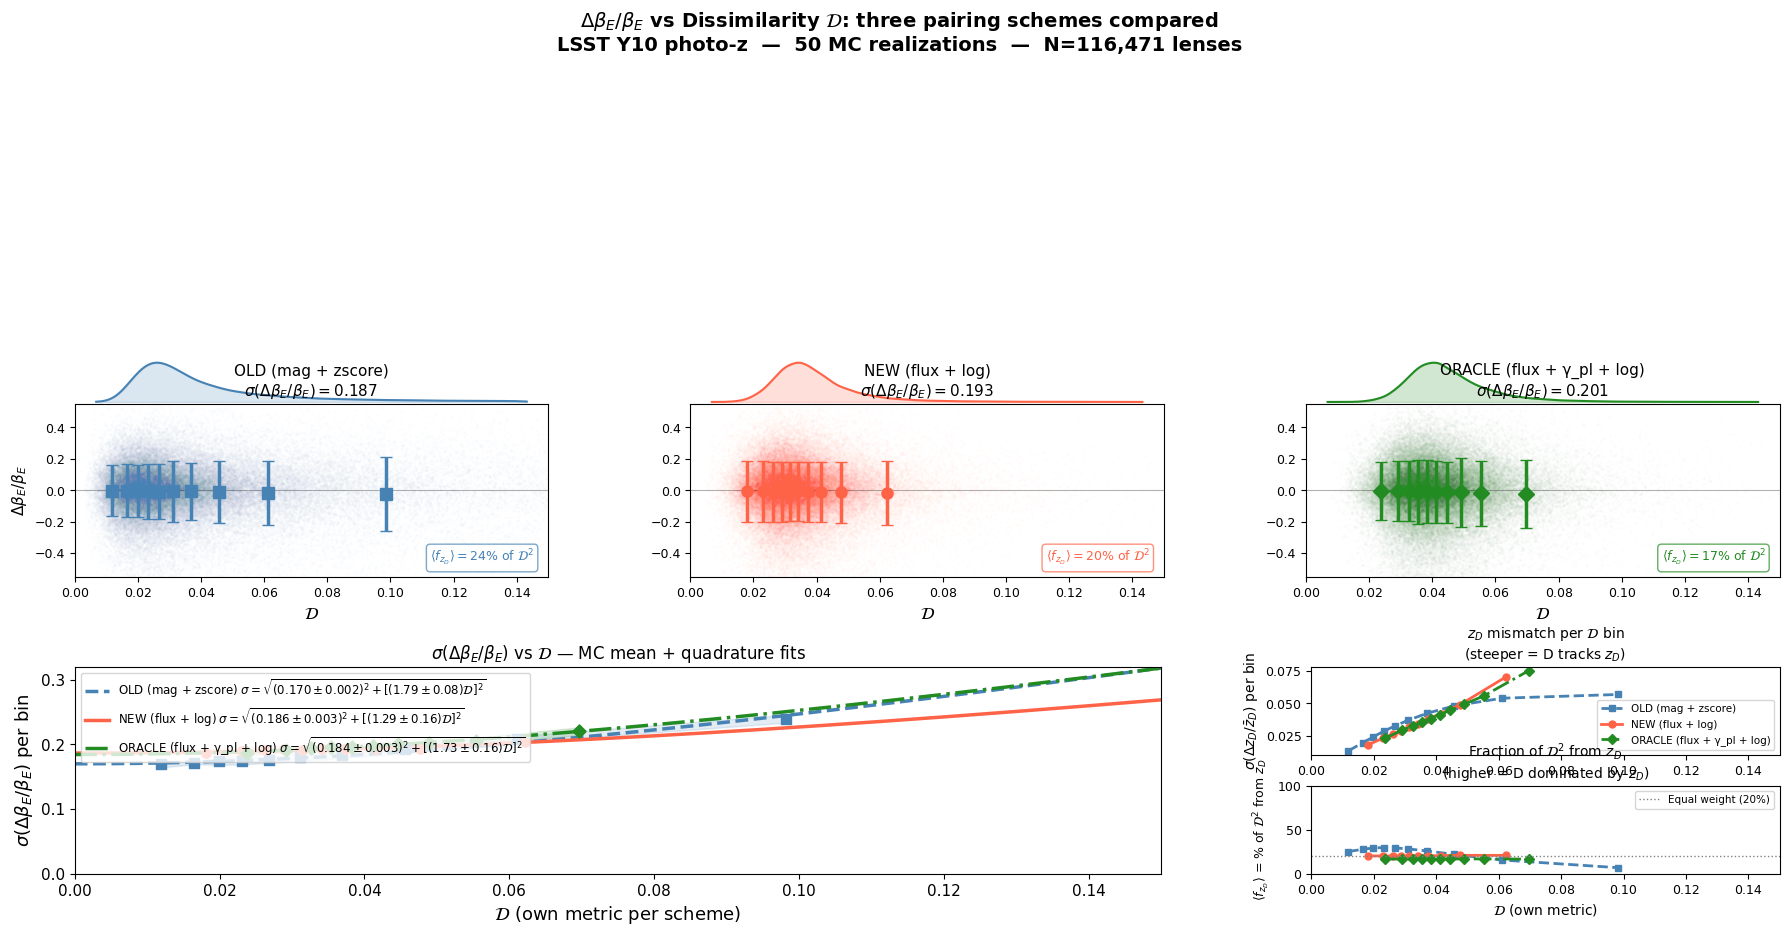


                  Quadrature fit: σ = sqrt(c0² + [c1·D]²)                  
Scheme                                      c0 (floor)      c1 (slope)
---------------------------------------------------------------------------
  OLD (mag + zscore)                   0.170 ± 0.002   1.79 ± 0.08
  NEW (flux + log)                     0.186 ± 0.003   1.29 ± 0.16
  ORACLE (flux + γ_pl + log)           0.184 ± 0.003   1.73 ± 0.16

Key question: does D in each scheme track z_D mismatch?
  OLD (mag + zscore)                     mean frac D² from z_D = 24.1%
  NEW (flux + log)                       mean frac D² from z_D = 20.4%
  ORACLE (flux + γ_pl + log)             mean frac D² from z_D = 16.6%


/tmp/ipykernel_121444/1589257517.py:209: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [25]:
# ==============================================================================
# CELL 3: β_E vs D COMPARISON — trend + decomposition
# Requires: schemes, mc_results, last_pairs, MAX_D (from Cell 1)
#
# Four-panel layout:
#   Top row:    β_E vs D scatter (one panel per scheme, last MC realization)
#   Bottom row: σ(β_E) vs D overlaid (MC mean + quadrature fits)
#               σ(Δz_D) vs D per bin (explains why trend slope differs)
#               Fraction of D² from z_D vs D (the root cause panel)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy.stats import gaussian_kde

def quad_model(x, c0, c1):
    return np.sqrt(c0**2 + (c1 * x)**2)

fit_results = {}

# ─────────────────────────────────────────────────────────────────────────────
# Layout
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 9))
fig.suptitle(
    r'$\Delta\beta_E/\beta_E$ vs Dissimilarity $\mathcal{D}$: three pairing schemes compared'
    f'\nLSST Y10 photo-z  —  {N_realizations} MC realizations  —  N={len(test_table):,} lenses',
    fontsize=14, fontweight='bold', y=1.01
)
gs_top = gridspec.GridSpec(1, 3, figure=fig, top=0.62, bottom=0.38,
                            hspace=0.0, wspace=0.30)
gs_bot = gridspec.GridSpec(1, 3, figure=fig, top=0.28, bottom=0.05,
                            hspace=0.0, wspace=0.32)

# ─────────────────────────────────────────────────────────────────────────────
# TOP ROW: β_E vs D scatter (one panel per scheme)
# ─────────────────────────────────────────────────────────────────────────────
for col, (sk, s) in enumerate(schemes.items()):
    gs_in = gridspec.GridSpecFromSubplotSpec(5, 1, subplot_spec=gs_top[col], hspace=0.0)
    ax_h  = fig.add_subplot(gs_in[0])       # KDE marginal
    ax_s  = fig.add_subplot(gs_in[1:])      # main scatter

    beta  = last_pairs[sk]['beta']
    dissim = last_pairs[sk]['dissim']
    mask  = (dissim < MAX_D) & np.isfinite(beta)
    dm    = dissim[mask]; bm = beta[mask]

    # Scatter
    ax_s.scatter(dm, bm, color=s['color'], alpha=s['alpha_sc'], s=4,
                 linewidths=0, rasterized=True)

    # Binned error bars
    pct = np.percentile(dm, np.arange(0, 101, 10))
    dig = np.digitize(dm, pct)
    bx, by, be = [], [], []
    for i in range(1, len(pct)):
        bm_bin = (dig == i)
        if bm_bin.any():
            bx.append(np.median(dm[bm_bin]))
            by.append(np.nanmean(bm[bm_bin]))
            be.append(np.nanstd(bm[bm_bin]))
    ax_s.errorbar(bx, by, yerr=be, fmt=s['marker'], color=s['color'],
                  markersize=8, capsize=4, elinewidth=2.5, zorder=5)

    # KDE on top
    try:
        x_grid = np.linspace(0, MAX_D, 200)
        ax_h.plot(x_grid, gaussian_kde(dm)(x_grid), color=s['color'], lw=1.5)
        ax_h.fill_between(x_grid, 0, gaussian_kde(dm)(x_grid),
                           color=s['color'], alpha=0.2)
    except Exception:
        pass
    ax_h.axis('off')

    # Annotations
    sigma_all = np.nanstd(bm)
    mask_cut  = (dm < MAX_D)
    ax_s.set_title(f"{sk.replace(chr(10), ' ')}\n"
                   fr"$\sigma(\Delta\beta_E/\beta_E)={sigma_all:.3f}$",
                   fontsize=11)
    ax_s.set_xlim(0, MAX_D)
    ax_s.set_ylim(-0.55, 0.55)
    ax_s.axhline(0, color='k', lw=0.8, alpha=0.3)
    ax_s.set_xlabel(r'$\mathcal{D}$', fontsize=12)
    ax_s.set_ylabel(r'$\Delta\beta_E/\beta_E$' if col == 0 else '', fontsize=11)
    ax_s.tick_params(labelsize=9)

    # Per-scheme D composition annotation
    frac = last_pairs[sk]['frac_zD']
    mean_frac_zD = np.nanmean(frac[mask]) * 100
    ax_s.text(0.97, 0.05,
              fr"$\langle f_{{z_D}} \rangle={mean_frac_zD:.0f}\%$ of $\mathcal{{D}}^2$",
              transform=ax_s.transAxes, ha='right', va='bottom',
              fontsize=9, color=s['color'],
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor=s['color']))

# ─────────────────────────────────────────────────────────────────────────────
# BOTTOM LEFT: σ(β_E) vs D from MC — quadrature fits overlaid
# ─────────────────────────────────────────────────────────────────────────────
ax_sigma = fig.add_subplot(gs_bot[0, :2])

for sk, s in schemes.items():
    all_d = np.array(mc_results[sk]['binned_dissim'])
    all_b = np.array(mc_results[sk]['binned_scatter'])
    mean_d = np.nanmean(all_d, axis=0)
    mean_b = np.nanmean(all_b, axis=0)
    std_b  = np.nanstd(all_b, axis=0)

    valid = np.isfinite(mean_d) & np.isfinite(mean_b) & (mean_b > 0)
    xd = mean_d[valid]; yb = mean_b[valid]; eb = std_b[valid]

    ax_sigma.scatter(xd, yb, marker=s['marker'], color=s['color'], s=45, zorder=4)
    ax_sigma.fill_between(xd, yb - eb, yb + eb, color=s['color'], alpha=0.15)

    try:
        popt, pcov = curve_fit(quad_model, xd, yb, sigma=np.where(eb > 0, eb, 0.01),
                               absolute_sigma=True, p0=[0.05, 1.0], maxfev=5000)
        c0, c1   = popt
        ec0, ec1 = np.sqrt(np.diag(pcov))
        xfit = np.linspace(0, MAX_D, 300)
        ax_sigma.plot(xfit, quad_model(xfit, c0, c1),
                      color=s['color'], lw=2.5, ls=s['ls'],
                      label=(fr"{sk.replace(chr(10), ' ')}"
                             fr"$\;\sigma=\sqrt{{({c0:.3f}\pm{ec0:.3f})^2"
                             fr"+[({c1:.2f}\pm{ec1:.2f})\mathcal{{D}}]^2}}$"))
        fit_results[sk] = {'c0': c0, 'c1': c1, 'ec0': ec0, 'ec1': ec1}
    except Exception as e:
        print(f"Fit failed {sk}: {e}")
        ax_sigma.plot(xd, yb, color=s['color'], lw=2.5, ls=s['ls'],
                      label=sk.replace('\n', ' '))

ax_sigma.set_xlabel(r'$\mathcal{D}$ (own metric per scheme)', fontsize=13)
ax_sigma.set_ylabel(r'$\sigma(\Delta\beta_E/\beta_E)$ per bin', fontsize=13)
ax_sigma.set_title(r'$\sigma(\Delta\beta_E/\beta_E)$ vs $\mathcal{D}$ — MC mean + quadrature fits', fontsize=12)
ax_sigma.set_xlim(0, MAX_D); ax_sigma.set_ylim(0, 0.32)
ax_sigma.legend(fontsize=8.5, frameon=True, loc='upper left')
ax_sigma.tick_params(labelsize=11)

# ─────────────────────────────────────────────────────────────────────────────
# BOTTOM RIGHT: Two diagnostic panels stacked
#   Top half: σ(Δz_D) per D bin — explains why slopes differ
#   Bot half: mean fraction of D² from z_D per bin — root cause
# ─────────────────────────────────────────────────────────────────────────────
gs_br = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs_bot[0, 2], hspace=0.35)
ax_dz  = fig.add_subplot(gs_br[0])
ax_fzD = fig.add_subplot(gs_br[1])

for sk, s in schemes.items():
    label = sk.replace('\n', ' ')

    # σ(Δz_D) per D bin
    all_d  = np.array(mc_results[sk]['binned_dissim'])
    all_dz = np.array(mc_results[sk]['binned_scatter_zD'])
    mean_d  = np.nanmean(all_d, axis=0)
    mean_dz = np.nanmean(all_dz, axis=0)
    valid = np.isfinite(mean_d) & np.isfinite(mean_dz)
    ax_dz.plot(mean_d[valid], mean_dz[valid], color=s['color'], lw=2, ls=s['ls'],
               marker=s['marker'], markersize=5, label=label)

    # Fraction of D² from z_D per bin
    all_fzD  = np.array(mc_results[sk]['binned_frac_zD'])
    mean_fzD = np.nanmean(all_fzD, axis=0)
    valid_f  = np.isfinite(mean_d) & np.isfinite(mean_fzD)
    ax_fzD.plot(mean_d[valid_f], mean_fzD[valid_f] * 100,
                color=s['color'], lw=2, ls=s['ls'],
                marker=s['marker'], markersize=5)

ax_dz.set_ylabel(r'$\sigma(\Delta z_D/\bar{z}_D)$ per bin', fontsize=10)
ax_dz.set_title(r'$z_D$ mismatch per $\mathcal{D}$ bin'
                '\n(steeper = D tracks $z_D$)', fontsize=10)
ax_dz.legend(fontsize=7.5, frameon=True)
ax_dz.tick_params(labelsize=9)
ax_dz.set_xlim(0, MAX_D)

ax_fzD.set_xlabel(r'$\mathcal{D}$ (own metric)', fontsize=10)
ax_fzD.set_ylabel(r'$\langle f_{z_D}\rangle$ = % of $\mathcal{D}^2$ from $z_D$', fontsize=9)
ax_fzD.set_title(r'Fraction of $\mathcal{D}^2$ from $z_D$'
                 '\n(higher = D dominated by $z_D$)', fontsize=10)
ax_fzD.set_xlim(0, MAX_D)
ax_fzD.set_ylim(0, 100)
ax_fzD.axhline(100/len(base_pairing_keys), color='gray', lw=1, ls=':',
               label=f'Equal weight ({100/len(base_pairing_keys):.0f}%)')
ax_fzD.legend(fontsize=7.5, frameon=True)
ax_fzD.tick_params(labelsize=9)

plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Print fit results table
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "="*75)
print(f"{'Quadrature fit: σ = sqrt(c0² + [c1·D]²)':^75}")
print("="*75)
print(f"{'Scheme':<38} {'c0 (floor)':>15} {'c1 (slope)':>15}")
print("-"*75)
for sk, fr in fit_results.items():
    label = sk.replace('\n', ' ')
    print(f"  {label:<36} {fr['c0']:.3f} ± {fr['ec0']:.3f}   {fr['c1']:.2f} ± {fr['ec1']:.2f}")
print("="*75)

print("\nKey question: does D in each scheme track z_D mismatch?")
for sk, s in schemes.items():
    frac_zD_all = last_pairs[sk]['frac_zD']
    mask        = last_pairs[sk]['dissim'] < MAX_D
    label = sk.replace('\n', ' ')
    print(f"  {label:<38} mean frac D² from z_D = {np.nanmean(frac_zD_all[mask])*100:.1f}%")

fig.tight_layout()

## Dummy Pairing

Dataset: N=3000,  feature dynamic ranges:
  z: range=     9.0x   CV=0.390
  R: range=    30.0x   CV=0.536
  f: range=   994.9x   CV=1.559  ← 3 orders of magnitude
  c1: range=     7.1x   CV=0.306
  c2: range=     6.0x   CV=0.251

β sensitivities |∂lnβ/∂ln(x)|  (larger = feature matters more for β):
    z: 1.028  █████████████████████
    R: 0.150  ███
    f: 0.000    ← f unused in β
   c1: 0.300  ██████
   c2: 0.400  ████████

Pairing 3000 points...

Method         # Pairs   Overlap w/ Exact   mean D    σ(Δβ/β)   σ(Δf/f̄)
------------------------------------------------------------------------
  Z-score        2,225              19.9%   0.3679     0.1812     0.9616
  Log            2,254              99.5%   0.1288     0.1806     0.1329
  Exact          2,256             100.0%   0.1288     0.1807     0.1327

Predicted vs actual σ(Δβ/β)  [validates linear sensitivity approximation]:
  Z-score     : predicted=0.1449  actual=0.1812  ratio=1.25
  Log         : predicted=0.1539  actual=0.1

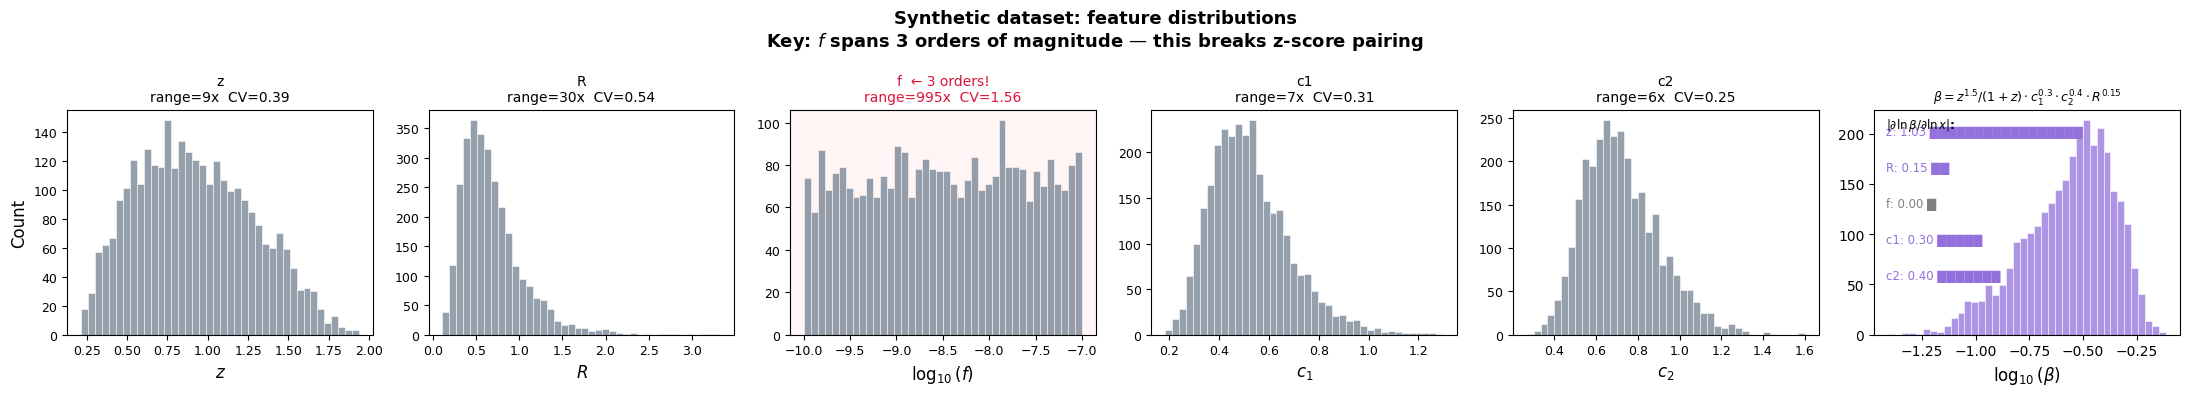

/tmp/ipykernel_36683/3465256033.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig2.tight_layout()


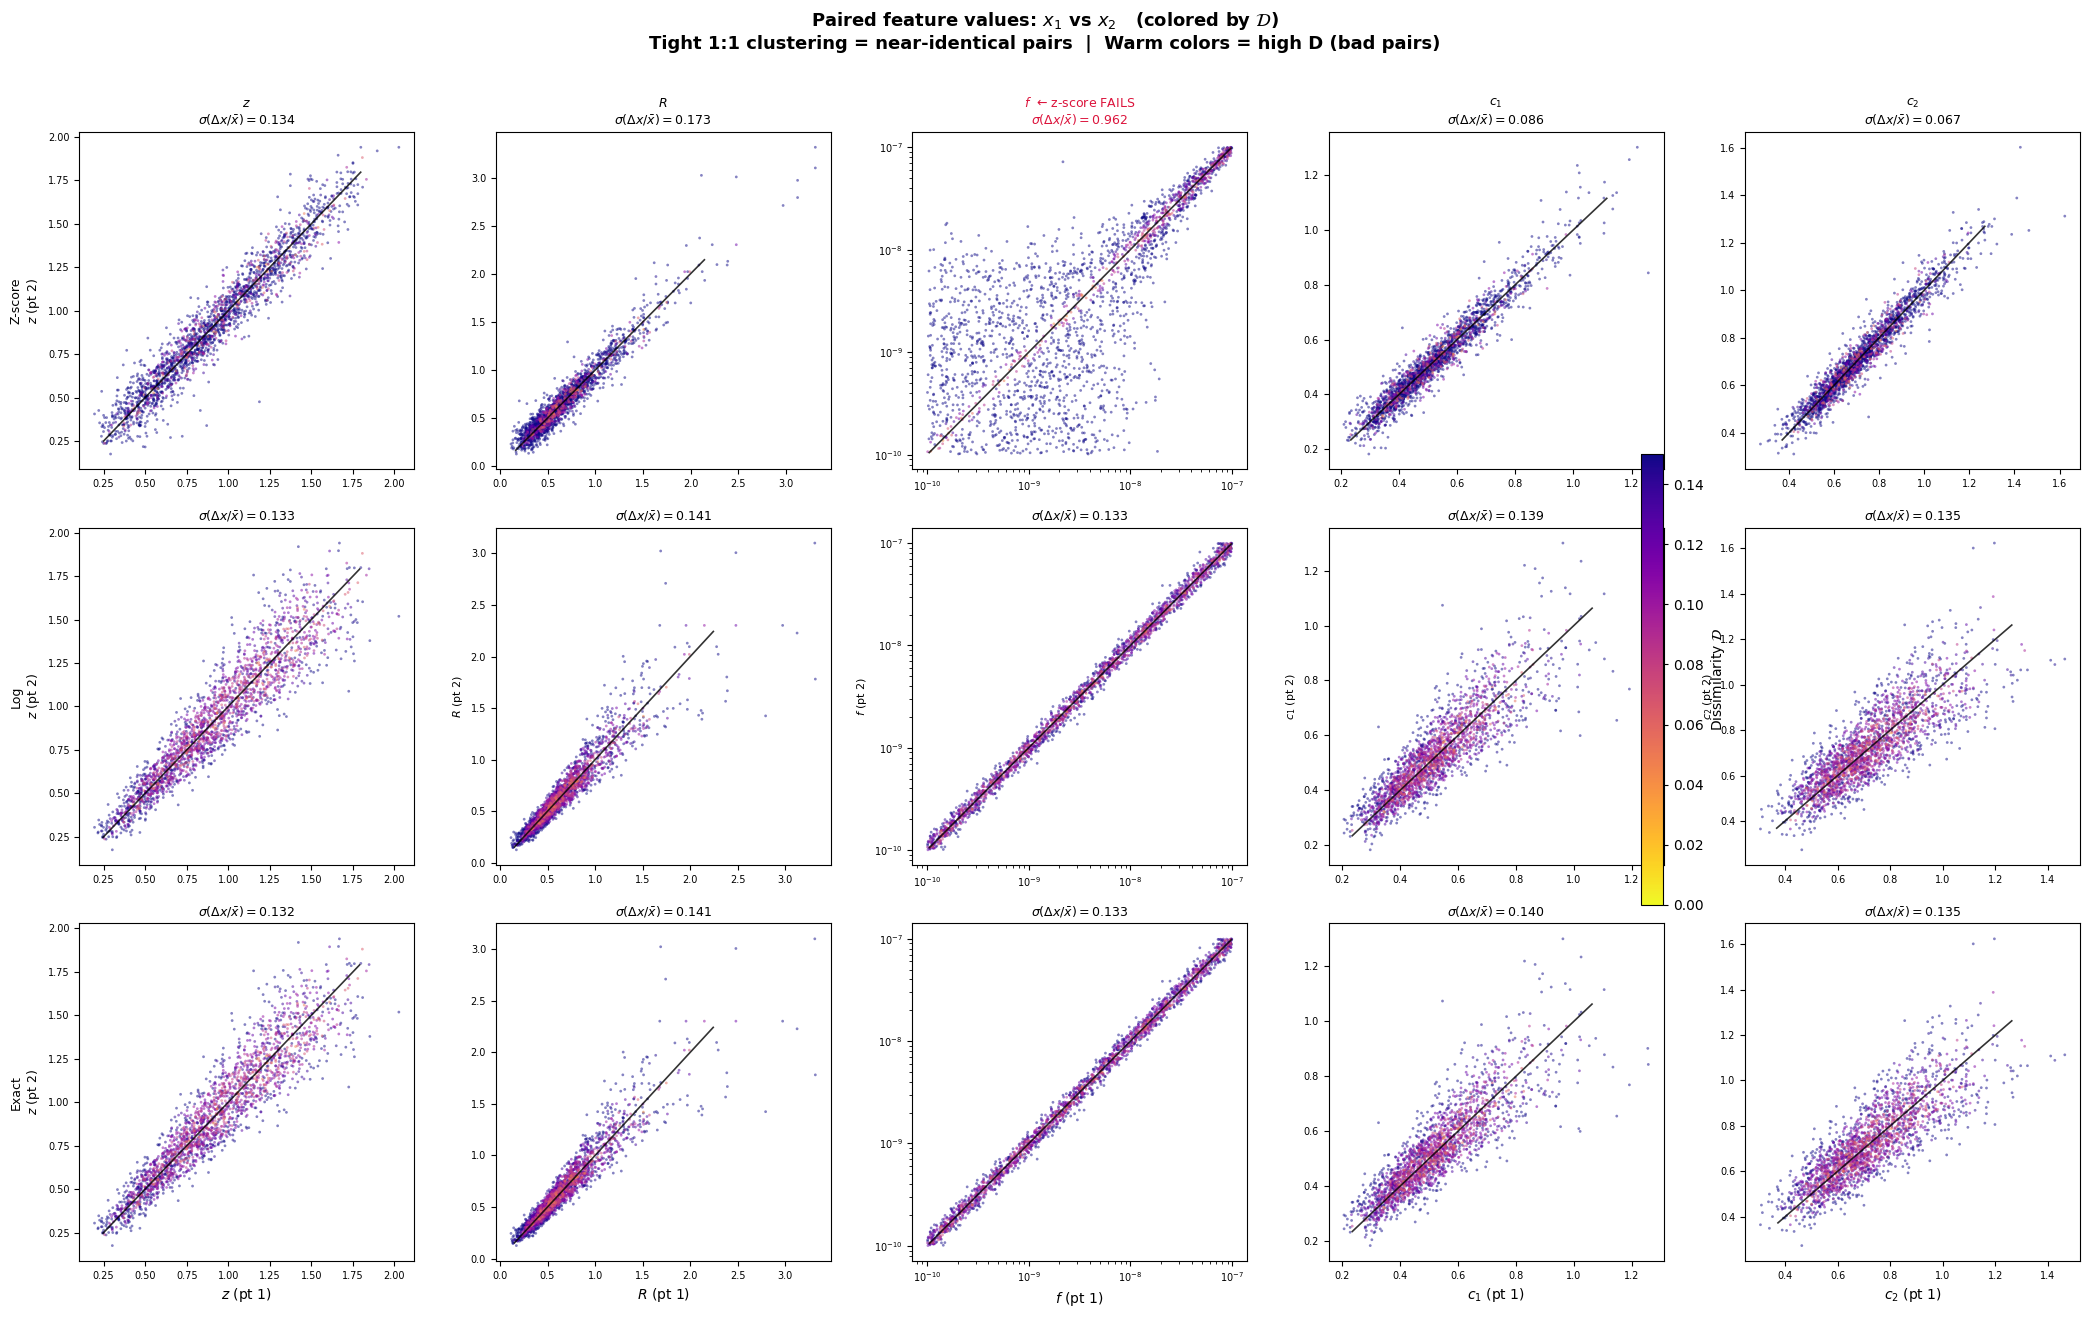

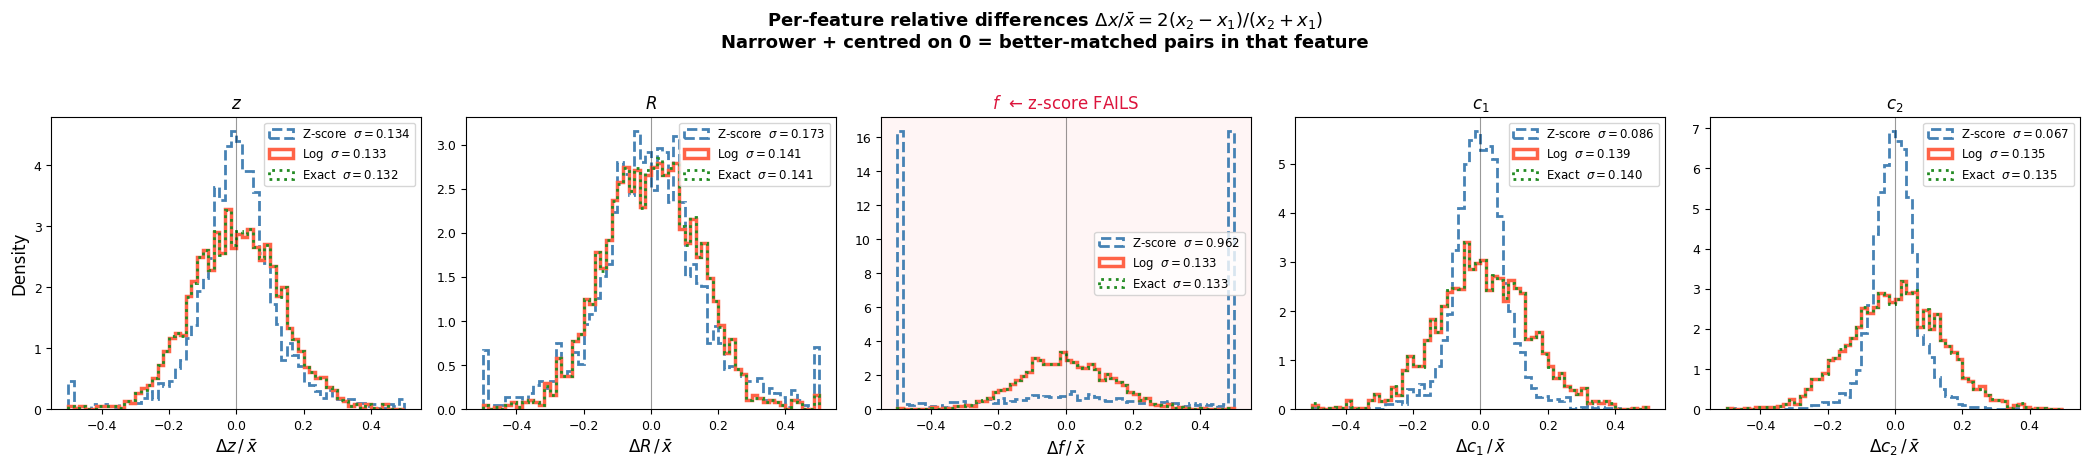

/tmp/ipykernel_36683/3465256033.py:444: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig4.tight_layout()


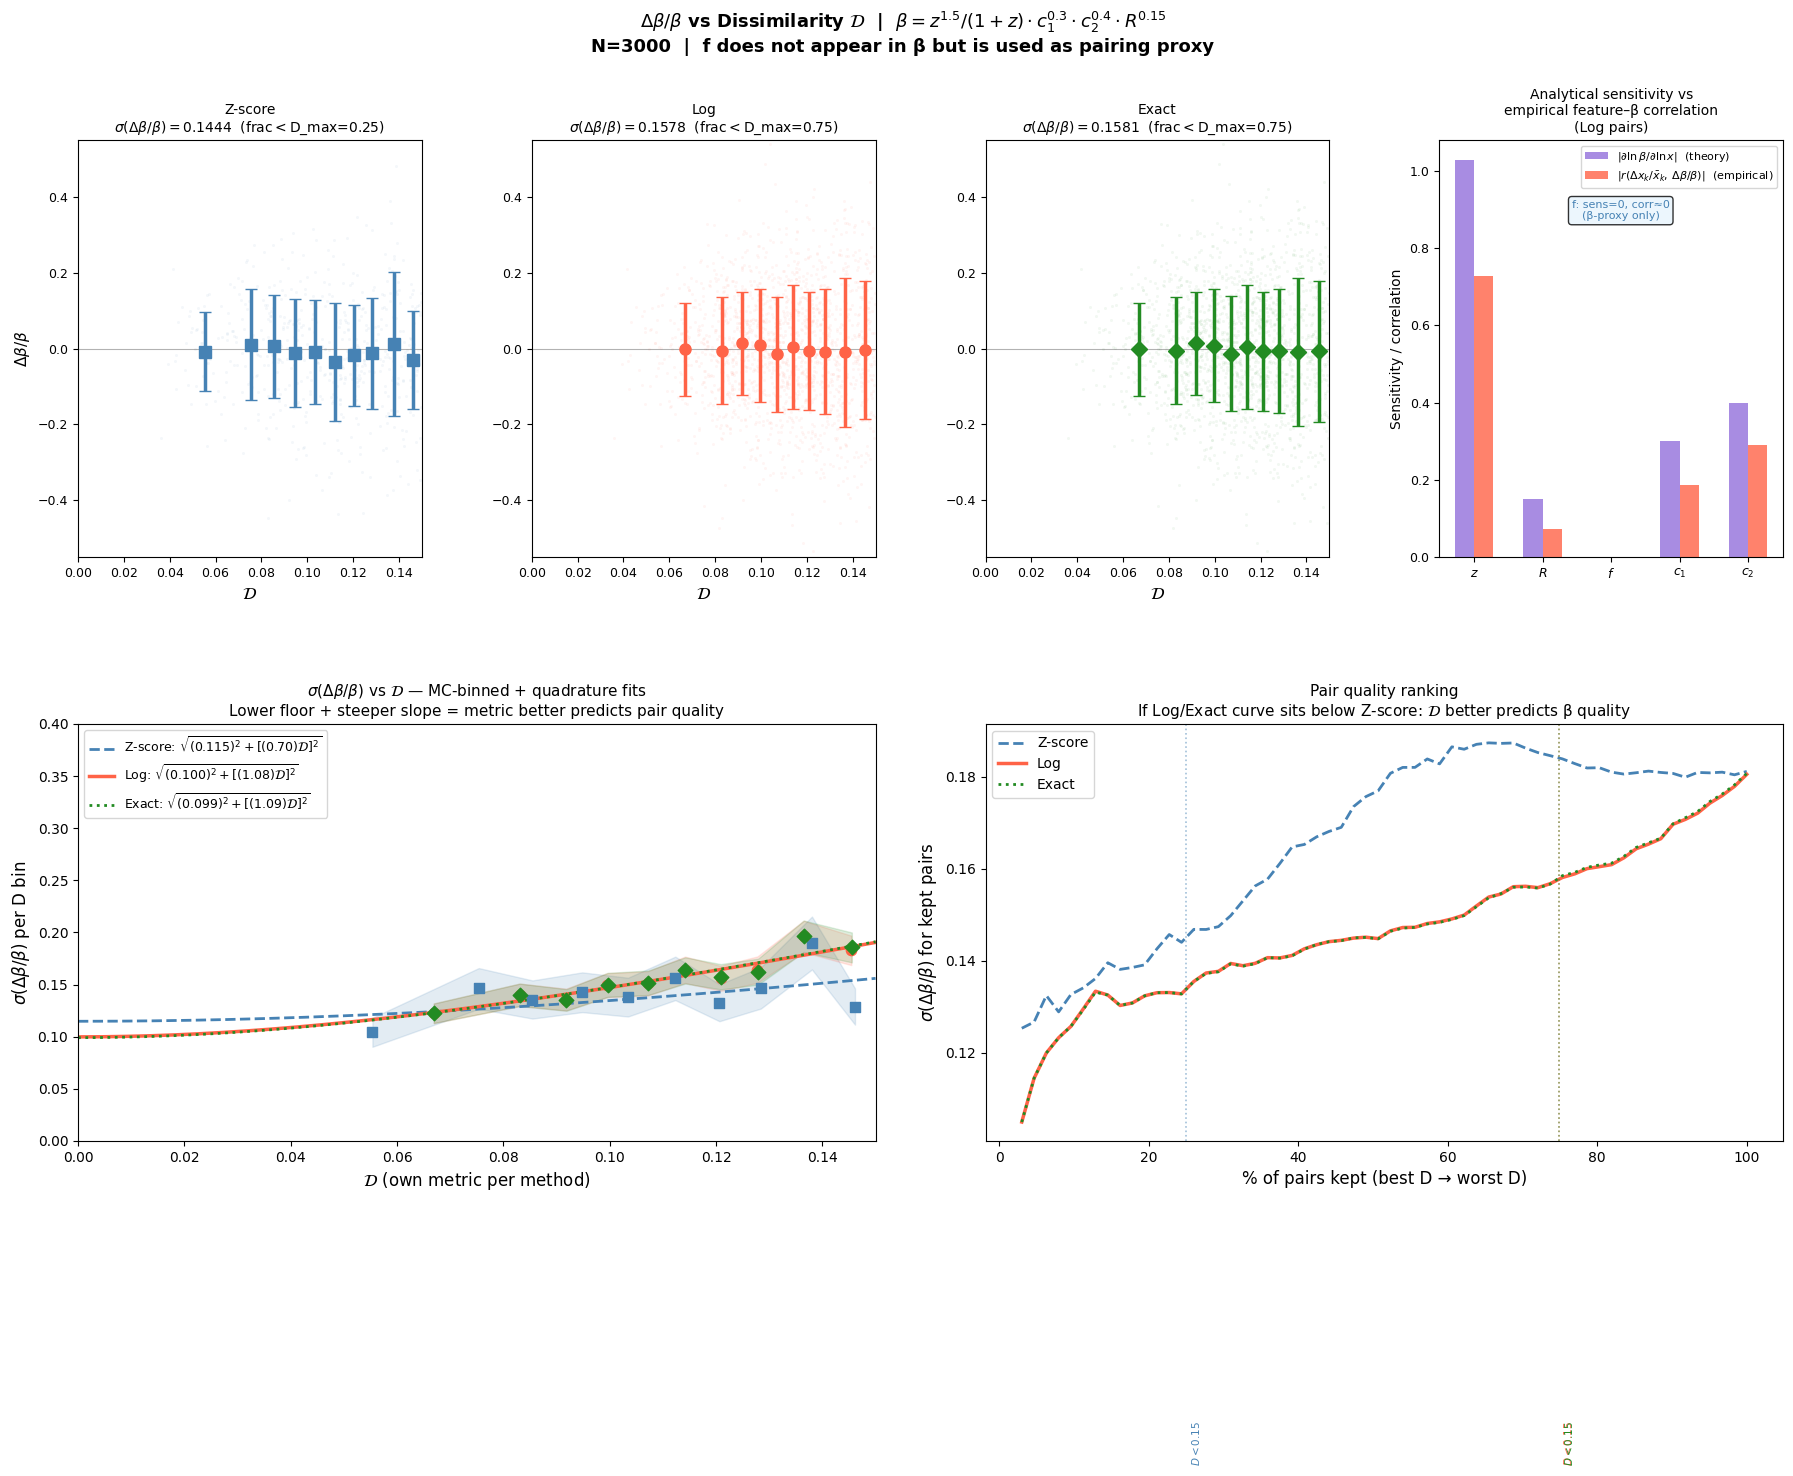

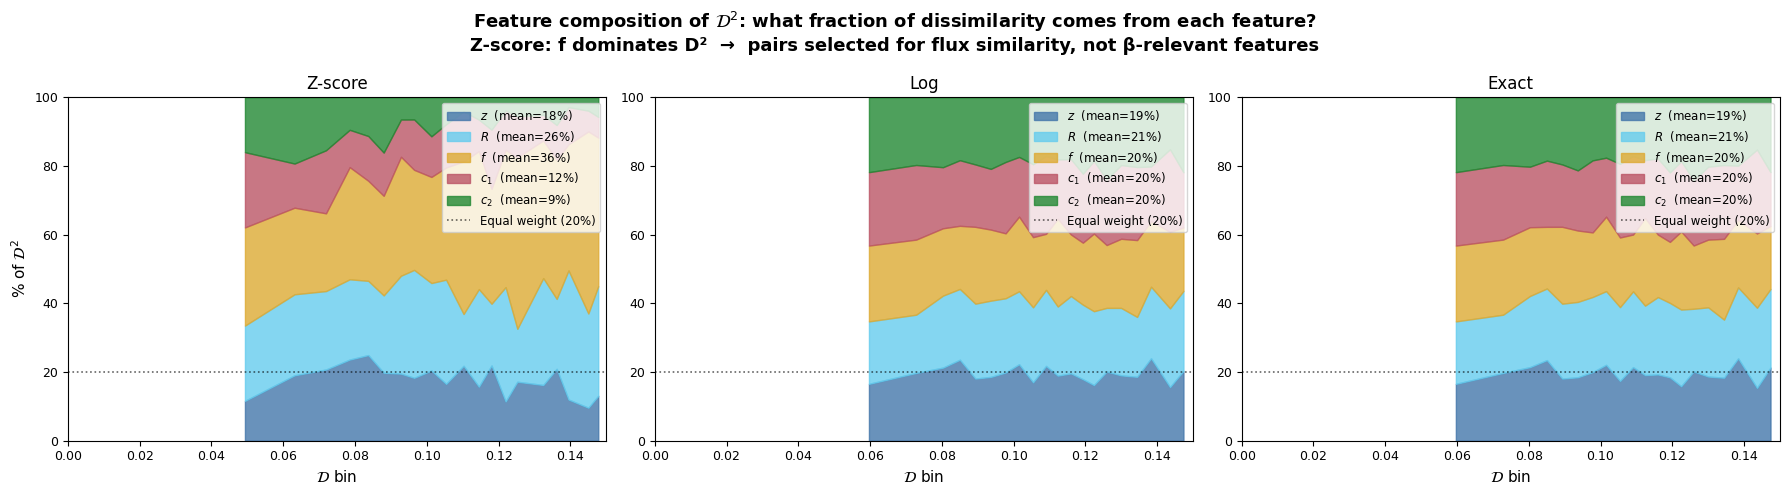

In [1]:
# ==============================================================================
# SYNTHETIC PAIRING TEST — Fully self-contained, no external data required
#
# A controlled 5-dimensional dataset where ground truth is fully known.
# Designed to validate and visualize the log-metric KD-Tree pairing methodology.
#
# Feature space (N=3000 points):
#   z  ∈ [0.2, 2.0]    — redshift-like        (Beta distribution)
#   R  ∈ [0.05, 3.5]   — size-like            (log-normal)
#   f  ∈ [1e-10, 1e-7] — flux-like            (log-uniform, 3 orders of magnitude)
#   c1 ∈ [0.15, 1.3]   — flux ratio 1         (log-normal)
#   c2 ∈ [0.20, 1.6]   — flux ratio 2         (log-normal)
#
# β-analog (mimics β_E in DSPL):
#   β(z, R, c1, c2) = z^1.5/(1+z) · c1^0.3 · c2^0.4 · R^0.15
#   f does NOT enter β directly — it is a pairing proxy only
#   Sensitivities: ∂lnβ/∂lnz ≈ 0.5–1.5, ∂/∂lnc1=0.3, ∂/∂lnc2=0.4, ∂/∂lnR=0.15
#
# Methods:
#   ZSCORE — z-score KD-Tree (fails for f spanning 3 orders of magnitude)
#   LOG    — log KD-Tree     (correct, validated ≈ exact)
#   EXACT  — O(N²) brute-force (ground truth)
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from scipy import spatial
from scipy.optimize import curve_fit

# ── 0. CONFIG ─────────────────────────────────────────────────────────────────
N      = 3000
MAX_D  = 0.15
CLIP   = 0.5
np.random.seed(42)

FEATS     = ['z', 'R', 'f', 'c1', 'c2']
FEAT_TEX  = [r'$z$', r'$R$', r'$f$', r'$c_1$', r'$c_2$']
LOG_FEATS = {'f'}

MS = {
    'Z-score': {'c': 'steelblue',    'ls': '--', 'lw': 2.0, 'mk': 's', 'a': 0.06},
    'Log':     {'c': 'tomato',       'ls': '-',  'lw': 2.5, 'mk': 'o', 'a': 0.06},
    'Exact':   {'c': 'forestgreen',  'ls': ':',  'lw': 2.0, 'mk': 'D', 'a': 0.06},
}

# ── 1. GENERATE DATA ──────────────────────────────────────────────────────────
z  = np.random.beta(2, 3, N) * 1.8 + 0.2
R  = np.clip(np.exp(np.random.normal(np.log(0.6), 0.5,  N)), 0.05, 3.5)
f  = 10**np.random.uniform(-10, -7, N)
c1 = np.clip(np.exp(np.random.normal(np.log(0.5), 0.30, N)), 0.15, 1.3)
c2 = np.clip(np.exp(np.random.normal(np.log(0.7), 0.25, N)), 0.20, 1.6)
X_true = np.column_stack([z, R, f, c1, c2])

print(f"Dataset: N={N},  feature dynamic ranges:")
for name, col in zip(FEATS, X_true.T):
    rng = col.max() / col.min()
    cv  = col.std() / col.mean()
    print(f"  {name}: range={rng:8.1f}x   CV={cv:.3f}"
          + ("  ← 3 orders of magnitude" if name == 'f' else ""))

# ── 2. β-ANALOG (derived parameter) ──────────────────────────────────────────
def beta_fn(X):
    z_, R_, f_, c1_, c2_ = X.T
    return (z_**1.5 / (1 + z_)) * (c1_**0.3) * (c2_**0.4) * (R_**0.15)

beta_vals = beta_fn(X_true)

# Analytic log-sensitivities ∂lnβ/∂ln(x_k)
SENS = {
    'z':  np.median(1.5 - z / (1 + z)),   # ~0.9, dominant
    'R':  0.15,
    'f':  0.00,                            # f not in β
    'c1': 0.30,
    'c2': 0.40,
}
print(f"\nβ sensitivities |∂lnβ/∂ln(x)|  (larger = feature matters more for β):")
for k, v in SENS.items():
    bar = '█' * int(round(v / 0.05))
    print(f"  {k:>3}: {v:.3f}  {bar}" + ("  ← f unused in β" if k == 'f' else ""))

# ── 3. INJECT OBSERVATIONAL ERRORS ───────────────────────────────────────────
ERR_FRAC = {'z': 0.03, 'R': 0.05, 'f': 0.01, 'c1': 0.014, 'c2': 0.014}
sigma = {
    'z':  ERR_FRAC['z']  * (1 + z),
    'R':  ERR_FRAC['R']  * R,
    'f':  ERR_FRAC['f']  * f,
    'c1': ERR_FRAC['c1'] * c1,
    'c2': ERR_FRAC['c2'] * c2,
}
X_obs = np.column_stack([
    np.clip(z  + np.random.normal(0, sigma['z'],  N), 0.05, 3.0),
    np.clip(R  + np.random.normal(0, sigma['R'],  N), 0.02, 5.0),
    np.clip(f  + np.random.normal(0, sigma['f'],  N), 1e-15, None),
    np.clip(c1 + np.random.normal(0, sigma['c1'], N), 0.05, 2.5),
    np.clip(c2 + np.random.normal(0, sigma['c2'], N), 0.05, 2.5),
])

# ── 4. PAIRING METHODS ────────────────────────────────────────────────────────
def _unique_pairs(pts):
    tree = spatial.KDTree(pts)
    _, idx = tree.query(pts, k=2)
    pairs = np.sort(np.column_stack((np.arange(len(pts)), idx[:, 1])), axis=1)
    pairs, _ = np.unique(pairs, axis=0, return_index=True)
    return pairs

def pair_zscore(X):
    mu, sg = X.mean(0), X.std(0); sg[sg == 0] = 1
    return _unique_pairs((X - mu) / sg)

def pair_log(X):
    return _unique_pairs(np.log(X))

def pair_exact(X):
    Xi, Xj = X[:, None, :], X[None, :, :]
    D = np.sqrt(np.mean((2 * (Xj - Xi) / (Xj + Xi))**2, axis=2))
    np.fill_diagonal(D, np.inf)
    nn = np.argmin(D, axis=1)
    pairs = np.sort(np.column_stack((np.arange(N), nn)), axis=1)
    pairs, _ = np.unique(pairs, axis=0, return_index=True)
    return pairs

print(f"\nPairing {N} points...")
idx = {
    'Z-score': pair_zscore(X_obs),
    'Log':     pair_log(X_obs),
    'Exact':   pair_exact(X_obs),
}

# ── 5. PER-METHOD STATISTICS ──────────────────────────────────────────────────
def get_stats(pairs):
    X1, X2 = X_obs[pairs[:, 0]], X_obs[pairs[:, 1]]
    rd   = 2 * (X2 - X1) / (X1 + X2)                  # (P, 5) relative diffs
    D    = np.sqrt(np.mean(rd**2, axis=1))              # (P,) dissimilarity
    b1   = beta_fn(X_true[pairs[:, 0]])
    b2   = beta_fn(X_true[pairs[:, 1]])
    db   = 2 * (b2 - b1) / (b1 + b2)                   # Δβ/β (noiseless β)
    mask = np.isfinite(db) & np.isfinite(D)
    frac = {FEATS[k]: rd[:, k]**2 / (5 * D**2 + 1e-30) for k in range(5)}
    return {'D': D, 'db': db, 'rd': rd, 'mask': mask,
            'X1': X1, 'X2': X2, 'frac': frac}

res = {m: get_stats(idx[m]) for m in MS}

set_e = set(map(tuple, idx['Exact']))
print(f"\n{'Method':<12} {'# Pairs':>9} {'Overlap w/ Exact':>18} "
      f"{'mean D':>8} {'σ(Δβ/β)':>10} {'σ(Δf/f̄)':>10}")
print("-"*72)
for m, r in res.items():
    mk = r['mask']
    ov = f"{100*len(set(map(tuple, idx[m])) & set_e)/len(set_e):.1f}%"
    rd_f = r['rd'][:, 2][np.isfinite(r['rd'][:, 2])]
    print(f"  {m:<10} {mk.sum():>9,} {ov:>18} "
          f"{np.nanmean(r['D'][mk]):>8.4f} "
          f"{np.nanstd(r['db'][mk]):>10.4f} "
          f"{np.nanstd(rd_f):>10.4f}")

# Predicted σ(Δβ/β) from linear sensitivity analysis
print(f"\nPredicted vs actual σ(Δβ/β)  [validates linear sensitivity approximation]:")
sens_arr = np.array([SENS[k] for k in FEATS])
for m, r in res.items():
    mk = r['mask']
    rd = r['rd'][mk]
    sigma_rd = np.array([np.nanstd(rd[:, k]) for k in range(5)])
    predicted = np.sqrt(np.sum((sens_arr * sigma_rd)**2))
    actual    = np.nanstd(r['db'][mk])
    print(f"  {m:<12}: predicted={predicted:.4f}  actual={actual:.4f}  "
          f"ratio={actual/predicted:.2f}")

# ══════════════════════════════════════════════════════════════════════════════
# VISUALIZATION
# ══════════════════════════════════════════════════════════════════════════════
norm_d = mcolors.Normalize(vmin=0, vmax=MAX_D)
cmap_d = plt.cm.plasma_r

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1: Feature distributions + β overview
# ─────────────────────────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 6, figsize=(22, 4))
fig1.suptitle(
    'Synthetic dataset: feature distributions\n'
    r'Key: $f$ spans 3 orders of magnitude — this breaks z-score pairing',
    fontsize=13, fontweight='bold'
)

for i, (feat, tex) in enumerate(zip(FEATS, FEAT_TEX)):
    ax   = axes1[i]
    vals = X_true[:, i]
    x    = np.log10(vals) if feat in LOG_FEATS else vals
    ax.hist(x, bins=40, color='slategray', alpha=0.75, edgecolor='white', lw=0.5)
    xlabel = fr'$\log_{{10}}$({tex})' if feat in LOG_FEATS else tex
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel('Count' if i == 0 else '', fontsize=12)
    rng = vals.max() / vals.min()
    cv  = vals.std() / vals.mean()
    ax.set_title(f'{feat}\nrange={rng:.0f}x  CV={cv:.2f}', fontsize=10)
    if feat == 'f':
        ax.set_facecolor('#fff5f5')
        ax.set_title(f'{feat}  ← 3 orders!\nrange={rng:.0f}x  CV={cv:.2f}',
                     fontsize=10, color='crimson')
    ax.tick_params(labelsize=9)

# β distribution with sensitivity legend
ax_b = axes1[5]
ax_b.hist(np.log10(beta_vals), bins=40, color='mediumpurple', alpha=0.75,
          edgecolor='white', lw=0.5)
ax_b.set_xlabel(r'$\log_{10}(\beta)$', fontsize=12)
ax_b.set_title(r'$\beta = z^{1.5}/(1+z)\cdot c_1^{0.3}\cdot c_2^{0.4}\cdot R^{0.15}$',
               fontsize=9)
for i, (k, v) in enumerate(SENS.items()):
    col = 'gray' if k == 'f' else 'mediumpurple'
    bar = '█' * max(1, int(round(v / 0.06)))
    ax_b.text(0.04, 0.93 - i*0.16, f'{k}: {v:.2f} {bar}',
              transform=ax_b.transAxes, fontsize=8.5, color=col, va='top')
ax_b.text(0.04, 0.97, r'$|\partial\ln\beta/\partial\ln x|$:',
          transform=ax_b.transAxes, fontsize=8.5, fontweight='bold', va='top')

fig1.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2: x_1 vs x_2 scatter — 3 methods × 5 features
# The most direct "are pairs near-identical?" check
# ─────────────────────────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(3, 5, figsize=(21, 13), squeeze=False)
fig2.suptitle(
    r'Paired feature values: $x_1$ vs $x_2$   (colored by $\mathcal{D}$)'
    '\nTight 1:1 clustering = near-identical pairs  |  Warm colors = high D (bad pairs)',
    fontsize=13, fontweight='bold', y=1.01
)

for row, m in enumerate(MS):
    r = res[m]; D = r['D']
    order = np.argsort(D)[::-1]

    for col, (feat, tex) in enumerate(zip(FEATS, FEAT_TEX)):
        ax = axes2[row, col]
        v1 = r['X1'][:, col][order]
        v2 = r['X2'][:, col][order]
        sc = ax.scatter(v1, v2, c=D[order], cmap=cmap_d, norm=norm_d,
                        s=4, alpha=0.5, linewidths=0, rasterized=True)
        plo = min(np.nanpercentile(v1, 0.5),  np.nanpercentile(v2, 0.5))
        phi = max(np.nanpercentile(v1, 99.5), np.nanpercentile(v2, 99.5))
        ax.plot([plo, phi], [plo, phi], 'k-', lw=1.2, alpha=0.8, zorder=5)
        if feat in LOG_FEATS:
            ax.set_xscale('log'); ax.set_yscale('log')
        rms = np.nanstd(r['rd'][:, col][np.isfinite(r['rd'][:, col])])
        title = (fr'{tex}  ← z-score FAILS' if feat == 'f' and row == 0 else tex) \
                if row == 0 else ''
        ax.set_title(
            (title + '\n' if title else '') + fr'$\sigma(\Delta x/\bar{{x}})={rms:.3f}$',
            fontsize=9,
            color='crimson' if (feat == 'f' and row == 0) else 'black'
        )
        if col == 0:
            ax.set_ylabel(f'{m}\n{tex} (pt 2)', fontsize=9)
        else:
            ax.set_ylabel(f'{tex} (pt 2)' if row == 1 else '', fontsize=8)
        if row == 2:
            ax.set_xlabel(f'{tex} (pt 1)', fontsize=10)
        ax.tick_params(labelsize=7)

fig2.colorbar(plt.cm.ScalarMappable(norm=norm_d, cmap=cmap_d),
              ax=axes2, shrink=0.45, pad=0.01, label=r'Dissimilarity $\mathcal{D}$')
fig2.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3: Per-feature rel_diff histograms — 3 methods overlaid
# Narrow + centred on 0 = well-matched pairs
# ─────────────────────────────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 5, figsize=(21, 4.5))
fig3.suptitle(
    r'Per-feature relative differences $\Delta x/\bar{x} = 2(x_2-x_1)/(x_2+x_1)$'
    '\nNarrower + centred on 0 = better-matched pairs in that feature',
    fontsize=13, fontweight='bold', y=1.03
)

for col, (feat, tex) in enumerate(zip(FEATS, FEAT_TEX)):
    ax = axes3[col]
    for m, style in MS.items():
        rd    = res[m]['rd'][:, col]
        rd_c  = np.clip(rd[np.isfinite(rd)], -CLIP, CLIP)
        sigma = np.nanstd(rd[np.isfinite(rd)])
        ax.hist(rd_c, bins=60, range=(-CLIP, CLIP), density=True,
                histtype='step', color=style['c'], lw=style['lw'], ls=style['ls'],
                label=fr'{m}  $\sigma={sigma:.3f}$')
    ax.axvline(0, color='k', lw=0.8, alpha=0.4)
    ax.set_xlabel(fr'$\Delta${tex}$\,/\,\bar{{x}}$', fontsize=12)
    ax.set_ylabel('Density' if col == 0 else '', fontsize=12)
    ax.set_title(tex + ('  ← z-score FAILS' if feat == 'f' else ''), fontsize=12,
                 color='crimson' if feat == 'f' else 'black')
    ax.legend(fontsize=8.5, frameon=True)
    ax.tick_params(labelsize=9)
    if feat == 'f':
        ax.set_facecolor('#fff5f5')

fig3.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 4: Δβ/β vs D — scatter + σ trend + quality ranking + sensitivity
# ─────────────────────────────────────────────────────────────────────────────
fig4 = plt.figure(figsize=(22, 13))
fig4.suptitle(
    r'$\Delta\beta/\beta$ vs Dissimilarity $\mathcal{D}$  |  '
    r'$\beta = z^{1.5}/(1+z)\cdot c_1^{0.3}\cdot c_2^{0.4}\cdot R^{0.15}$'
    f'\nN={N}  |  f does not appear in β but is used as pairing proxy',
    fontsize=13, fontweight='bold'
)
gs4 = gridspec.GridSpec(2, 4, figure=fig4, hspace=0.40, wspace=0.32)

def quad(x, c0, c1): return np.sqrt(c0**2 + (c1 * x)**2)

# Top row: Δβ/β scatter per method
for col, (m, style) in enumerate(MS.items()):
    ax = fig4.add_subplot(gs4[0, col])
    r  = res[m]
    mk = r['mask'] & (r['D'] < MAX_D)
    D  = r['D'][mk]; db = r['db'][mk]

    ax.scatter(D, db, color=style['c'], alpha=style['a'], s=5,
               linewidths=0, rasterized=True)

    pct = np.percentile(D, np.arange(0, 101, 10))
    dig = np.digitize(D, pct)
    bx, by, be = [], [], []
    for i in range(1, len(pct)):
        bm = (dig == i)
        if bm.any():
            bx.append(np.median(D[bm]))
            by.append(np.nanmean(db[bm]))
            be.append(np.nanstd(db[bm]))
    ax.errorbar(bx, by, yerr=be, fmt=style['mk'], color=style['c'],
                markersize=8, capsize=4, elinewidth=2.5, zorder=5)

    sigma_all = np.nanstd(db)
    frac_D    = mk.sum() / r['mask'].sum()
    ax.set_title(fr'{m}' + '\n'
                 fr'$\sigma(\Delta\beta/\beta)={sigma_all:.4f}$  '
                 fr'(frac$<$D_max={frac_D:.2f})',
                 fontsize=10)
    ax.axhline(0, color='k', lw=0.8, alpha=0.3)
    ax.set_xlim(0, MAX_D); ax.set_ylim(-0.55, 0.55)
    ax.set_xlabel(r'$\mathcal{D}$', fontsize=12)
    ax.set_ylabel(r'$\Delta\beta/\beta$' if col == 0 else '', fontsize=11)
    ax.tick_params(labelsize=9)

# Top-right: feature sensitivity bar chart + empirical rel_diff σ
ax_sens = fig4.add_subplot(gs4[0, 3])
x_s = np.arange(5)
w_s = 0.28

# Theory (sensitivity)
sens_vals = np.array([SENS[f] for f in FEATS])
ax_sens.bar(x_s - w_s, sens_vals, w_s, color='mediumpurple', alpha=0.8,
            label=r'$|\partial\ln\beta/\partial\ln x|$  (theory)')

# Empirical: for Log pairs, how much does each feature's rel_diff contribute to Δβ/β
r_log = res['Log']; mk_l = r_log['mask']
rd    = r_log['rd'][mk_l]
db_l  = r_log['db'][mk_l]
empir = np.array([np.abs(np.corrcoef(rd[:, k], db_l)[0, 1]) for k in range(5)])
ax_sens.bar(x_s, empir, w_s, color='tomato', alpha=0.8,
            label=r'$|r(\Delta x_k/\bar{x}_k,\, \Delta\beta/\beta)|$  (empirical)')

ax_sens.set_xticks(x_s - w_s/2)
ax_sens.set_xticklabels(FEAT_TEX, fontsize=11)
ax_sens.set_ylabel('Sensitivity / correlation', fontsize=10)
ax_sens.set_title('Analytical sensitivity vs\nempirical feature–β correlation\n(Log pairs)',
                  fontsize=10)
ax_sens.legend(fontsize=8, frameon=True)
ax_sens.axhline(0, color='k', lw=0.5)
ax_sens.tick_params(labelsize=9)
ax_sens.text(2, max(sens_vals)*0.85, 'f: sens=0, corr≈0\n(β-proxy only)',
             ha='center', fontsize=8, color='steelblue',
             bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))

# Bottom-left: σ(Δβ/β) vs D — quadrature fits
ax_sig = fig4.add_subplot(gs4[1, :2])

for m, style in MS.items():
    r  = res[m]; mk = r['mask'] & (r['D'] < MAX_D)
    D  = r['D'][mk]; db = r['db'][mk]
    pct = np.percentile(D, np.arange(0, 101, 10))
    dig = np.digitize(D, pct)
    bx, by, be = [], [], []
    for i in range(1, len(pct)):
        bm = (dig == i)
        if bm.any():
            bx.append(np.median(D[bm]))
            by.append(np.nanstd(db[bm]))
            be.append(np.nanstd(db[bm]) / np.sqrt(max(bm.sum(), 1)))
    bx = np.array(bx); by = np.array(by); be = np.array(be)
    ax_sig.scatter(bx, by, marker=style['mk'], color=style['c'], s=55, zorder=4)
    ax_sig.fill_between(bx, by - be, by + be, color=style['c'], alpha=0.15)
    try:
        popt, _ = curve_fit(quad, bx, by,
                            sigma=np.where(be > 0, be, 0.01),
                            absolute_sigma=True, p0=[0.05, 1.5])
        xfit = np.linspace(0, MAX_D, 300)
        ax_sig.plot(xfit, quad(xfit, *popt), color=style['c'],
                    lw=style['lw'], ls=style['ls'],
                    label=(fr"{m}: $\sqrt{{({popt[0]:.3f})^2"
                           fr"+[({popt[1]:.2f})\mathcal{{D}}]^2}}$"))
    except Exception:
        ax_sig.plot(bx, by, color=style['c'], lw=style['lw'], ls=style['ls'], label=m)

ax_sig.set_xlabel(r'$\mathcal{D}$ (own metric per method)', fontsize=12)
ax_sig.set_ylabel(r'$\sigma(\Delta\beta/\beta)$ per D bin', fontsize=12)
ax_sig.set_title(r'$\sigma(\Delta\beta/\beta)$ vs $\mathcal{D}$ — MC-binned + quadrature fits'
                 '\nLower floor + steeper slope = metric better predicts pair quality',
                 fontsize=11)
ax_sig.set_xlim(0, MAX_D); ax_sig.set_ylim(0, 0.40)
ax_sig.legend(fontsize=9, frameon=True, loc='upper left')
ax_sig.tick_params(labelsize=10)

# Bottom-right: quality ranking — σ(Δβ/β) vs fraction of pairs kept
ax_rank = fig4.add_subplot(gs4[1, 2:])
fracs = np.linspace(0.03, 1.0, 60)
for m, style in MS.items():
    r  = res[m]; mk = r['mask']
    D  = r['D'][mk]; db = r['db'][mk]
    order  = np.argsort(D)
    sigmas = [np.nanstd(db[order[:max(int(f * len(D)), 5)]]) for f in fracs]
    ax_rank.plot(fracs * 100, sigmas, color=style['c'], lw=style['lw'],
                 ls=style['ls'], label=m)

ax_rank.set_xlabel('% of pairs kept (best D → worst D)', fontsize=12)
ax_rank.set_ylabel(r'$\sigma(\Delta\beta/\beta)$ for kept pairs', fontsize=12)
ax_rank.set_title('Pair quality ranking\n'
                  r'If Log/Exact curve sits below Z-score: $\mathcal{D}$ better predicts β quality',
                  fontsize=11)
ax_rank.legend(fontsize=10, frameon=True)
ax_rank.tick_params(labelsize=10)
# Mark D_max cut per method
for m, style in MS.items():
    r  = res[m]; mk = r['mask'] & (r['D'] < MAX_D)
    fp = mk.sum() / r['mask'].sum() * 100
    ax_rank.axvline(fp, color=style['c'], lw=1.2, ls=':', alpha=0.5)
    ax_rank.text(fp + 0.5, 0.03, fr"$D<{MAX_D}$",
                 color=style['c'], fontsize=7.5, rotation=90, va='bottom')

fig4.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 5: Dissimilarity D composition — what fraction comes from each feature
# Shows WHY z-score fails: f dominates D for z-score pairs (high D in f)
# ─────────────────────────────────────────────────────────────────────────────
fig5, axes5 = plt.subplots(1, 3, figsize=(18, 5))
fig5.suptitle(
    r'Feature composition of $\mathcal{D}^2$: what fraction of dissimilarity comes from each feature?'
    '\nZ-score: f dominates D²  →  pairs selected for flux similarity, not β-relevant features',
    fontsize=13, fontweight='bold'
)

feat_colors = ['#4477AA', '#66CCEE', '#DDAA33', '#BB5566', '#228833']

for ax, m in zip(axes5, MS):
    r  = res[m]; mk = r['mask'] & (r['D'] < MAX_D)
    D  = r['D'][mk]
    pct = np.percentile(D, np.arange(0, 101, 5))
    dig = np.digitize(D, pct)

    xs, ys = [], []
    for i in range(1, len(pct)):
        bm = (dig == i)
        if bm.any():
            xs.append(np.median(D[bm]))
            ys.append([np.nanmean(r['frac'][feat][mk][bm]) for feat in FEATS])

    if xs:
        xs  = np.array(xs)
        ys  = np.array(ys)           # (n_bins, 5)
        bot = np.zeros(len(xs))
        for fi, (feat, tex, fc) in enumerate(zip(FEATS, FEAT_TEX, feat_colors)):
            ax.fill_between(xs, bot * 100, (bot + ys[:, fi]) * 100,
                            alpha=0.8, color=fc,
                            label=fr'{tex}  (mean={np.mean(ys[:, fi])*100:.0f}%)')
            bot += ys[:, fi]

    ax.axhline(20, color='k', ls=':', lw=1.2, alpha=0.6, label='Equal weight (20%)')
    ax.set_xlabel(r'$\mathcal{D}$ bin', fontsize=11)
    ax.set_ylabel(r'% of $\mathcal{D}^2$' if ax is axes5[0] else '', fontsize=11)
    ax.set_title(m, fontsize=12)
    ax.set_xlim(0, MAX_D); ax.set_ylim(0, 100)
    ax.legend(fontsize=8.5, frameon=True, loc='upper right')
    ax.tick_params(labelsize=9)

fig5.tight_layout()
plt.show()

## Test Dummy Pairing

In [35]:
from astropy.table import Table
import numpy as np

N = 10000
test_data_table = Table(
    {
        "A": 10**(np.random.uniform(-4, 4, N)),
        "B": np.random.rand(N)*1,
        "C": np.random.rand(N)*10,
    }
)

# make a dependent column D that is a function of A, B, and C
test_data_table["D"] = test_data_table["A"] + 2 * test_data_table["B"] - 0.5 * test_data_table["C"]

test_data_table

A,B,C,D
float64,float64,float64,float64
0.0005640500179247906,0.1425598115603598,0.8011689673998679,-0.11490081056128953
8.151225789876252,0.06982490839847932,0.08246859114899863,8.249641311098712
35.18693875952935,0.26350391237380055,8.08324405604096,31.672324556256466
60.19972609639709,0.6852739030368682,4.213811292705467,59.463368256118095
0.006814951368179844,0.43079002891773743,9.161174061187822,-3.712192021390256
6.607390853651252,0.5113944571801184,4.552872908133296,5.35374331394484
0.000133399906397526,0.5215254469207545,2.8346465872929985,-0.3741389998985927
2779.4907951313894,0.7903726160979666,4.869179230839013,2778.636950748166
1319.359335762234,0.18718677952299456,1.0824870577740875,1319.192465792393


In [40]:
# now find nearest neighbors using KDTree on columns A, B, C

from pdspl_utils.pairing import get_kdtree_pairs, build_generic_pairs_table

pairs, _ = get_kdtree_pairs(test_data_table, pairing_keys=["A", "B", "C"], use_log_metric=True)
pairs_table = build_generic_pairs_table(test_data_table, pairs)

pairs_table['rel_diff_D'] = 2 * (pairs_table['D_2'] - pairs_table['D_1']) / (pairs_table['D_2'] + pairs_table['D_1'])

pairs_table['dissimilarity'] = np.sqrt(
    (2 * (pairs_table['A_2'] - pairs_table['A_1']) / (pairs_table['A_2'] + pairs_table['A_1']))**2
    + (2 * (pairs_table['B_2'] - pairs_table['B_1']) / (pairs_table['B_2'] + pairs_table['B_1']))**2
    + (2 * (pairs_table['C_2'] - pairs_table['C_1']) / (pairs_table['C_2'] + pairs_table['C_1']))**2
)

pairs_table

index_1,index_2,A_1,A_2,B_1,B_2,C_1,C_2,D_1,D_2,rel_diff_D,dissimilarity
int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
0,3887,0.0005640500179247906,0.0007749553459927334,0.1425598115603598,0.12097877172394844,0.8011689673998679,1.166325218438179,-0.11490081056128953,-0.3404301104251999,0.9906171071153863,0.513654765290121
1,2438,8.151225789876252,12.942858915495663,0.06982490839847932,0.04446313439951055,0.08246859114899863,0.05183878955950405,8.249641311098712,13.005865789514932,0.44752867630045007,0.7819315380960609
2,5184,35.18693875952935,36.15037165730732,0.26350391237380055,0.294458462458952,8.08324405604096,8.893390796084915,31.672324556256466,32.29259318418276,0.019394025657728853,0.14882883270610692
3,3253,60.19972609639709,61.831366899921825,0.6852739030368682,0.6127185327478605,4.213811292705467,4.5231664697596665,59.463368256118095,60.79522073053771,0.022149810431708928,0.1350122136235239
4,289,0.006814951368179844,0.007360116126669926,0.43079002891773743,0.43595477568840857,9.161174061187822,8.316451314314412,-3.712192021390256,-3.278955989653719,-0.12393845218328971,0.12410613840807078
4,9652,0.006814951368179844,0.00717993393411581,0.43079002891773743,0.3839092387817289,9.161174061187822,9.838060052801932,-3.712192021390256,-4.144031614903392,0.10993566718700644,0.1450615051852173
5,9721,6.607390853651252,7.459142425617034,0.5113944571801184,0.5041628482392706,4.552872908133296,4.367365144451464,5.35374331394484,6.283785549869843,0.1598350039443242,0.12883620281040706
6,5415,0.000133399906397526,0.00013693726849420433,0.5215254469207545,0.46007057515637695,2.8346465872929985,2.7787176965289486,-0.3741389998985927,-0.46908076068322624,0.2251886524080604,0.12946253411216746
6,8450,0.000133399906397526,0.00014829801677018517,0.5215254469207545,0.594518056650629,2.8346465872929985,2.6257021468904505,-0.3741389998985927,-0.12366666212719712,-1.0063057007110512,0.1848116905089462


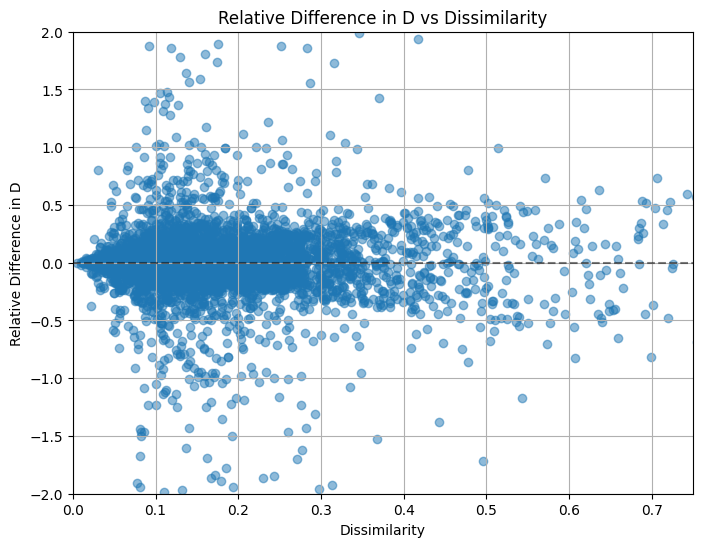

In [45]:
# plot rel_diff_D vs dissimilarity
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(pairs_table['dissimilarity'], pairs_table['rel_diff_D'], alpha=0.5)
plt.xlabel('Dissimilarity')
plt.ylabel('Relative Difference in D')
plt.title('Relative Difference in D vs Dissimilarity')
plt.axhline(0, color='k', linestyle='--', alpha=0.5)
plt.ylim(-2, 2)
plt.xlim(0, .75)
plt.grid()